# KOEN — PRE-G5 Full-Population Scientific Reconnaissance (EDA V2)

```
Status:     NON_CANONICAL / PRE-G5 EXPLORATORY
Class:      FULL_POPULATION_RECONNAISSANCE_V2
Authority:  SUBORDINATE_TO KOEN-TP-RS-001
```

**This notebook is NOT** `NB07`, **NOT** `NB08`, **NOT** a G5 verdict, **NOT** causal analysis.

## The V2 question

> V1에서 `N=40` probe로 관측된 multilayer signal 중 **무엇이 full-population D-03/D-04에서
> 유지되고, 무엇이 약화·증폭·반전되며, 어떤 것은 식별불가능한가?**

V1(`results/preliminary-eda-v1-20260817`)은 **immutable historical snapshot**이며 이 notebook은
그것을 수정하지 않는다. V1은 **기억이 아니라 branch에서 직접 읽는 source material**이다.

## Gate 상태 (입력 전제)

| Gate | 상태 | 근거 |
|---|---|---|
| G0 Design Freeze | PASS | — |
| G1 Data Integrity | PASS | `KOEN_G1_HUMAN_AUDIT_FINAL_ADJUDICATION.md` |
| G2 Representation Integrity | PASS | Claude-B forensic adjudication `441d580` |
| G3 Tokenizer Integrity | PASS | 동일 |
| G4 Morphology Integrity | PASS | 동일 |
| **G5 Analysis Readiness** | **NOT ADJUDICATED** | 본 notebook은 그 **후보 증거**만 만든다 |

## V1→V2 판정 어휘 (§6) — "confirmed" 남발 금지

| 판정 | 의미 |
|---|---|
| `UNCHANGED_BY_CONSTRUCTION` | V1이 이미 같은 full artifact를 썼으므로 같을 수밖에 없음 — 재확인이 아니다 |
| `PRESERVED_DIRECTION` | 부호·방향 유지, 크기는 달라질 수 있음 |
| `AMPLIFIED` | full population에서 크기가 커짐 |
| `ATTENUATED` | full population에서 크기가 작아짐 |
| `REVERSED` | 부호가 뒤집힘 |
| `STRUCTURALLY_NOT_IDENTIFIABLE` | 설계상 분리 불가 (support 구조 때문) |
| `NOT_TESTABLE_YET` | 이 notebook의 권한/데이터 밖 |

## 주장 경계 (§28)

**허용**: "full final cohort에서 관찰", "descriptive distribution", "support structure",
"candidate identifiability issue", "V1 signal preserved/attenuated".

**금지**: $\operatorname{Median}(\log TP)>0$ 추론적 결론 · significance · p-value ·
signed-rank · bootstrap CI · causal morphology mechanism · "domain effect" ·
regex chunk mechanism · o200k_base 밖으로의 일반화.

---

# 01 — dataviz skill, 색 계약, 자원 설정

## A. dataviz skill
`dataviz` (bundled pack `2.1.233`). 절차: 형태 선택 → 색을 job으로 배정 →
**팔레트를 계산으로 검증** → mark spec → 접근성.

### 검증된 색 역할 계약

8개 categorical slot을 겹치지 않는 3 family로 분할하고 `scripts/validate_palette.js`를
`--pairs all`로 light/dark 양 모드에서 실행해 통과시킨 계약을 **V1과 동일하게** 재사용한다
(같은 프로젝트·같은 design system이므로 재배정하지 않는다).

| Family | 역할 | Light | Dark | 검증 |
|---|---|---|---|---|
| Language side | KO | `#2a78d6` | `#3987e5` | CVD ΔE 24.7 / 26.8 · NV 33.6 / 31.8 · **ALL PASS** |
| Language side | EN | `#eb6834` | `#d95926` | (동일 페어) |
| Decomposition | `log CR` | `#1baf7a` | `#199e70` | CVD ΔE 6.9 / 6.5 (floor band) · NV 31.3 / 22.5 · **PASS + 보조부호 필수** |
| Decomposition | `log BDR` | `#4a3aa7` | `#9085e9` | (동일 trio) |
| Decomposition | `log CP` | `#e34948` | `#e66767` | (동일 trio) |
| Morphology | particle `J*` | `#e87ba4` | `#d55181` | CVD ΔE 16.2 / 6.9 · NV 19.6 / 19.3 · **PASS** |
| Morphology | ending `E*` | `#eda100` | `#c98500` | (동일 trio) |
| Morphology | deriv `XS*` | `#008300` | `#008300` | (동일 trio) |
| Morphology | other | `#898781` | `#898781` | de-emphasis (9번째 hue 아님) |

**Decomposition trio는 CVD floor band**이므로 보조 부호 의무: 성분을 항상 `CR → BDR → CP`
고정 순서로 배치(위치 부호) + 직접 수치 label + 2px surface gap.
Light 표면 3:1 미만 색(`#1baf7a` 2.74, `#e87ba4` 2.62, `#eda100` 2.11)에는 relief 의무:
가시 label + table view 동반.

**V2 신규 척도** — 이번에는 population 규모라 두 가지가 추가된다.

- **sequential (magnitude)**: 2D density / binned count → `palette.md`의 blue ramp 100→700
  **단일 hue**. rainbow 금지. 항상 colorbar 동반.
- **diverging (polarity)**: 상관행렬 → blue ↔ 중립 gray ↔ red, 0을 중립색에 고정, 모든 cell 수치 병기.

**금지**: domain을 hue로 encode하지 않는다(→ facet/축). length는 ordered label,
source/direction은 marker shape 또는 annotation.

## B. 자원 안전 (§23)
- full pandas load **금지**. DuckDB primary: `memory_limit=4GB`, `threads=6`,
  `preserve_insertion_order=false`, spill `.runtime/eda-v2-spill`.
- histogram/quantile = **full-population binned aggregate**.
- scatter = **결정론적 sample ≤ 200k**, `[V2-SAMPLE<n>]`로 명시.
- nested `morpheme_sequence`(STRUCT[])와 `ko_token_ids`/`en_token_ids`(INTEGER[])는
  **읽지 않는다** — 필요 없고, 전자는 원문 표면형을 담아 hygiene 위험이다.
- 불필요한 multi-process concurrency 금지 (memory guard defect 미해소).

## C. Repository hygiene (§24)
public branch에 raw KO / raw EN / morpheme text case / human workbook을 렌더링하지 않는다.
case panel은 `pair_id` · 수치 metric · 범주 metadata까지만.

In [1]:
# /**
#  * @cell 자원 한도와 검증된 시각 문법을 먼저 고정한다.
#  * @question 이 notebook이 소비할 자원의 상한과, 모든 figure가 따를 색·mark 규약은 무엇인가?
#  * @ssot §30.1 환경; dataviz skill color-formula / marks-and-anatomy
#  * @input 없음 (환경 자체)
#  * @population_or_sample n/a
#  * @method 환경변수 → import → rcParams. numpy가 thread pool을 만들기 전에 상한을 걸어야 한다.
#  * @output PALETTE / INK / MARK / SEQ_BLUE / DIVERGING, matplotlib rcParams
#  * @claim_boundary 이 cell은 어떤 연구 주장도 만들지 않는다.
#  * @v1_link V1과 동일한 색 계약을 재사용한다 (재배정하면 그림 간 의미가 흔들린다).
#  */

# @line thread 상한은 numpy/BLAS import 이전에 걸어야 실제로 적용된다.
import os
for _v in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_v] = "6"

# @line 표준 라이브러리 — 경로/시간/해시/직렬화는 모두 재현성 record에 들어간다.
import hashlib, json, platform, subprocess, sys, time
from datetime import datetime
from pathlib import Path
from zoneinfo import ZoneInfo
import psutil

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, BoundaryNorm
import seaborn as sns
import numpy as np
import pandas as pd
import duckdb

# @line worktree root를 pyproject.toml로 찾아 절대경로 하드코딩을 피한다.
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").is_file() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
_SRC = PROJECT_ROOT / "src"
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

KST = ZoneInfo("Asia/Seoul")
RUN_STARTED_KST = datetime.now(KST)
RUN_ID = f"EDA_V2_PRE_G5_{RUN_STARTED_KST:%Y%m%dT%H%M%S}"

# @line 검증 통과한 light-mode hex만 역할 이름으로 고정한다(9번째 hue를 만들지 않는다).
PALETTE = {
    "ko": "#2a78d6", "en": "#eb6834",
    "log_cr": "#1baf7a", "log_bdr": "#4a3aa7", "log_cp": "#e34948",
    "morph_particle": "#e87ba4", "morph_ending": "#eda100",
    "morph_deriv": "#008300", "morph_other": "#898781",
}
# @line status는 categorical과 절대 섞이지 않는 예약 색이며 항상 icon+label과 함께 쓴다.
STATUS = {"good": "#0ca30c", "warning": "#fab219", "serious": "#ec835a", "critical": "#d03b3b"}
INK = {"surface": "#fcfcfb", "primary": "#0b0b0b", "secondary": "#52514e",
       "muted": "#898781", "grid": "#e1e0d9", "baseline": "#c3c2b7"}
MARK = {"bar_max": 0.62, "line_w": 2.0, "marker": 6.0, "ring": 2.0, "hairline": 0.8, "gap": 0.02}

# @line sequential = 단일 hue, light→dark. palette.md의 blue ramp 100→700을 그대로 쓴다(rainbow 금지).
_BLUE_RAMP = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
              "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
SEQ_BLUE = LinearSegmentedColormap.from_list("koen_seq_blue", _BLUE_RAMP, N=256)
# @line diverging = 두 대립 hue + 중립 gray 중점. 0을 반드시 중립색에 고정한다.
DIVERGING = LinearSegmentedColormap.from_list("koen_div", [PALETTE["ko"], "#f0efec", PALETTE["log_cp"]], N=256)

# @line 한글 glyph를 실제 cmap 수준에서 보장하는 검증된 helper를 재사용한다.
from tokenization_premium.visualization import find_korean_font  # noqa: E402
from matplotlib import font_manager  # noqa: E402

# @line visualization.py가 import 시점에 Agg를 강제하므로, 그 '뒤에' inline으로 되돌려야 한다.
#       순서가 뒤바뀌면 plt.show()가 아무 출력도 내지 않아 실행된 notebook에 figure가 남지 않는다.
%matplotlib inline
# @line bbox_inches='tight'는 tight_layout(rect=...)로 잡은 caption 여백을 다시 잘라내므로 끈다.
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}
_FONT = find_korean_font()
font_manager.fontManager.addfont(_FONT["path"])
_FAMILY = font_manager.FontProperties(fname=_FONT["path"]).get_name()

# @line seaborn이 rcParams 일부를 되돌리므로 style을 먼저 적용하고 우리 값으로 덮어쓴다.
sns.set_style("white", {"axes.facecolor": INK["surface"]})
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": [_FAMILY, "DejaVu Sans"],
    "axes.unicode_minus": False,
    "figure.facecolor": INK["surface"], "axes.facecolor": INK["surface"],
    "savefig.facecolor": INK["surface"], "axes.edgecolor": INK["baseline"],
    "axes.linewidth": MARK["hairline"], "axes.grid": True,
    "grid.color": INK["grid"], "grid.linewidth": MARK["hairline"], "grid.linestyle": "-",
    "axes.labelcolor": INK["secondary"], "text.color": INK["primary"],
    "xtick.color": INK["muted"], "ytick.color": INK["muted"],
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "axes.labelsize": 9.5, "axes.titlesize": 10.5,
    "legend.frameon": False, "legend.fontsize": 8.5,
    "figure.dpi": 110, "savefig.dpi": 110,
})
# @line 조용한 tofu(네모) fallback을 막는 유일한 방법은 실제 해석 결과를 대조하는 것이다.
_resolved = font_manager.findfont(font_manager.FontProperties(family=plt.rcParams["font.family"]))
assert Path(_resolved).name == Path(_FONT["path"]).name, f"STOP: 한글 font 미적용 ({_resolved})"


def tidy(ax, *, xgrid=False, ygrid=True):
    """/** @purpose 모든 axes에 동일한 recessive chrome을 적용한다. @spec_ref dataviz marks-and-anatomy */"""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(INK["baseline"]); ax.spines[s].set_linewidth(MARK["hairline"])
    # @line 격자를 끌 때 선 속성을 함께 넘기면 matplotlib이 도로 켜므로 분기한다.
    for axis, on in (("x", xgrid), ("y", ygrid)):
        if on: ax.grid(True, axis=axis, color=INK["grid"], linewidth=MARK["hairline"], linestyle="-")
        else:  ax.grid(False, axis=axis)
    ax.set_axisbelow(True)


def legend_keys(ax, mapping, *, ncol=4, where="above"):
    """/** @purpose 2계열 이상 figure에 legend를 축 '밖'에 붙여 마크를 가리지 않게 한다. */"""
    handles = [Line2D([0], [0], marker="o", linestyle="none", markersize=MARK["marker"],
                      markerfacecolor=c, markeredgecolor=INK["surface"],
                      markeredgewidth=MARK["ring"] / 2, label=k) for k, c in mapping.items()]
    if where == "above":
        leg = ax.legend(handles=handles, ncol=ncol, loc="lower right", bbox_to_anchor=(1.0, 1.005),
                        handletextpad=0.4, columnspacing=1.0, borderaxespad=0.0)
    else:
        # @line tight_layout이 예약하지 않은 영역이라, 레이아웃 확정 뒤 figure 좌표로 붙인다.
        fig = ax.get_figure(); fig.canvas.draw(); pos = ax.get_position()
        leg = fig.legend(handles=handles, ncol=ncol, loc="upper center",
                         bbox_to_anchor=(pos.x0 + pos.width / 2, pos.y0 - 0.055),
                         handletextpad=0.4, columnspacing=1.0, borderaxespad=0.0)
    for t in leg.get_texts():
        t.set_color(INK["secondary"])


def caption(fig, basis: str, construct: str, cannot: str):
    """
    /**
     * @purpose 모든 figure에 '어떤 population/sample인가 · 무엇을 재는가 · 무엇을 결론지을 수 없는가'를 새긴다.
     * @spec_ref Directive §22 (figure caption 3요소 의무)
     */
    """
    # @line 그림만 잘라 써도 근거와 한계가 따라가도록 figure 자체에 새긴다.
    #       호출부는 tight_layout(rect=...)의 bottom을 최소 0.11로 잡아 이 두 줄의 자리를 비워야 한다.
    fig.text(0.006, 0.045, f"BASIS: {basis}", fontsize=8, color=INK["secondary"])
    fig.text(0.006, 0.014, f"CONSTRUCT: {construct}   ·   CANNOT CONCLUDE: {cannot}",
             fontsize=7.5, color=INK["muted"])


print(f"RUN_ID       = {RUN_ID}")
print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"korean font  = {_FAMILY}")
print(f"palette roles= {list(PALETTE)}")

RUN_ID       = EDA_V2_PRE_G5_20260817T181311
PROJECT_ROOT = /home/sieg/projects-wsl/Tokenization_KOEN_pre_g5_eda_v2
korean font  = NanumGothic
palette roles= ['ko', 'en', 'log_cr', 'log_bdr', 'log_cp', 'morph_particle', 'morph_ending', 'morph_deriv', 'morph_other']


In [2]:
# /**
#  * @cell 자원 한도가 걸린 DuckDB 연결 팩토리와 full-population 집계 helper를 정의한다.
#  * @question 3.8M행을 pandas로 올리지 않고 어떻게 분포를 얻는가?
#  * @ssot §30.1; Directive §23 resource safety
#  * @input 없음
#  * @population_or_sample n/a
#  * @method DuckDB out-of-core. quantile은 정확 계산, histogram은 SQL binned aggregate.
#  * @output duck(), quantiles(), binned_hist(), det_sample()
#  * @claim_boundary 계산 수단일 뿐 주장이 아니다.
#  * @v1_link V1은 1GB/2-thread였다. V2는 population 규모라 4GB/6-thread로 올리되 상한은 유지한다.
#  */

SPILL = PROJECT_ROOT / ".runtime/eda-v2-spill"
SPILL.mkdir(parents=True, exist_ok=True)
# @line 분위수 격자를 한 곳에 고정해 모든 표가 같은 지점을 보고하게 한다.
QLEVELS = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
QNAMES = ["p01", "p05", "p25", "median", "p75", "p95", "p99"]


def duck():
    """/** @purpose Directive §23 한도가 걸린 연결만 만든다. @spec_ref §23 */"""
    con = duckdb.connect()
    con.execute("SET memory_limit='4GB'")
    con.execute("SET threads=6")
    # @line 순서 보존을 끄면 대규모 집계에서 메모리와 시간이 크게 준다(집계 결과는 순서 무관).
    con.execute("SET preserve_insertion_order=false")
    con.execute(f"SET temp_directory='{SPILL.as_posix()}'")
    # @line 진행바 위젯이 notebook 출력을 오염시키므로 끈다.
    con.execute("SET enable_progress_bar=false")
    return con


def quantiles(con, source_sql: str, cols, *, where: str = "TRUE") -> pd.DataFrame:
    """
    /**
     * @purpose 여러 컬럼의 min/분위수/max/IQR을 full population에서 한 번의 스캔으로 얻는다.
     * @spec_ref §16.1 핵심 분포
     * @param source_sql read_parquet(...) 또는 JOIN을 담은 FROM 절 본문
     * @param cols 대상 컬럼 이름 목록
     * @return DataFrame[feature × (n,min,p01..p99,max,IQR)]
     */
    """
    rows = []
    # @line 컬럼을 8개씩 끊어 4GB 한도 안에서 정렬이 끝나게 한다(quantile_cont는 정확 분위수라 정렬한다).
    for i in range(0, len(cols), 8):
        chunk = cols[i:i + 8]
        sel = ", ".join(
            f"count({c}) AS {c}__n, min({c}) AS {c}__min, max({c}) AS {c}__max, "
            f"quantile_cont({c}, {QLEVELS}) AS {c}__q" for c in chunk)
        r = con.execute(f"SELECT {sel} FROM {source_sql} WHERE {where}").df().iloc[0]
        for c in chunk:
            q = list(r[f"{c}__q"])
            rows.append({"feature": c, "n": int(r[f"{c}__n"]), "min": r[f"{c}__min"],
                         **dict(zip(QNAMES, q)), "max": r[f"{c}__max"], "IQR": q[4] - q[2]})
    return pd.DataFrame(rows).set_index("feature")


def binned_hist(con, source_sql: str, col: str, lo: float, hi: float, nbins: int,
                *, where: str = "TRUE") -> pd.DataFrame:
    """
    /**
     * @purpose full population histogram을 SQL 집계로 계산한다 (원자료를 클라이언트로 가져오지 않는다).
     * @spec_ref Directive §23 (histogram = full-population binned aggregate)
     * @return DataFrame[bin_left, bin_center, n] — 범위 밖 값은 양 끝 bin에 clamp되며 그 사실을 별도 보고한다.
     */
    """
    w = (hi - lo) / nbins
    # @line clamp를 쓰는 이유: 꼬리가 극단적으로 길어 bin을 데이터 범위로 잡으면 본체가 한 칸에 뭉친다.
    # @line lo가 음수일 때 '{col} - -1.5'가 되어 '--'가 SQL 주석으로 먹히므로 반드시 괄호로 감싼다.
    q = f"""
    SELECT least(greatest(floor(({col} - ({lo})) / {w}), 0), {nbins - 1})::INT AS b,
           count(*) AS n
    FROM {source_sql} WHERE {where} AND {col} IS NOT NULL GROUP BY 1 ORDER BY 1"""
    d = con.execute(q).df()
    d["bin_left"] = lo + d.b * w
    d["bin_center"] = d.bin_left + w / 2
    return d[["bin_left", "bin_center", "n"]]


def det_sample(con, source_sql: str, cols, n: int, *, seed: str = "2995913794",
               where: str = "TRUE") -> pd.DataFrame:
    """
    /**
     * @purpose scatter용 결정론적 표본을 뽑는다 (난수 아님 — 재실행해도 같은 행).
     * @spec_ref Directive §23 (scatter는 <=200k 결정론적 표본); §30.3 seed policy
     * @param seed D-RD-01 auxiliary_seed. 새 seed를 만들지 않는다.
     * @return DataFrame[cols] — 정확히 n행 (모집단이 더 작으면 그만큼)
     */
    """
    sel = ", ".join(cols)
    # @line md5 해시 순서로 자르면 무작위처럼 고르게 퍼지면서도 완전히 재현 가능하다.
    return con.execute(f"""
        SELECT {sel} FROM {source_sql} WHERE {where}
        ORDER BY md5(pair_id || '{seed}') LIMIT {n}""").df()


def rss_gib() -> float:
    """/** @purpose 현재 프로세스 RSS(GiB) — 자원 상한 준수의 증거로 기록한다. */"""
    return round(psutil.Process(os.getpid()).memory_info().rss / 1024**3, 3)


RESOURCE_PEAK = {"rss_gib": rss_gib()}
print(f"DuckDB  memory_limit=4GB  threads=6  preserve_insertion_order=false")
print(f"spill   {SPILL.relative_to(PROJECT_ROOT)}")
print(f"RSS now {RESOURCE_PEAK['rss_gib']} GiB")

DuckDB  memory_limit=4GB  threads=6  preserve_insertion_order=false
spill   .runtime/eda-v2-spill
RSS now 0.263 GiB


---

# 02 — Canonical Artifact 신원 검증 (FAIL CLOSED)

## @question
이 EDA가 소비하는 세 artifact가 **Claude-B가 forensic으로 판정한 바로 그 파일**인가?

## @ssot
§30.2 lineage; B G2/G3/G4 adjudication `441d5802bfebe178fd220d08b653c60dfad17faf`
(`ssot/2026-08-17_1730_KOEN_TP_G2_G3_G4_FINAL_ADJUDICATION.md`).

## @method
`src/tokenization_premium/lineage.py`의 `assert_canonical_artifact(..., verify_pair_set=True)`.
경로 · SHA-256 · schema 열수 · row count · distinct id · **정렬 pair-set 해시**를 대조하고
하나라도 어긋나면 `CanonicalArtifactIdentityMismatch`로 즉시 실패한다.

## @claim_boundary
`pilot` / `synthetic` / `REP_FEATURES_v001` / 어떤 fallback도 사용하지 않는다.
검증 통과 **전에는 EDA를 시작하지 않는다.**

In [3]:
# /**
#  * @cell 세 canonical artifact의 신원을 fail-closed로 검증한다. 통과 전에는 아무 EDA도 하지 않는다.
#  * @question 우리가 읽는 파일이 정말 G2/G3/G4가 판정한 그 파일인가?
#  * @ssot §30.2 lineage; adjudication 441d580
#  * @input data/registry/{REP_FEATURES_v002, MORPH_FEATURES_KIWI_v001, TOKEN_O200K_BASE_v001}.parquet
#  * @population_or_sample full artifact 전체 (신원 검증은 전수)
#  * @method lineage.assert_canonical_artifact(verify_pair_set=True)
#  * @output ARTIFACT_IDENTITY(dict)
#  * @claim_boundary 신원 검증이지 품질 판정이 아니다. Gate는 이미 B가 판정했다.
#  * @v1_link V1은 REP_FEATURES만 full이었고 M/T는 sample 재계산이었다. V2는 셋 다 full이다.
#  */

from tokenization_premium.lineage import (  # noqa: E402
    ADJUDICATION_COMMIT, ADJUDICATION_DOC, CANONICAL_ARTIFACTS, CANONICAL_COHORT_N,
    CANONICAL_PAIR_SET_MD5, assert_canonical_artifact, describe_historical,
)

_t0 = time.time()
_con = duck()
ARTIFACT_IDENTITY = {}
# @line pair-set 대조는 cohort artifact 3개에만 적용한다. PAIR_REGISTRY는 5.65M행 superset이라 대상이 아니다.
for _name, _vps in (("REP_FEATURES_v002", True), ("MORPH_FEATURES_KIWI_v001", True),
                    ("TOKEN_O200K_BASE_v001", True), ("PAIR_REGISTRY_v002", False)):
    ARTIFACT_IDENTITY[_name] = assert_canonical_artifact(_name, verify_pair_set=_vps, con=_con)

print(f"adjudication commit : {ADJUDICATION_COMMIT}")
print(f"adjudication doc    : {ADJUDICATION_DOC}")
print(f"canonical cohort N  : {CANONICAL_COHORT_N:,}")
print(f"canonical pair-set  : {CANONICAL_PAIR_SET_MD5}\n")
for _n, _r in ARTIFACT_IDENTITY.items():
    print(f"[{_r['identity']}] {_n}  (gate {_r['gate']})")
    print(f"    rows={_r['row_count']:,}  cols={_r['column_count']}  id={_r['id_column']}")
    print(f"    sha256={_r['sha256']}")
    if "pair_set_md5" in _r:
        print(f"    pair_set_md5={_r['pair_set_md5']}  == CANONICAL")

# @line 세 cohort artifact가 같은 pair 우주를 공유하는지 명시적으로 재확인한다(§3 expected universe).
_cohort = ["REP_FEATURES_v002", "MORPH_FEATURES_KIWI_v001", "TOKEN_O200K_BASE_v001"]
assert all(ARTIFACT_IDENTITY[n]["row_count"] == CANONICAL_COHORT_N for n in _cohort)
assert len({ARTIFACT_IDENTITY[n]["pair_set_md5"] for n in _cohort}) == 1
print(f"\nUNIVERSE VERIFIED — 세 artifact 모두 N={CANONICAL_COHORT_N:,}, 동일 pair-set")

# @line 과거 산출물을 current evidence와 섞지 않겠다는 계약을 코드로 남긴다(SSOT §24).
print("\n── HISTORICAL (current evidence 아님) ──")
for _h in ("REP_FEATURES_v001", "MORPH_FEATURES_PILOT_v001"):
    _d = describe_historical(_h)
    print(f"  {_h:28s} {_d['status']}  present={_d['present_locally']}")

# @line 이후 모든 SQL이 참조할 FROM 절을 상수로 고정한다.
REP = f"read_parquet('{(PROJECT_ROOT / CANONICAL_ARTIFACTS['REP_FEATURES_v002'].relative_path).as_posix()}')"
MOR = f"read_parquet('{(PROJECT_ROOT / CANONICAL_ARTIFACTS['MORPH_FEATURES_KIWI_v001'].relative_path).as_posix()}')"
TOK = f"read_parquet('{(PROJECT_ROOT / CANONICAL_ARTIFACTS['TOKEN_O200K_BASE_v001'].relative_path).as_posix()}')"
REG = f"read_parquet('{(PROJECT_ROOT / CANONICAL_ARTIFACTS['PAIR_REGISTRY_v002'].relative_path).as_posix()}')"
print(f"\nidentity verification: {time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")

adjudication commit : 441d5802bfebe178fd220d08b653c60dfad17faf
adjudication doc    : ssot/2026-08-17_1730_KOEN_TP_G2_G3_G4_FINAL_ADJUDICATION.md
canonical cohort N  : 3,835,988
canonical pair-set  : d9660d654ee449e4d0c23a0070225274

[CANONICAL_ARTIFACT_IDENTITY_VERIFIED] REP_FEATURES_v002  (gate G2)
    rows=3,835,988  cols=49  id=pair_id
    sha256=dfae8e01cd3fe2ca949d8754678e508203ad1a7aa6abea418008a33ac650d309
    pair_set_md5=d9660d654ee449e4d0c23a0070225274  == CANONICAL
[CANONICAL_ARTIFACT_IDENTITY_VERIFIED] MORPH_FEATURES_KIWI_v001  (gate G4)
    rows=3,835,988  cols=19  id=morph_measurement_id
    sha256=0fe5bd74e3993a7141c5c33ea78e71b2c66e3ecd296544bde2615acb43e50f7d
    pair_set_md5=d9660d654ee449e4d0c23a0070225274  == CANONICAL
[CANONICAL_ARTIFACT_IDENTITY_VERIFIED] TOKEN_O200K_BASE_v001  (gate G3)
    rows=3,835,988  cols=28  id=measurement_id
    sha256=1c30e3276222dd94885ae4f79fc6ab5c45e4e26226de0afd91fc6b1f7d2c16e7
    pair_set_md5=d9660d654ee449e4d0c23a0070225274  == CA

---

# 03 — V1 Source Material (branch에서 직접 읽음)

## @question
V1이 실제로 기록한 값은 무엇이며, 그중 **row-level로 복원 가능한 것은 무엇인가?**

## @ssot
Directive §4 — "V1 자료를 branch에서 직접 읽는다. V1 숫자를 기억으로 재작성 금지."

## @method
`git show results/preliminary-eda-v1-20260817:<path>`로 freeze manifest와 AXIS 문서를 읽고,
frozen notebook 출력에 per-pair metric 표가 존재하는지 **기계적으로 판정**한다.

## @claim_boundary
V1 문서에 없는 값을 재구성해서 "V1이 이랬다"고 말하지 않는다.
없으면 `NOT_RECOVERABLE_FROM_FROZEN_OUTPUT`으로 기록하고 aggregate 비교만 한다.

In [4]:
# /**
#  * @cell V1 freeze manifest와 frozen notebook을 branch에서 읽고 row-level 복원 가능성을 판정한다.
#  * @question V1 숫자 중 무엇이 문서에 실제로 남아 있는가?
#  * @ssot Directive §4 (V1 is source material, not memory)
#  * @input git object: results/preliminary-eda-v1-20260817
#  * @population_or_sample V1 frozen n=40 기록
#  * @method git show → JSON/markdown 파싱 → frozen notebook 출력 스캔
#  * @output V1_MANIFEST, V1_PAIR_IDS, V1_FROZEN_AGG, V1_ROWLEVEL_STATUS
#  * @claim_boundary 재구성 금지. 문서에 있는 값만 인용한다.
#  * @v1_link 이 cell 자체가 V1 링크다.
#  */

V1_BRANCH = "results/preliminary-eda-v1-20260817"


def _git_show(path: str) -> str:
    """/** @purpose V1 branch의 파일을 워킹트리 변경 없이 읽는다. @spec_ref Directive §2 (V1 수정 금지) */"""
    # @line checkout 대신 git show를 쓰는 이유: V1 branch도 이 worktree도 건드리지 않기 위해서다.
    return subprocess.run(["git", "show", f"{V1_BRANCH}:{path}"], cwd=PROJECT_ROOT,
                          capture_output=True, text=True, check=True).stdout


V1_FREEZE_SHA = subprocess.run(["git", "rev-parse", V1_BRANCH], cwd=PROJECT_ROOT,
                               capture_output=True, text=True, check=True).stdout.strip()
V1_MANIFEST = json.loads(_git_show("docs/results/preliminary_v1/EDA_V1_FREEZE_MANIFEST.json"))
V1_PAIR_IDS = tuple(V1_MANIFEST["pair_ids"])
V1_AXIS_DOC = _git_show("docs/results/preliminary_v1/KOEN_PRELIMINARY_RESULTS_AXIS_V1.md")

print(f"V1 freeze commit  : {V1_FREEZE_SHA}")
print(f"V1 base (exec) SHA: {V1_MANIFEST['notebook_execution_sha']}")
print(f"V1 run_id         : {V1_MANIFEST['run_id']}")
print(f"V1 notebook sha256: {V1_MANIFEST['notebook_sha256']}")
print(f"V1 sample_n       : {V1_MANIFEST['sample_n']}   pair_set={V1_MANIFEST['pair_set_hash']}")

# @line V1의 pair-set 해시를 여기서 다시 계산해 대조한다 — 문서의 주장을 그대로 믿지 않는다.
_recomputed = hashlib.sha256("\n".join(sorted(V1_PAIR_IDS)).encode("utf-8")).hexdigest()
assert _recomputed == V1_MANIFEST["pair_set_hash"], "STOP: V1 pair-set 해시 불일치"
print(f"V1 pair-set 재계산 : {_recomputed}  MATCH")

# @line V1이 쓴 Representation artifact가 V2와 같은 파일인지 확인한다(AXIS1 판정의 근거).
_v1_rep = V1_MANIFEST["representation_artifact"]
V1_USED_SAME_REP = _v1_rep["manifest_expected_sha256"] == ARTIFACT_IDENTITY["REP_FEATURES_v002"]["sha256"]
print(f"\nV1 representation artifact = {_v1_rep['version']}  sha={_v1_rep['manifest_expected_sha256'][:16]}...")
print(f"V2와 동일 파일인가        = {V1_USED_SAME_REP}  → AXIS1은 UNCHANGED_BY_CONSTRUCTION 후보")
print(f"V1 morphology basis       = {V1_MANIFEST['morphology_basis']['layer_status']}")
print(f"V1 tokenizer basis        = {V1_MANIFEST['tokenizer_basis']['layer_status']}")

V1 freeze commit  : aabd068a4eef1245420ba4cc0a510ca4e27deae2
V1 base (exec) SHA: 2d99c906c7c94a9ce2ee2e0ff9dc01cf61998c3a
V1 run_id         : VIZ_CASEBOOK_20260817T151317
V1 notebook sha256: 3852df21c8b36e099040d568309f21cc970c02ce4d8a8b9943c0c4e53264f2dd
V1 sample_n       : 40   pair_set=5b4393fb541c3a6dc347fa2422ed25fbfb384eed45a4b98b652ed3f85c8e0ac1
V1 pair-set 재계산 : 5b4393fb541c3a6dc347fa2422ed25fbfb384eed45a4b98b652ed3f85c8e0ac1  MATCH

V1 representation artifact = REP_FEATURES_v002  sha=dfae8e01cd3fe2ca...
V2와 동일 파일인가        = True  → AXIS1은 UNCHANGED_BY_CONSTRUCTION 후보
V1 morphology basis       = SAMPLE_RECOMPUTED_FOR_VISUALIZATION
V1 tokenizer basis        = SAMPLE_RECOMPUTED_FOR_VISUALIZATION


In [5]:
# /**
#  * @cell V1 AXIS 문서에서 frozen aggregate를 파싱하고, frozen notebook의 row-level 복원 가능성을 판정한다.
#  * @question V1의 sample-40 중앙값은 정확히 얼마이며, per-pair 값은 남아 있는가?
#  * @ssot Directive §5 (NOT_RECOVERABLE_FROM_FROZEN_OUTPUT 규칙)
#  * @input V1 AXIS markdown, V1 frozen notebook
#  * @population_or_sample V1 n=40 (전체) 및 domain별 n=10
#  * @method markdown 표 파싱 + notebook 출력 정규식 스캔
#  * @output V1_FROZEN_AGG(dict), V1_FROZEN_BY_DOMAIN(DataFrame), V1_ROWLEVEL_STATUS(str)
#  * @claim_boundary 파싱 실패 시 값을 추측하지 않고 즉시 중단한다.
#  * @v1_link AXIS 2 문서의 두 표를 그대로 옮긴다.
#  */

import re  # noqa: E402

# @line 문서의 굵은 표기(**+0.9004**)와 유니코드 마이너스(−)를 모두 받아들이는 숫자 패턴이다.
_NUM = r"\*{0,2}([+\-\u2212]?\d+\.\d+)\*{0,2}"


def _f(s: str) -> float:
    """/** @purpose 문서 표기의 유니코드 마이너스를 ASCII로 바꿔 float로 만든다. */"""
    return float(s.replace("\u2212", "-").replace("+", ""))


# @line AXIS2의 "Sample medians of the three components" 표에서 4개 값을 정확히 뽑는다.
_pat = {
    "logCR":  rf"\\log \\mathrm{{CodePointRatio}}\$ \| {_NUM}",
    "logBDR": rf"\\log \\mathrm{{ByteDensityRatio}}\$ \| {_NUM}",
    "logCP":  rf"\\log \\mathrm{{CompressionPenalty}}\$ \| {_NUM}",
    "logTP":  rf"\\log TP\$ \| {_NUM}",
}
V1_FROZEN_AGG = {}
for k, p in _pat.items():
    m = re.search(p, V1_AXIS_DOC)
    assert m, f"STOP: V1 AXIS 문서에서 {k}를 파싱하지 못했다 (추측하지 않는다)"
    V1_FROZEN_AGG[k] = _f(m.group(1))

# @line per-domain 표도 문서에서 직접 읽는다 — 기억으로 다시 쓰지 않는다.
_rows = re.findall(
    rf"^\| (dialogue|general|other|technology) \| {_NUM} \| {_NUM} \| {_NUM} \| {_NUM} \|",
    V1_AXIS_DOC, flags=re.M)
assert len(_rows) == 4, f"STOP: V1 per-domain 표 파싱 실패 ({len(_rows)}행)"
V1_FROZEN_BY_DOMAIN = pd.DataFrame(
    [{"domain": r[0], "logTP": _f(r[1]), "logCR": _f(r[2]), "logBDR": _f(r[3]), "logCP": _f(r[4])}
     for r in _rows]).set_index("domain")

print("── V1 frozen aggregate (n=40, AXIS 문서에서 파싱) ──")
for k, v in V1_FROZEN_AGG.items():
    print(f"  median {k:6s} = {v:+.4f}")
print("\n── V1 frozen per-domain (n=10 each) ──")
display(V1_FROZEN_BY_DOMAIN)

# @line frozen notebook 출력에 per-pair metric 표가 있는지 기계적으로 확인한다.
_v1_nb = json.loads(_git_show("notebooks/exploratory/EDA_representation_kiwi_o200k_casebook_v1.ipynb"))
_blob = ""
for _c in _v1_nb["cells"]:
    if _c["cell_type"] != "code":
        continue
    for _o in _c.get("outputs", []):
        if _o.get("output_type") == "stream":
            _blob += "".join(_o["text"])
        elif "text/plain" in _o.get("data", {}) and "image/png" not in _o.get("data", {}):
            _blob += "".join(_o["data"]["text/plain"])

# @line 40행짜리 per-pair 표가 실제로 출력되었는지가 판정 기준이다(집계표만으로는 row-level 비교 불가).
_has_rowlevel = bool(re.search(r"\[40 rows x", _blob))
V1_ROWLEVEL_STATUS = ("RECOVERABLE_FROM_FROZEN_OUTPUT" if _has_rowlevel
                      else "NOT_RECOVERABLE_FROM_FROZEN_OUTPUT")
print(f"\nV1 row-level 복원 판정 : {V1_ROWLEVEL_STATUS}")
print("  근거: frozen 출력에 per-pair 40행 metric 표가 " + ("있다" if _has_rowlevel else "없다") +
      ". 출력된 것은 domain 단위 중앙값 표뿐이다.")
print("  → V1과의 비교는 aggregate-level(전체·domain 중앙값)로만 수행한다. 재구성하지 않는다.")

── V1 frozen aggregate (n=40, AXIS 문서에서 파싱) ──
  median logCR  = -0.8113
  median logBDR = +0.9004
  median logCP  = +0.1360
  median logTP  = +0.2007

── V1 frozen per-domain (n=10 each) ──


,logTP,logCR,logBDR,logCP
domain,,,,
dialogue,0.0589,-0.8511,0.9051,-0.0518
general,0.1987,-0.9154,0.8785,0.1574
other,0.2636,-0.7704,0.9145,0.1473
technology,0.3972,-0.6362,0.8800,0.2729



V1 row-level 복원 판정 : NOT_RECOVERABLE_FROM_FROZEN_OUTPUT
  근거: frozen 출력에 per-pair 40행 metric 표가 없다. 출력된 것은 domain 단위 중앙값 표뿐이다.
  → V1과의 비교는 aggregate-level(전체·domain 중앙값)로만 수행한다. 재구성하지 않는다.


---

# 04 — V1 → same-40 → Population 복제 브리지

## @question
V1과 V2의 차이는 **실행 편차(execution drift)**인가, **표본→모집단 확장(sampling expansion)**인가?

## @ssot
Directive §5 / §10. SSOT §8 exact decomposition.

## @method
V1이 동결한 40개 `pair_id`를 full D-03/D-04 artifact에 **exact join**한 뒤 세 열을 나란히 둔다.

| 열 | 의미 |
|---|---|
| **V1 frozen 40** | V1 notebook이 40건을 *재계산*해 얻은 값 (`SAMPLE_RECOMPUTED_FOR_VISUALIZATION`) |
| **same-40 full artifact** | 같은 40 `pair_id`를 canonical full artifact에서 읽은 값 |
| **full cohort** | N = 3,835,988 |

**V1 frozen 40 ↔ same-40**의 차이 = 실행 편차 (같은 pair, 다른 실행 경로).
**same-40 ↔ full cohort**의 차이 = 표본 확장 효과.

## @claim_boundary
40건 중앙값은 어떤 경우에도 모집단 추정치가 아니다. 이 표는 **차이의 원인을 분리**하는 도구다.

In [6]:
# /**
#  * @cell V1의 40 pair_id를 full artifact에 exact join하고 3열 비교표를 만든다.
#  * @question V1↔V2 차이가 실행 편차인가 표본 확장인가?
#  * @ssot Directive §5/§10; SSOT §8
#  * @input V1_PAIR_IDS(40), TOKEN_O200K_BASE_v001, MORPH_FEATURES_KIWI_v001
#  * @population_or_sample same-40 (V1 동결 pair-set) vs full cohort N=3,835,988
#  * @method exact join on pair_id → 동일 통계량(중앙값) 비교
#  * @output SAME40(DataFrame 40행), BRIDGE(DataFrame 3열 비교)
#  * @claim_boundary 40건 중앙값은 모집단 추정치가 아니다.
#  * @v1_link V1_FROZEN_AGG / V1_FROZEN_BY_DOMAIN 과 직접 대응한다.
#  */

_ids = ", ".join(f"'{p}'" for p in V1_PAIR_IDS)
# @line 40개 id만 필터링하므로 결과는 40행이며 메모리 부담이 없다.
SAME40 = _con.execute(f"""
    SELECT t.pair_id, g.domain, g.logical_corpus, g.source_id, g.translation_direction, g.length_stratum,
           t.ko_token_count, t.en_token_count, t.token_premium, t.log_token_premium,
           t.log_code_point_ratio, t.log_byte_density_ratio, t.log_compression_penalty,
           t.identity_abs_error, t.roundtrip_ok,
           m.eojeol_count, m.morpheme_count, m.particle_count, m.ending_count, m.deriv_affix_count,
           m.morpheme_density, m.particle_ratio, m.ending_ratio, m.deriv_affix_ratio,
           m.function_morpheme_ratio, m.analysis_warning_flag
    FROM {TOK} t
    JOIN {MOR} m ON t.pair_id = m.pair_id
    JOIN {REG} g ON t.pair_id = g.pair_id
    WHERE t.pair_id IN ({_ids})""").df()

# @line join 결과가 정확히 40행이 아니면 pair-set 전제가 깨진 것이므로 STOP 조건이다.
assert len(SAME40) == 40, f"STOP: V1 40 pair join 결과가 {len(SAME40)}행이다"
assert SAME40.pair_id.nunique() == 40, "STOP: same-40 pair_id 중복"
print(f"V1 40 pair → full artifact exact join: {len(SAME40)}행  (전부 매칭)")

# @line full cohort 중앙값은 별도 스캔으로 구한다(같은 통계량이어야 비교가 성립한다).
_full = _con.execute(f"""
    SELECT median(log_token_premium) logTP, median(log_code_point_ratio) logCR,
           median(log_byte_density_ratio) logBDR, median(log_compression_penalty) logCP
    FROM {TOK}""").df().iloc[0]

# @line 세 열을 한 표에 모아야 '실행 편차'와 '표본 확장'이 눈으로 분리된다.
_map = {"logTP": "log_token_premium", "logCR": "log_code_point_ratio",
        "logBDR": "log_byte_density_ratio", "logCP": "log_compression_penalty"}
BRIDGE = pd.DataFrame([{
    "component": k,
    "V1 frozen 40": V1_FROZEN_AGG[k],
    "same-40 full artifact": float(SAME40[v].median()),
    "full cohort N=3,835,988": float(_full[k]),
} for k, v in _map.items()]).set_index("component")
BRIDGE["Δ 실행편차 (same40 − V1)"] = BRIDGE["same-40 full artifact"] - BRIDGE["V1 frozen 40"]
BRIDGE["Δ 표본확장 (full − same40)"] = BRIDGE["full cohort N=3,835,988"] - BRIDGE["same-40 full artifact"]

print(f"\nV1 row-level status: {V1_ROWLEVEL_STATUS}")
print("→ 아래 비교는 aggregate-level(중앙값)이다. row-level 대조는 수행하지 않았다.\n")
display(BRIDGE.round(4))

# @line 실행 편차가 0에 가까우면 V1의 계산 경로가 canonical 구현과 일치했다는 뜻이다.
_drift = BRIDGE["Δ 실행편차 (same40 − V1)"].abs().max()
print(f"최대 |실행 편차| = {_drift:.4f}")
print("  해석: 이 값이 작을수록 V1의 40건 재계산이 canonical full 측정과 같은 결과를 냈다는 뜻이다.")
print("        큰 값은 execution drift, 세 번째 열과의 차이는 sampling expansion이다.")
print(f"\nRSS {rss_gib()} GiB")

V1 40 pair → full artifact exact join: 40행  (전부 매칭)



V1 row-level status: NOT_RECOVERABLE_FROM_FROZEN_OUTPUT
→ 아래 비교는 aggregate-level(중앙값)이다. row-level 대조는 수행하지 않았다.



,V1 frozen 40,same-40 full artifact,"full cohort N=3,835,988",Δ 실행편차 (same40 − V1),Δ 표본확장 (full − same40)
component,,,,,
logTP,0.2007,0.2007,0.2877,-0.0,0.0870
logCR,-0.8113,-0.8113,-0.7605,-0.0,0.0509
logBDR,0.9004,0.9004,0.8961,0.0,-0.0043
logCP,0.1360,0.1360,0.1752,-0.0,0.0392


최대 |실행 편차| = 0.0000
  해석: 이 값이 작을수록 V1의 40건 재계산이 canonical full 측정과 같은 결과를 냈다는 뜻이다.
        큰 값은 execution drift, 세 번째 열과의 차이는 sampling expansion이다.

RSS 1.246 GiB


---

# 05 — AXIS 1 · Representation Reversal (full population)

## @question
"한국어는 code point가 더 짧지만 UTF-8 byte는 더 무겁다"는 V1의 관측이 full population에서 어떤 형태인가?

## @ssot
§8.2 CodePointRatio; §8.3 ByteDensityRatio; §13.3 Byte Density; §13.5 Pair Length Ratio; §12.2.

## @population_or_sample
**[R-FULL]** `REP_FEATURES_v002`, N = 3,835,988. 밀도 그림은 full-population **binned aggregate**.

## @v1_link — 판정 규칙이 특별하다
V1의 AXIS 1은 **이미 같은 `REP_FEATURES_v002` 파일**을 썼다(cell 03에서 sha256 대조 완료).
따라서 숫자가 같다면 그것은 재확인이 아니라 **동어반복**이다 →
`CONFIRMED`가 아니라 **`UNCHANGED_BY_CONSTRUCTION`**으로 분류한다.

## @claim_boundary
이 축은 **문자열 표현**에 대한 진술이다. token premium이나 tokenizer inefficiency로 확대 금지.

In [7]:
# /**
#  * @cell 표현층 비율 분포를 full population 분위수로 산출한다.
#  * @question code point 비와 byte 비의 분포는 각각 1을 어디서 가로지르는가?
#  * @ssot §8.2/§8.3/§13.3/§13.5
#  * @input REP_FEATURES_v002 (N=3,835,988)
#  * @population_or_sample [R-FULL] 전수
#  * @method DuckDB quantile_cont (정확 분위수), 단일 스캔 chunked
#  * @output REP_Q(DataFrame), REP_CROSS(dict)
#  * @claim_boundary 표현층 사실이며 token 결과가 아니다.
#  * @v1_link V1이 동일 파일을 썼으므로 일치는 UNCHANGED_BY_CONSTRUCTION이다.
#  */

_t0 = time.time()
_REP_COLS = ["pair_codepoint_ratio", "pair_grapheme_ratio", "pair_byte_ratio", "pair_codepoint_diff",
             "ko_bytes_per_codepoint", "en_bytes_per_codepoint",
             "ko_codepoint_count", "en_codepoint_count", "ko_utf8_bytes", "en_utf8_bytes",
             "ko_eojeol_count", "en_word_count"]
REP_Q = quantiles(_con, REP, _REP_COLS)
display(REP_Q.round(4))

# @line 분위수만으로는 "1을 넘는 비율이 몇 %인가"를 알 수 없다. 그 share를 직접 센다.
REP_CROSS = _con.execute(f"""
    SELECT count(*) n,
      avg(CASE WHEN pair_codepoint_ratio < 1 THEN 1.0 ELSE 0 END) cp_lt1,
      avg(CASE WHEN pair_codepoint_ratio = 1 THEN 1.0 ELSE 0 END) cp_eq1,
      avg(CASE WHEN pair_codepoint_ratio > 1 THEN 1.0 ELSE 0 END) cp_gt1,
      avg(CASE WHEN pair_byte_ratio < 1 THEN 1.0 ELSE 0 END) by_lt1,
      avg(CASE WHEN pair_byte_ratio = 1 THEN 1.0 ELSE 0 END) by_eq1,
      avg(CASE WHEN pair_byte_ratio > 1 THEN 1.0 ELSE 0 END) by_gt1,
      avg(CASE WHEN pair_codepoint_ratio < 1 AND pair_byte_ratio > 1 THEN 1.0 ELSE 0 END) reversal
    FROM {REP}""").df().iloc[0].to_dict()

print(f"\n── 1.0 교차 구조 (N={int(REP_CROSS['n']):,}) ──")
print(f"  code point 비 < 1 : {REP_CROSS['cp_lt1']:.4%}   = 1 : {REP_CROSS['cp_eq1']:.4%}   > 1 : {REP_CROSS['cp_gt1']:.4%}")
print(f"  byte 비       < 1 : {REP_CROSS['by_lt1']:.4%}   = 1 : {REP_CROSS['by_eq1']:.4%}   > 1 : {REP_CROSS['by_gt1']:.4%}")
print(f"\n  ** REVERSAL (code point<1 그리고 byte>1) = {REP_CROSS['reversal']:.4%} **")
print("  → '역전'은 보편이 아니라 다수 현상이다. 이 share가 그 크기를 정확히 말한다.")
print(f"\n{time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")

,n,min,p01,p05,p25,median,p75,p95,p99,max,IQR
feature,,,,,,,,,,,
pair_codepoint_ratio,3835988,0.0222,0.2781,0.3333,0.4085,0.4675,0.5385,0.6792,0.8333,60.0000,0.1300
pair_grapheme_ratio,3835988,0.0222,0.2781,0.3333,0.4085,0.4675,0.5385,0.6792,0.8333,60.0000,0.1300
pair_byte_ratio,3835988,0.0539,0.6562,0.8037,0.9848,1.1268,1.3000,1.6333,1.9697,144.0000,0.3152
pair_codepoint_diff,3835988,-2159.0000,-188.0000,-143.0000,-78.0000,-39.0000,-22.0000,-9.0000,-3.0000,102.0000,56.0000
ko_bytes_per_codepoint,3835988,1.0000,1.9091,2.1333,2.3548,2.4500,2.5000,2.5714,2.6250,3.0000,0.1452
en_bytes_per_codepoint,3835988,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,2.5088,0.0000
ko_codepoint_count,3835988,1.0000,6.0000,11.0000,23.0000,36.0000,66.0000,103.0000,122.0000,684.0000,43.0000
en_codepoint_count,3835988,1.0000,12.0000,25.0000,46.0000,74.0000,146.0000,239.0000,298.0000,2208.0000,100.0000
ko_utf8_bytes,3835988,1.0000,13.0000,26.0000,56.0000,89.0000,158.0000,245.0000,292.0000,1538.0000,102.0000



── 1.0 교차 구조 (N=3,835,988) ──
  code point 비 < 1 : 99.6691%   = 1 : 0.1376%   > 1 : 0.1933%
  byte 비       < 1 : 26.4542%   = 1 : 2.1895%   > 1 : 71.3563%

  ** REVERSAL (code point<1 그리고 byte>1) = 71.0521% **
  → '역전'은 보편이 아니라 다수 현상이다. 이 share가 그 크기를 정확히 말한다.

1.9s   RSS 0.714 GiB


findfont: Failed to find font weight bold, now using 600.


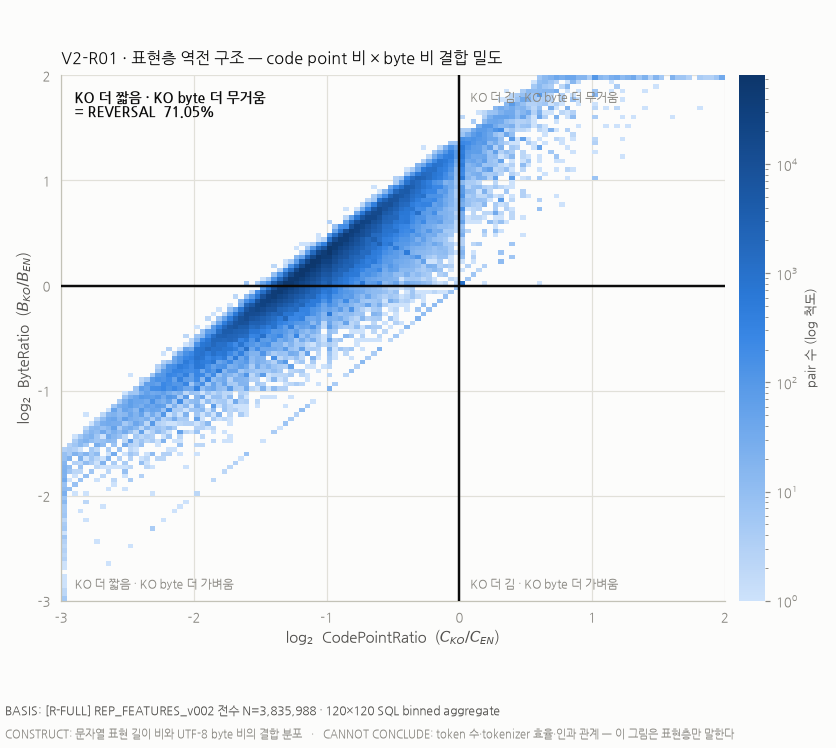

0.3s   RSS 0.722 GiB


In [8]:
# /**
#  * @cell V2-R01 — CodePointRatio × ByteRatio 결합 밀도를 full-population binned aggregate로 그린다.
#  * @question 두 비율이 만드는 사분면 중 모집단은 어디에 몰려 있는가?
#  * @ssot §8.2/§8.3
#  * @input REP_FEATURES_v002
#  * @population_or_sample [R-FULL] 전수 (원자료를 클라이언트로 가져오지 않는다)
#  * @method log2 축에서 2D bin count를 SQL로 집계 → pcolormesh. 색은 magnitude → 단일 hue sequential.
#  * @output F: V2-R01
#  * @claim_boundary 밀도는 빈도이지 인과가 아니다. 사분면 이름은 기술 라벨이다.
#  * @v1_link V1은 40점 dot plot이었다. 같은 구조를 3.8M 밀도로 다시 본다.
#  */

_t0 = time.time()
# @line log2를 쓰는 이유: 비율은 1을 중심으로 곱셈적이라 선형축에서 좌우가 왜곡된다.
_LO, _HI, _NB = -3.0, 2.0, 120
# @line bin 폭을 Python에서 미리 계산한다. SQL 문자열 안에서 빼기를 조립하면 음수 리터럴이
#       '2.0--3.0'처럼 이어져 '--'가 SQL 주석으로 해석되는 사고가 난다.
_BW = (_HI - _LO) / _NB
_grid = _con.execute(f"""
    WITH b AS (
      SELECT least(greatest(floor((log2(pair_codepoint_ratio) - ({_LO})) / {_BW}), 0), {_NB-1})::INT AS bx,
             least(greatest(floor((log2(pair_byte_ratio)      - ({_LO})) / {_BW}), 0), {_NB-1})::INT AS by_
      FROM {REP}
      WHERE pair_codepoint_ratio > 0 AND pair_byte_ratio > 0)
    SELECT bx, by_, count(*) AS n FROM b GROUP BY 1,2""").df()
_H = np.zeros((_NB, _NB))
_H[_grid.by_.to_numpy(), _grid.bx.to_numpy()] = _grid.n.to_numpy()
_edges = np.linspace(_LO, _HI, _NB + 1)

fig, ax = plt.subplots(figsize=(7.6, 6.8))
# @line count는 수 자릿수가 크게 벌어지므로 log 색척도를 쓴다. 0은 표면색으로 남겨 밀도 0을 구분한다.
_masked = np.ma.masked_where(_H == 0, _H)
_pc = ax.pcolormesh(_edges, _edges, _masked, cmap=SEQ_BLUE,
                    norm=matplotlib.colors.LogNorm(vmin=1, vmax=_H.max()))
# @line 기준선 1.0(=log2 0)은 이 그림의 의미 전체를 정의하므로 격자보다 진하게 그린다.
ax.axvline(0, color=INK["primary"], linewidth=MARK["hairline"] * 2.0, zorder=3)
ax.axhline(0, color=INK["primary"], linewidth=MARK["hairline"] * 2.0, zorder=3)
ax.set_xlim(_LO, _HI); ax.set_ylim(_LO, _HI)
ax.set_xlabel("log$_2$  CodePointRatio  ($C_{KO}/C_{EN}$)")
ax.set_ylabel("log$_2$  ByteRatio  ($B_{KO}/B_{EN}$)")
# @line 사분면 라벨은 위치만으로 의미가 읽히게 해 색 예산을 쓰지 않는다.
ax.text(-2.9, 1.85, f"KO 더 짧음 · KO byte 더 무거움\n= REVERSAL  {REP_CROSS['reversal']:.2%}",
        fontsize=9, color=INK["primary"], va="top", fontweight="bold")
ax.text(0.08, -2.9, "KO 더 김 · KO byte 더 가벼움", fontsize=8, color=INK["muted"], va="bottom")
ax.text(0.08, 1.85, "KO 더 김 · KO byte 더 무거움", fontsize=8, color=INK["muted"], va="top")
ax.text(-2.9, -2.9, "KO 더 짧음 · KO byte 더 가벼움", fontsize=8, color=INK["muted"], va="bottom")
cb = fig.colorbar(_pc, ax=ax, fraction=0.04, pad=0.02)
cb.set_label("pair 수 (log 척도)", fontsize=8.5, color=INK["secondary"]); cb.outline.set_visible(False)
tidy(ax, xgrid=True, ygrid=True)
ax.set_title("V2-R01 · 표현층 역전 구조 — code point 비 × byte 비 결합 밀도",
             loc="left", color=INK["primary"], pad=8)
caption(fig, f"[R-FULL] REP_FEATURES_v002 전수 N={int(REP_CROSS['n']):,} · 120×120 SQL binned aggregate",
        "문자열 표현 길이 비와 UTF-8 byte 비의 결합 분포",
        "token 수·tokenizer 효율·인과 관계 — 이 그림은 표현층만 말한다")
fig.tight_layout(rect=(0, 0.115, 1, 0.955))
plt.show()
print(f"{time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")

---

# 06 — AXIS 2 · Full-Population Token Premium (최초)

## @question
final cohort 전체에서 $TP$와 $\log TP$의 분포는 무엇인가?

## @ssot
§13.1 Token Premium; §12.4 D-04; §7.2 결과변수 계층.

## @population_or_sample
**[T-FULL]** `TOKEN_O200K_BASE_v001`, N = 3,835,988. **이 notebook에서 최초로 full population 기술.**

## @claim_boundary — 가장 중요
이것은 **final cohort descriptive quantity**이지 **NB08 primary inference가 아니다.**

- signed-rank **금지**
- bootstrap CI **금지**
- p-value **금지**
- $\operatorname{Median}(\log TP) > 0$ 이라는 **추론적 결론 금지**

보고하는 것은 분포와 share뿐이다. $\theta_{TP} = \operatorname{Median}(\log TP)$의 검정은
§17.1에 따라 NB08의 권한이다.

In [9]:
# /**
#  * @cell full population TP / logTP 기술통계와 부호 share를 산출한다.
#  * @question TP 분포의 위치·산포·꼬리, 그리고 TP>1 / =1 / <1 의 비율은?
#  * @ssot §13.1; §12.4
#  * @input TOKEN_O200K_BASE_v001 (N=3,835,988)
#  * @population_or_sample [T-FULL] 전수
#  * @method 정확 분위수 + CASE WHEN share. 추론 통계는 계산하지 않는다(코드에 없다 = 규약 강제).
#  * @output TP_Q(DataFrame), TP_SIGN(dict)
#  * @claim_boundary descriptive only. NB08 primary inference 아님. p-value/CI/signed-rank 없음.
#  * @v1_link V1은 40건 관찰(TP>1이 33/40)이었다. 여기서 처음으로 모집단 share가 나온다.
#  */

_t0 = time.time()
TP_Q = quantiles(_con, TOK, ["token_premium", "log_token_premium", "token_difference",
                             "ko_token_count", "en_token_count",
                             "ko_tokens_per_byte", "en_tokens_per_byte",
                             "ko_tokens_per_codepoint", "en_tokens_per_codepoint"])
display(TP_Q.round(4))

TP_SIGN = _con.execute(f"""
    SELECT count(*) n,
      avg(CASE WHEN token_premium > 1 THEN 1.0 ELSE 0 END) gt1,
      avg(CASE WHEN token_premium = 1 THEN 1.0 ELSE 0 END) eq1,
      avg(CASE WHEN token_premium < 1 THEN 1.0 ELSE 0 END) lt1,
      sum(CASE WHEN token_premium > 1 THEN 1 ELSE 0 END) n_gt1,
      sum(CASE WHEN token_premium = 1 THEN 1 ELSE 0 END) n_eq1,
      sum(CASE WHEN token_premium < 1 THEN 1 ELSE 0 END) n_lt1,
      max(identity_abs_error) max_id_err,
      sum(CASE WHEN NOT roundtrip_ok THEN 1 ELSE 0 END) rt_fail
    FROM {TOK}""").df().iloc[0].to_dict()

print(f"\n── TP 부호 구조 (N={int(TP_SIGN['n']):,}) ──")
print(f"  TP > 1 : {TP_SIGN['gt1']:.4%}  ({int(TP_SIGN['n_gt1']):,})")
print(f"  TP = 1 : {TP_SIGN['eq1']:.4%}  ({int(TP_SIGN['n_eq1']):,})")
print(f"  TP < 1 : {TP_SIGN['lt1']:.4%}  ({int(TP_SIGN['n_lt1']):,})")
print(f"\n  identity_abs_error max = {TP_SIGN['max_id_err']:.3e}   roundtrip 실패 = {int(TP_SIGN['rt_fail'])}")
print("  (G2/G3는 이미 B가 판정했다. 여기서는 재판정이 아니라 분포 기술의 전제 확인이다.)")
print("\n  [claim boundary] 위는 final cohort의 descriptive share다. Median(logTP)>0 이라는")
print("  추론적 결론·유의성·CI는 이 notebook에서 산출하지 않는다 (§17.1 → NB08).")
print(f"\n{time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")

,n,min,p01,p05,p25,median,p75,p95,p99,max,IQR
feature,,,,,,,,,,,
token_premium,3835988,0.0640,0.7500,0.9167,1.1667,1.3333,1.5333,1.8889,2.2500,38.0000,0.3667
log_token_premium,3835988,-2.7486,-0.2877,-0.0870,0.1542,0.2877,0.4274,0.6360,0.8109,3.6376,0.2733
token_difference,3835988,-424.0000,-4.0000,-1.0000,2.0000,5.0000,10.0000,20.0000,28.0000,154.0000,8.0000
ko_token_count,3835988,1.0000,5.0000,8.0000,14.0000,21.0000,39.0000,62.0000,75.0000,401.0000,25.0000
en_token_count,3835988,1.0000,4.0000,6.0000,10.0000,16.0000,28.0000,46.0000,58.0000,453.0000,18.0000
ko_tokens_per_byte,3835988,0.0909,0.1770,0.1951,0.2235,0.2456,0.2727,0.3385,0.4444,1.0000,0.0492
en_tokens_per_byte,3835988,0.0909,0.1486,0.1624,0.1864,0.2083,0.2353,0.3000,0.4000,1.0000,0.0489
ko_tokens_per_codepoint,3835988,0.1333,0.4333,0.4783,0.5455,0.5946,0.6522,0.7857,1.0000,2.8182,0.1067
en_tokens_per_codepoint,3835988,0.0909,0.1486,0.1624,0.1864,0.2083,0.2353,0.3000,0.4000,1.0000,0.0489



── TP 부호 구조 (N=3,835,988) ──
  TP > 1 : 87.9850%  (3,375,095)
  TP = 1 : 5.1282%  (196,718)
  TP < 1 : 6.8868%  (264,175)

  identity_abs_error max = 8.882e-16   roundtrip 실패 = 0
  (G2/G3는 이미 B가 판정했다. 여기서는 재판정이 아니라 분포 기술의 전제 확인이다.)

  [claim boundary] 위는 final cohort의 descriptive share다. Median(logTP)>0 이라는
  추론적 결론·유의성·CI는 이 notebook에서 산출하지 않는다 (§17.1 → NB08).

1.9s   RSS 0.742 GiB


findfont: Failed to find font weight bold, now using 600.


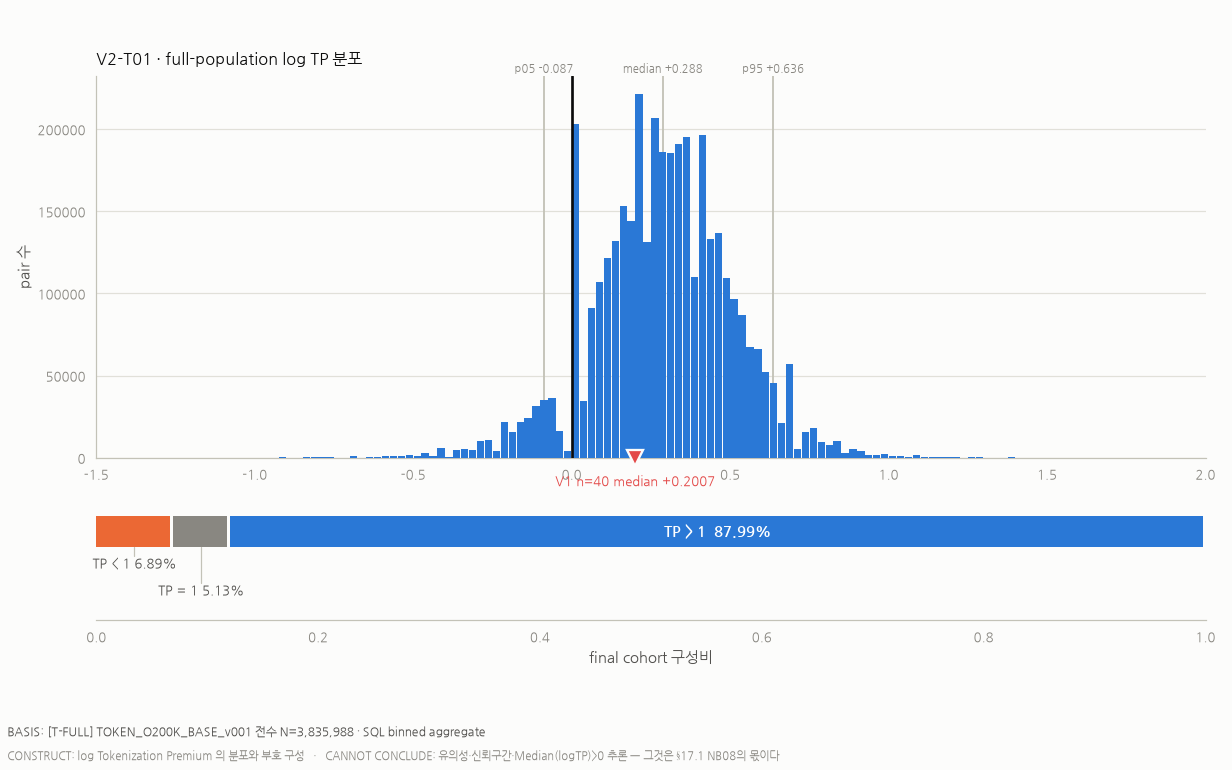

0.2s   RSS 0.746 GiB


In [10]:
# /**
#  * @cell V2-T01 — logTP 분포를 full-population binned histogram으로, 부호 share를 함께 그린다.
#  * @question 분포의 모양(단봉/치우침/꼬리)과 0 기준 좌우 질량은?
#  * @ssot §13.1; §16.1
#  * @input TOKEN_O200K_BASE_v001
#  * @population_or_sample [T-FULL] 전수 binned aggregate
#  * @method SQL binned count (원자료 미반출) + 분위수 참조선
#  * @output F: V2-T01
#  * @claim_boundary 분포 그림이며 검정이 아니다. 0 오른쪽 질량이 크다는 사실이 유의성을 뜻하지 않는다.
#  * @v1_link V1 sample40 median logTP=+0.2007 위치를 참조선으로 겹쳐 표시한다.
#  */

_t0 = time.time()
_LOTP, _HITP, _NBT = -1.5, 2.0, 140
_h = binned_hist(_con, TOK, "log_token_premium", _LOTP, _HITP, _NBT)

fig, (ax, axb) = plt.subplots(2, 1, figsize=(11.2, 7.0), height_ratios=[3.0, 0.9], sharex=False)
_w = (_HITP - _LOTP) / _NBT
# @line 단일 계열이므로 legend를 두지 않는다(제목이 측정치를 명명한다).
ax.bar(_h.bin_center, _h.n, width=_w * 0.92, color=PALETTE["ko"], edgecolor="none", zorder=3)
# @line 0선은 'KO와 EN의 token 수가 같음'이라는 이 그림의 기준이다.
ax.axvline(0.0, color=INK["primary"], linewidth=MARK["hairline"] * 2.2, zorder=4)
for _q, _lab in ((TP_Q.loc["log_token_premium", "p05"], "p05"),
                 (TP_Q.loc["log_token_premium", "median"], "median"),
                 (TP_Q.loc["log_token_premium", "p95"], "p95")):
    ax.axvline(_q, color=INK["baseline"], linewidth=MARK["hairline"] * 1.5, zorder=2)
    # @line 분위 라벨을 막대 위에 얹으면 데이터를 가린다. 축 '밖' 위쪽에 가로로 둔다.
    ax.text(_q, 1.005, f"{_lab} {_q:+.3f}", transform=ax.get_xaxis_transform(),
            fontsize=7.5, color=INK["muted"], ha="center", va="bottom")
# @line V1의 40건 중앙값은 마커로 표시하되(점선은 anti-pattern), 라벨은 막대가 없는 왼쪽 여백에 둔다.
ax.plot([V1_FROZEN_AGG["logTP"]], [0], marker="v", markersize=10, clip_on=False,
        color=PALETTE["log_cp"], markeredgecolor=INK["surface"], markeredgewidth=1.5, zorder=6)
# @line 라벨을 마커 바로 아래(축 밖)에 둔다. 긴 leader line은 plot 전체를 가로질러 잉크만 늘린다.
ax.text(V1_FROZEN_AGG["logTP"], -0.045, f"V1 n=40 median {V1_FROZEN_AGG['logTP']:+.4f}",
        transform=ax.get_xaxis_transform(), ha="center", va="top",
        fontsize=8.5, color=PALETTE["log_cp"])
ax.set_ylabel("pair 수"); ax.set_xlim(_LOTP, _HITP)
ax.set_title("V2-T01 · full-population log TP 분포", loc="left", color=INK["primary"], pad=8)
tidy(ax, xgrid=False, ygrid=True)

# @line 부호 share는 길이가 아니라 '구성'이므로 하나의 가로 stacked bar가 정확한 문법이다.
_left = 0.0
# @line 작은 세그먼트 두 개는 라벨을 서로 다른 높이에 두어야 겹치지 않는다.
_small_y = {"lt1": -0.42, "eq1": -0.86}
for _k, _c, _lab in (("lt1", PALETTE["en"], "TP < 1"), ("eq1", INK["muted"], "TP = 1"),
                     ("gt1", PALETTE["ko"], "TP > 1")):
    _v = TP_SIGN[_k]
    axb.barh(0, _v - MARK["gap"] / 8, left=_left, height=0.5, color=_c, edgecolor="none")
    # @line 세그먼트 안에 글자가 들어가는지 먼저 재고, 안 들어가면 밖으로 뺀다(잘린 라벨은 anti-pattern).
    if _v > 0.18:
        axb.text(_left + _v / 2, 0, f"{_lab}  {_v:.2%}", ha="center", va="center",
                 fontsize=9.5, color="#ffffff", fontweight="bold")
    else:
        axb.text(_left + _v / 2, _small_y[_k], f"{_lab} {_v:.2%}", ha="center", va="top",
                 fontsize=8.5, color=INK["secondary"])
        # @line 라벨이 어느 세그먼트 것인지 잃지 않도록 짧은 수직 연결선을 둔다.
        axb.plot([_left + _v / 2] * 2, [-0.26, _small_y[_k] + 0.02],
                 color=INK["baseline"], linewidth=MARK["hairline"], zorder=2)
    _left += _v
axb.set_xlim(0, 1); axb.set_ylim(-1.45, 0.42); axb.set_yticks([])
axb.set_xlabel("final cohort 구성비")
tidy(axb, xgrid=False, ygrid=False)
axb.spines["left"].set_visible(False)
caption(fig, f"[T-FULL] TOKEN_O200K_BASE_v001 전수 N={int(TP_SIGN['n']):,} · SQL binned aggregate",
        "log Tokenization Premium 의 분포와 부호 구성",
        "유의성·신뢰구간·Median(logTP)>0 추론 — 그것은 §17.1 NB08의 몫이다")
fig.tight_layout(rect=(0, 0.115, 1, 0.955))
plt.show()
print(f"{time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")

---

# 07 — Exact Decomposition · Population 구조

## @question
$\log TP$의 세 성분이 모집단에서 어떤 분포·부호 조합·결합 구조를 갖는가?

## @ssot
§8 / §8.1–8.4; Decision D-04; IR-01 (ByteDensityRatio와 CompressionPenalty를 **분리 보고**).

## @method
pair-wise identity $\lvert \log TP - (\log CR + \log BDR + \log CP)\rvert < \varepsilon$ 는
**이미 G2 PASS로 판정되었다.** 여기서는 **검증이 아니라 분포와 상대 구조의 시각화**다.

## @claim_boundary — 중앙값 분해 금지
$$\operatorname{median}(\log CR) + \operatorname{median}(\log BDR) + \operatorname{median}(\log CP)
\;\neq\; \operatorname{median}(\log TP)$$

중앙값은 가법적이지 않다. 성분 중앙값의 합을 $\log TP$ 중앙값의 분해로 **쓰지 않는다.**
가법 회계는 **pair 단위에서만** 성립한다.

In [11]:
# /**
#  * @cell 세 성분의 모집단 분포, 부호 조합, 결합 구조를 산출한다.
#  * @question 성분별 부호는 얼마나 안정적이며, CR+BDR 상쇄분과 CP는 어떤 관계인가?
#  * @ssot §8; IR-01; §32 T-06
#  * @input TOKEN_O200K_BASE_v001
#  * @population_or_sample [T-FULL] 전수
#  * @method 분위수 + 부호 조합 교차표 + pair 단위 offset(CR+BDR) 분포
#  * @output DEC_Q, DEC_SIGN, OFFSET_Q
#  * @claim_boundary 중앙값 합을 중앙값 분해로 쓰지 않는다. 회계 기여는 인과 기여가 아니다.
#  * @v1_link V1 sample40: logCR -0.8113 / logBDR +0.9004 / logCP +0.1360.
#  */

_t0 = time.time()
DEC_Q = quantiles(_con, TOK, ["log_code_point_ratio", "log_byte_density_ratio",
                              "log_compression_penalty", "log_token_premium"])
display(DEC_Q.round(4))

# @line 부호 조합은 '어떤 메커니즘 묶음이 실제로 함께 나타나는가'를 보여준다.
DEC_SIGN = _con.execute(f"""
    SELECT sign(log_code_point_ratio)::INT cr, sign(log_byte_density_ratio)::INT bdr,
           sign(log_compression_penalty)::INT cp, sign(log_token_premium)::INT tp,
           count(*) n
    FROM {TOK} GROUP BY 1,2,3,4 ORDER BY n DESC""").df()
DEC_SIGN["share"] = DEC_SIGN.n / DEC_SIGN.n.sum()
print("\n── 성분 부호 조합 (상위 8) — sign: -1/0/+1 ──")
display(DEC_SIGN.head(8).assign(share=lambda d: (d.share * 100).round(3)).rename(columns={"share": "share_%"}))

# @line pair 단위 offset을 직접 계산해야 '상쇄 후 남는 것'을 정확히 말할 수 있다(중앙값 합이 아니라).
OFFSET_Q = quantiles(_con, f"(SELECT log_code_point_ratio + log_byte_density_ratio AS cr_bdr_offset, "
                           f"log_compression_penalty AS cp, log_token_premium AS tp FROM {TOK})",
                     ["cr_bdr_offset", "cp", "tp"])
print("\n── pair 단위 상쇄 구조 (중앙값 합이 아니라 각 pair에서 계산) ──")
display(OFFSET_Q.round(4))
_share_cp = _con.execute(f"""
    SELECT avg(CASE WHEN abs(log_compression_penalty) >
                     abs(log_code_point_ratio + log_byte_density_ratio) THEN 1.0 ELSE 0 END)
    FROM {TOK}""").fetchone()[0]
print(f"\n  |logCP| > |logCR + logBDR| 인 pair 비율 = {_share_cp:.4%}")
print("  → 'tokenizer 압축 성분이 표현층 상쇄분보다 큰' pair가 모집단에서 차지하는 실제 비중이다.")
print(f"\n{time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")

,n,min,p01,p05,p25,median,p75,p95,p99,max,IQR
feature,,,,,,,,,,,
log_code_point_ratio,3835988,-3.8080,-1.2796,-1.0986,-0.8954,-0.7605,-0.6190,-0.3868,-0.1823,4.0943,0.2763
log_byte_density_ratio,3835988,-0.4055,0.6466,0.7571,0.8561,0.8961,0.9163,0.9445,0.9651,1.0986,0.0602
log_compression_penalty,3835988,-1.5404,-0.3254,-0.1671,0.0416,0.1752,0.2901,0.4407,0.5549,1.6376,0.2485
log_token_premium,3835988,-2.7486,-0.2877,-0.0870,0.1542,0.2877,0.4274,0.6360,0.8109,3.6376,0.2733



── 성분 부호 조합 (상위 8) — sign: -1/0/+1 ──


,cr,bdr,cp,tp,n,share_%
0,-1,1,1,1,2863051,74.637
1,-1,1,-1,1,490267,12.781
2,-1,1,-1,-1,138813,3.619
3,-1,1,1,-1,123550,3.221
4,-1,1,1,0,99801,2.602
5,-1,1,-1,0,85034,2.217
6,-1,1,0,0,10505,0.274
7,-1,1,0,1,10369,0.270



── pair 단위 상쇄 구조 (중앙값 합이 아니라 각 pair에서 계산) ──


,n,min,p01,p05,p25,median,p75,p95,p99,max,IQR
feature,,,,,,,,,,,
cr_bdr_offset,3835988,-2.9207,-0.4212,-0.2185,-0.0153,0.1193,0.2624,0.4906,0.6779,4.9698,0.2776
cp,3835988,-1.5404,-0.3254,-0.1671,0.0416,0.1752,0.2901,0.4407,0.5549,1.6376,0.2485
tp,3835988,-2.7486,-0.2877,-0.0870,0.1542,0.2877,0.4274,0.6360,0.8109,3.6376,0.2733



  |logCP| > |logCR + logBDR| 인 pair 비율 = 54.0427%
  → 'tokenizer 압축 성분이 표현층 상쇄분보다 큰' pair가 모집단에서 차지하는 실제 비중이다.

1.8s   RSS 0.74 GiB


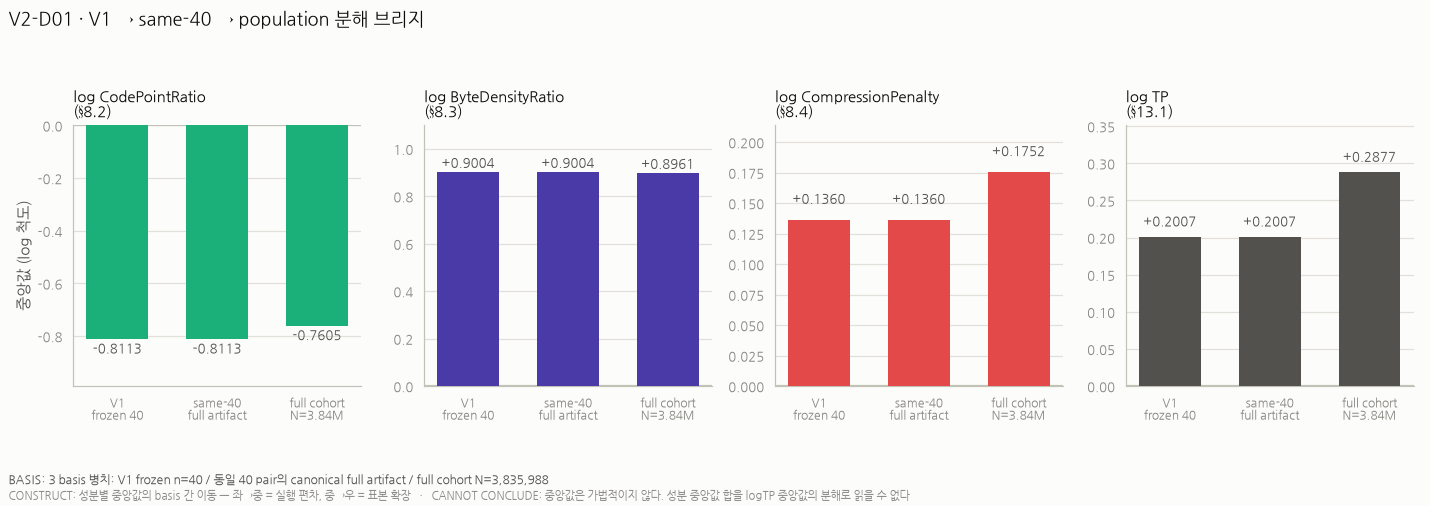

── 브리지 수치 ──


,V1 frozen 40,same-40 full artifact,"full cohort N=3,835,988",Δ 실행편차 (same40 − V1),Δ 표본확장 (full − same40)
component,,,,,
logTP,0.2007,0.2007,0.2877,-0.0,0.0870
logCR,-0.8113,-0.8113,-0.7605,-0.0,0.0509
logBDR,0.9004,0.9004,0.8961,0.0,-0.0043
logCP,0.1360,0.1360,0.1752,-0.0,0.0392


0.2s   RSS 0.742 GiB


In [12]:
# /**
#  * @cell V2-D01 — V1 frozen 40 → same-40 full artifact → full cohort 3열 브리지 그림.
#  * @question V1과의 차이는 실행 편차인가 표본 확장인가?
#  * @ssot Directive §10; SSOT §8
#  * @input V1_FROZEN_AGG, SAME40, DEC_Q
#  * @population_or_sample 3개 basis를 한 축에 병치 (n=40 / n=40 / N=3,835,988)
#  * @method 동일 통계량(중앙값)을 세 basis에서 계산해 성분별로 나란히 배치
#  * @output F: V2-D01
#  * @claim_boundary 40건 중앙값은 모집단 추정치가 아니다. 이 그림은 차이의 '원인 분리' 도구다.
#  * @v1_link 이 그림이 V1↔V2 브리지 그 자체다.
#  */

_t0 = time.time()
_COMPS = [("logCR", "log CodePointRatio\n(§8.2)", PALETTE["log_cr"]),
          ("logBDR", "log ByteDensityRatio\n(§8.3)", PALETTE["log_bdr"]),
          ("logCP", "log CompressionPenalty\n(§8.4)", PALETTE["log_cp"]),
          ("logTP", "log TP\n(§13.1)", INK["secondary"])]
_BASES = ["V1 frozen 40", "same-40 full artifact", "full cohort N=3,835,988"]

fig, axes = plt.subplots(1, 4, figsize=(13.0, 4.6))
for _ax, (_k, _lab, _c) in zip(axes, _COMPS):
    _vals = [BRIDGE.loc[_k, b] for b in _BASES]
    _x = np.arange(3)
    # @line 성분 순서는 CR→BDR→CP 고정이며, 이 위치 자체가 색과 독립인 보조 부호다(CVD floor band 대응).
    _ax.bar(_x, _vals, width=MARK["bar_max"], color=_c, edgecolor="none", zorder=3)
    for _xi, _v in zip(_x, _vals):
        # @line 세 값 전부 직접 label한다 — 값이 3개뿐이라 축 눈금보다 빠르게 읽힌다.
        _ax.text(_xi, _v + (0.012 if _v >= 0 else -0.012), f"{_v:+.4f}", ha="center",
                 va="bottom" if _v >= 0 else "top", fontsize=8.5, color=INK["secondary"])
    _ax.axhline(0, color=INK["baseline"], linewidth=MARK["hairline"] * 1.8, zorder=1)
    _ax.set_xticks(_x)
    _ax.set_xticklabels(["V1\nfrozen 40", "same-40\nfull artifact", "full cohort\nN=3.84M"], fontsize=8)
    _ax.set_title(_lab, loc="left", color=INK["primary"], fontsize=9.5, pad=6)
    _ax.margins(y=0.22)
    tidy(_ax, xgrid=False, ygrid=True)
axes[0].set_ylabel("중앙값 (log 척도)")
fig.suptitle("V2-D01 · V1 → same-40 → population 분해 브리지",
             x=0.006, ha="left", fontsize=12, color=INK["primary"])
caption(fig, "3 basis 병치: V1 frozen n=40 / 동일 40 pair의 canonical full artifact / full cohort N=3,835,988",
        "성분별 중앙값의 basis 간 이동 — 좌→중 = 실행 편차, 중→우 = 표본 확장",
        "중앙값은 가법적이지 않다. 성분 중앙값 합을 logTP 중앙값의 분해로 읽을 수 없다")
fig.tight_layout(rect=(0, 0.135, 1, 0.925))
plt.show()

print("── 브리지 수치 ──")
display(BRIDGE.round(4))
print(f"{time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")

---

# 08 — Morphology · Full Population (D-03)

## @question
full D-03에서 형태소 구조의 분포는 무엇이며, **측정 경계 구역**은 어디인가?

## @ssot
§12.3 D-03; §13.6 MorphemeDensity($=\text{MorphemeCount}/\text{EojeolCount}$); §13.7 Particle/Ending Ratio;
§15 형태소 고정 규약; §32 T-05 analyzer measurement error.

## @population_or_sample
**[M-FULL]** `MORPH_FEATURES_KIWI_v001`, N = 3,835,988. **V1에는 없던 층이다** (V1은 `[M-SAMPLE40]`).

## @method — 경계 구역을 반드시 분리
Claude-B의 caveat대로 `eojeol_count = 1` 구역(**N = 42,096**)을 **별도 표시**한다.
어절이 1개면 `morpheme_density`의 분모가 1이라 밀도가 곧 형태소 개수가 되어 척도가 달라진다.

## @claim_boundary
density 극댓값을 **"linguistic complexity"라고 부르지 않는다.**
라벨은 `MEASUREMENT_BOUNDARY_REGION` / `PLAUSIBLE_EXTREME`만 쓴다.
`morpheme_sequence`(원문 표면형 포함)는 읽지 않는다 — 불필요하고 hygiene 위험이다.

In [13]:
# /**
#  * @cell full D-03 형태소 분포를 산출하고 eojeol_count=1 측정 경계 구역을 분리한다.
#  * @question 형태소 밀도·비율의 모집단 분포와, 경계 구역이 그 분포를 어떻게 왜곡하는가?
#  * @ssot §12.3/§13.6/§13.7; §32 T-05
#  * @input MORPH_FEATURES_KIWI_v001 (nested morpheme_sequence는 읽지 않는다)
#  * @population_or_sample [M-FULL] 전수 + 경계 구역 분리 집계
#  * @method 전체 분위수 / eojeol_count=1 구역 분위수 / 제외 구역 분위수 3벌
#  * @output MORPH_Q, MORPH_Q_BOUNDARY, MORPH_Q_MAIN, MORPH_BOUNDARY(dict)
#  * @claim_boundary density 극값 = 측정 경계 현상일 수 있다. 언어적 복잡도로 해석 금지.
#  * @v1_link V1은 n=40 재계산이었고 경계 구역을 관측할 표본이 없었다.
#  */

_t0 = time.time()
_MCOLS = ["eojeol_count", "morpheme_count", "morpheme_density", "particle_count", "ending_count",
          "deriv_affix_count", "particle_ratio", "ending_ratio", "deriv_affix_ratio",
          "function_morpheme_ratio"]

MORPH_BOUNDARY = _con.execute(f"""
    SELECT count(*) n,
      sum(CASE WHEN eojeol_count = 1 THEN 1 ELSE 0 END) n_eojeol1,
      sum(CASE WHEN analysis_warning_flag THEN 1 ELSE 0 END) n_warn,
      sum(CASE WHEN morpheme_count = 0 THEN 1 ELSE 0 END) n_zero_morph,
      sum(CASE WHEN particle_ratio IS NULL THEN 1 ELSE 0 END) n_null_ratio
    FROM {MOR}""").df().iloc[0].to_dict()
print(f"── D-03 전수 (N={int(MORPH_BOUNDARY['n']):,}) ──")
print(f"  eojeol_count = 1 (MEASUREMENT_BOUNDARY_REGION) : {int(MORPH_BOUNDARY['n_eojeol1']):,}"
      f"  ({MORPH_BOUNDARY['n_eojeol1']/MORPH_BOUNDARY['n']:.4%})")
print(f"  analysis_warning_flag                          : {int(MORPH_BOUNDARY['n_warn']):,}")
print(f"  morpheme_count = 0                             : {int(MORPH_BOUNDARY['n_zero_morph']):,}")
print(f"  ratio NULL (morpheme_count=0 정의상)           : {int(MORPH_BOUNDARY['n_null_ratio']):,}")

MORPH_Q = quantiles(_con, MOR, _MCOLS)
MORPH_Q_BOUNDARY = quantiles(_con, MOR, _MCOLS, where="eojeol_count = 1")
MORPH_Q_MAIN = quantiles(_con, MOR, _MCOLS, where="eojeol_count > 1")
print("\n── 전체 ──"); display(MORPH_Q.round(4))
print("── MEASUREMENT_BOUNDARY_REGION (eojeol_count = 1) ──"); display(MORPH_Q_BOUNDARY.round(4))
print("── 경계 제외 (eojeol_count > 1) ──"); display(MORPH_Q_MAIN.round(4))
print("\n[해석 경계] 위 세 표의 차이는 측정 척도의 차이이지 언어 복잡도의 차이가 아니다.")
print(f"{time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")

── D-03 전수 (N=3,835,988) ──
  eojeol_count = 1 (MEASUREMENT_BOUNDARY_REGION) : 42,096  (1.0974%)
  analysis_warning_flag                          : 0
  morpheme_count = 0                             : 0
  ratio NULL (morpheme_count=0 정의상)           : 0



── 전체 ──


,n,min,p01,p05,p25,median,p75,p95,p99,max,IQR
feature,,,,,,,,,,,
eojeol_count,3835988,1.0,1.0,3.0000,6.0000,9.0000,16.0000,24.0000,29.0,158.0000,10.0000
morpheme_count,3835988,1.0,4.0,7.0000,13.0000,19.0000,34.0000,53.0000,63.0,291.0000,21.0000
morpheme_density,3835988,0.5,1.6,1.7727,2.0000,2.2143,2.4667,3.0000,4.0,30.0000,0.4667
particle_count,3835988,0.0,0.0,0.0000,2.0000,3.0000,6.0000,10.0000,13.0,40.0000,4.0000
ending_count,3835988,0.0,0.0,1.0000,2.0000,4.0000,5.0000,9.0000,11.0,39.0000,3.0000
deriv_affix_count,3835988,0.0,0.0,0.0000,0.0000,1.0000,3.0000,5.0000,7.0,23.0000,3.0000
particle_ratio,3835988,0.0,0.0,0.0000,0.1154,0.1579,0.2000,0.2500,0.3,0.6000,0.0846
ending_ratio,3835988,0.0,0.0,0.0769,0.1333,0.1754,0.2222,0.3182,0.4,0.6667,0.0889
deriv_affix_ratio,3835988,0.0,0.0,0.0000,0.0000,0.0652,0.1000,0.1522,0.2,0.5000,0.1000


── MEASUREMENT_BOUNDARY_REGION (eojeol_count = 1) ──


,n,min,p01,p05,p25,median,p75,p95,p99,max,IQR
feature,,,,,,,,,,,
eojeol_count,42096,1.0,1.0,1.0,1.0,1.0000,1.00,1.00,1.0000,1.0000,0.00
morpheme_count,42096,1.0,2.0,2.0,3.0,4.0000,5.00,6.00,7.0000,30.0000,2.00
morpheme_density,42096,1.0,2.0,2.0,3.0,4.0000,5.00,6.00,7.0000,30.0000,2.00
particle_count,42096,0.0,0.0,0.0,0.0,0.0000,0.00,1.00,2.0000,6.0000,0.00
ending_count,42096,0.0,0.0,0.0,0.0,1.0000,1.00,2.00,3.0000,6.0000,1.00
deriv_affix_count,42096,0.0,0.0,0.0,0.0,0.0000,0.00,1.00,1.0000,2.0000,0.00
particle_ratio,42096,0.0,0.0,0.0,0.0,0.0000,0.00,0.25,0.3333,0.6000,0.00
ending_ratio,42096,0.0,0.0,0.0,0.0,0.1667,0.25,0.40,0.5000,0.6667,0.25
deriv_affix_ratio,42096,0.0,0.0,0.0,0.0,0.0000,0.00,0.20,0.2500,0.5000,0.00


── 경계 제외 (eojeol_count > 1) ──


,n,min,p01,p05,p25,median,p75,p95,p99,max,IQR
feature,,,,,,,,,,,
eojeol_count,3793892,2.0,2.0000,3.0000,6.0000,9.0000,16.0000,24.0000,29.0000,158.0000,10.0000
morpheme_count,3793892,2.0,5.0000,8.0000,13.0000,20.0000,34.0000,53.0000,63.0000,291.0000,21.0000
morpheme_density,3793892,0.5,1.6000,1.7692,2.0000,2.2000,2.4500,3.0000,3.5000,9.6667,0.4500
particle_count,3793892,0.0,0.0000,0.0000,2.0000,3.0000,6.0000,10.0000,13.0000,40.0000,4.0000
ending_count,3793892,0.0,0.0000,1.0000,2.0000,4.0000,5.0000,9.0000,12.0000,39.0000,3.0000
deriv_affix_count,3793892,0.0,0.0000,0.0000,0.0000,1.0000,3.0000,5.0000,7.0000,23.0000,3.0000
particle_ratio,3793892,0.0,0.0000,0.0000,0.1176,0.1579,0.2000,0.2500,0.3000,0.6000,0.0824
ending_ratio,3793892,0.0,0.0000,0.0816,0.1333,0.1754,0.2222,0.3158,0.3889,0.6364,0.0889
deriv_affix_ratio,3793892,0.0,0.0000,0.0000,0.0000,0.0667,0.1000,0.1515,0.1935,0.4444,0.1000



[해석 경계] 위 세 표의 차이는 측정 척도의 차이이지 언어 복잡도의 차이가 아니다.
3.8s   RSS 0.912 GiB


/tmp/ipykernel_165542/364948938.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0.135, 1, 0.955))


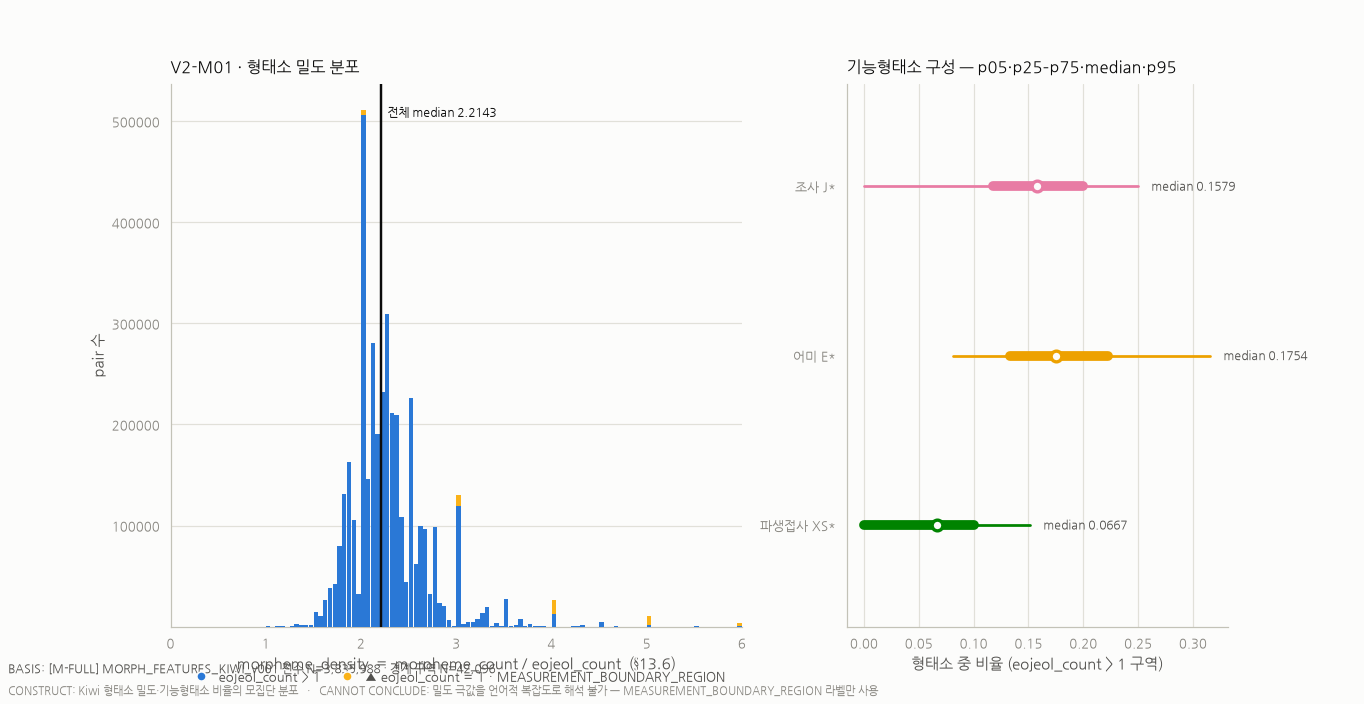

0.3s   RSS 0.918 GiB


In [14]:
# /**
#  * @cell V2-M01 — 형태소 밀도 분포를 경계 구역과 본 구역으로 나누어 그리고, 기능형태소 구성을 함께 보인다.
#  * @question 경계 구역이 전체 분포의 어느 지점을 만들고 있는가?
#  * @ssot §13.6/§13.7
#  * @input MORPH_FEATURES_KIWI_v001
#  * @population_or_sample [M-FULL] 전수 binned aggregate
#  * @method 두 층(경계/본 구역)을 같은 축에 stacked bar로 쌓아 기여를 분리
#  * @output F: V2-M01
#  * @claim_boundary 봉우리를 언어 현상으로 해석하지 않는다. 라벨은 측정 경계 용어만 쓴다.
#  * @v1_link V1은 이 층 자체를 갖지 못했다 (NOT AVAILABLE AT V1).
#  */

_t0 = time.time()
_LOD, _HID, _NBD = 0.0, 6.0, 120
_h_main = binned_hist(_con, MOR, "morpheme_density", _LOD, _HID, _NBD, where="eojeol_count > 1")
_h_bnd = binned_hist(_con, MOR, "morpheme_density", _LOD, _HID, _NBD, where="eojeol_count = 1")
_wd = (_HID - _LOD) / _NBD
_idx = pd.Index(range(_NBD))
_m = _h_main.set_index(((_h_main.bin_left - _LOD) / _wd).round().astype(int)).n.reindex(_idx, fill_value=0)
_b = _h_bnd.set_index(((_h_bnd.bin_left - _LOD) / _wd).round().astype(int)).n.reindex(_idx, fill_value=0)
_ctr = _LOD + (_idx.to_numpy() + 0.5) * _wd

fig = plt.figure(figsize=(12.4, 6.4))
gs = fig.add_gridspec(1, 2, width_ratios=[1.5, 1.0], wspace=0.22)
ax = fig.add_subplot(gs[0, 0])
# @line 두 층을 쌓아야 '전체 분포의 이 봉우리는 경계 구역이 만든 것'이 한 눈에 보인다.
ax.bar(_ctr, _m.to_numpy(), width=_wd * 0.92, color=PALETTE["ko"], edgecolor="none",
       zorder=3, label="eojeol_count > 1")
ax.bar(_ctr, _b.to_numpy(), bottom=_m.to_numpy(), width=_wd * 0.92, color=STATUS["warning"],
       edgecolor="none", zorder=3, label="eojeol_count = 1 (측정 경계)")
ax.axvline(MORPH_Q.loc["morpheme_density", "median"], color=INK["primary"],
           linewidth=MARK["hairline"] * 2.0, zorder=4)
ax.text(MORPH_Q.loc["morpheme_density", "median"], ax.get_ylim()[1] * 0.96,
        f"  전체 median {MORPH_Q.loc['morpheme_density','median']:.4f}", fontsize=8, color=INK["primary"], va="top")
ax.set_xlabel("morpheme_density  =  morpheme_count / eojeol_count  (§13.6)")
ax.set_ylabel("pair 수"); ax.set_xlim(_LOD, _HID)
ax.set_title("V2-M01 · 형태소 밀도 분포", loc="left", color=INK["primary"], pad=8)
tidy(ax, xgrid=False, ygrid=True)

# @line 기능형태소 구성은 합이 1이 아니므로(잔여 존재) 누적이 아니라 나란한 분포로 보여야 정직하다.
axr = fig.add_subplot(gs[0, 1])
_RAT = [("particle_ratio", "조사 J*", PALETTE["morph_particle"]),
        ("ending_ratio", "어미 E*", PALETTE["morph_ending"]),
        ("deriv_affix_ratio", "파생접사 XS*", PALETTE["morph_deriv"])]
for _yi, (_c, _lab, _col) in enumerate(_RAT):
    _row = MORPH_Q_MAIN.loc[_c]
    # @line p05–p95를 선으로, p25–p75를 굵은 선으로, median을 점으로 — box plot의 잉크를 줄인 형태다.
    axr.plot([_row.p05, _row.p95], [_yi, _yi], color=_col, linewidth=MARK["line_w"] * 0.9, zorder=3)
    axr.plot([_row.p25, _row.p75], [_yi, _yi], color=_col, linewidth=MARK["line_w"] * 3.2, zorder=4)
    axr.plot([_row["median"]], [_yi], marker="o", markersize=MARK["marker"] + 1, color=INK["surface"],
             markeredgecolor=_col, markeredgewidth=2.2, zorder=5)
    axr.text(_row.p95 + 0.012, _yi, f"median {_row['median']:.4f}", va="center",
             fontsize=8, color=INK["secondary"])
axr.set_yticks(range(len(_RAT))); axr.set_yticklabels([l for _, l, _ in _RAT])
axr.set_ylim(-0.6, len(_RAT) - 0.4); axr.invert_yaxis()
axr.set_xlabel("형태소 중 비율 (eojeol_count > 1 구역)")
axr.set_title("기능형태소 구성 — p05·p25–p75·median·p95", loc="left", color=INK["primary"], pad=8)
tidy(axr, xgrid=True, ygrid=False)
caption(fig, f"[M-FULL] MORPH_FEATURES_KIWI_v001 전수 N={int(MORPH_BOUNDARY['n']):,} · 경계 구역 N={int(MORPH_BOUNDARY['n_eojeol1']):,}",
        "Kiwi 형태소 밀도·기능형태소 비율의 모집단 분포",
        "밀도 극값을 언어적 복잡도로 해석 불가 — MEASUREMENT_BOUNDARY_REGION 라벨만 사용")
fig.tight_layout(rect=(0, 0.135, 1, 0.955))
# @line status 색은 항상 라벨과 함께 쓴다. 제목이 길어 축 위에는 자리가 없으므로 x축 라벨 아래로 내린다.
legend_keys(ax, {"eojeol_count > 1": PALETTE["ko"],
                 "▲ eojeol_count = 1 · MEASUREMENT_BOUNDARY_REGION": STATUS["warning"]},
            ncol=2, where="below")
plt.show()
print(f"{time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")

---

# 09 — Morphology × Token Premium (descriptive only)

## @question
형태소 수량과 $\log TP$ / $\log CP$ 사이에 **기술적(descriptive)** 관계가 있는가?

## @ssot
§6.4 RQ4 — **여기서 검정하지 않는다**; §19.1–19.2 (M1 vs M2); §32 T-06.

## @method
- **population binned conditional medians**: 형태소 분위 구간별 $\log TP$ / $\log CP$ 중앙값 (full N).
- **length 층화**: 길이가 두 변수 모두를 움직이므로 `eojeol_count` 층 안에서 다시 본다.
- Spearman이 필요하면 결정론적 표본으로만 하고 `[V2-SAMPLE<n>]`로 명시한다.

## @claim_boundary
- causal language **금지** · M1→M2 inference **금지** · model significance **금지**.
- V1과 동일하게, 이것은 RQ4의 **조건부/증분** 연관이 **아니다**.
  통제변수가 없으므로 §6.4에 답하지 않는다 — 그것은 NB09의 몫이다.

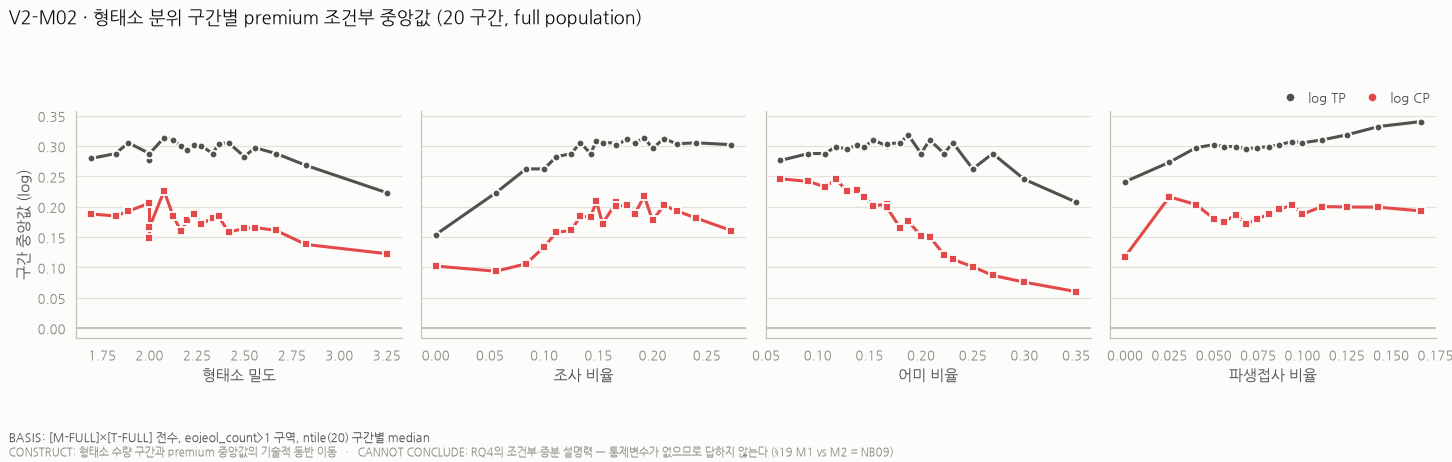

── 구간별 수치 (각 변수 처음/중간/끝 구간) ──


,label,q,n,x_med,logTP_med,logCP_med
0,형태소 밀도,1,189695,1.6923,0.2796,0.1881
9,형태소 밀도,10,189695,2.2000,0.2938,0.1778
19,형태소 밀도,20,189694,3.2500,0.2231,0.1226
20,조사 비율,1,189695,0.0000,0.1542,0.1023
29,조사 비율,10,189695,0.1538,0.3054,0.1723
39,조사 비율,20,189694,0.2727,0.3023,0.1606
40,어미 비율,1,189695,0.0638,0.2763,0.2460
49,어미 비율,10,189695,0.1667,0.3037,0.1996
59,어미 비율,20,189694,0.3500,0.2076,0.0602
60,파생접사 비율,1,189695,0.0000,0.2412,0.1178


1.6s   RSS 1.848 GiB


In [15]:
# /**
#  * @cell 형태소 분위 구간별 logTP/logCP 조건부 중앙값을 full population에서 산출한다.
#  * @question 형태소 수량이 커질수록 premium 중앙값이 체계적으로 움직이는가 (기술적으로)?
#  * @ssot §6.4(검정 아님); §13.6/§13.7; §32 T-06
#  * @input MORPH ⋈ TOK (pair_id)
#  * @population_or_sample [M-FULL]×[T-FULL] 전수 binned conditional aggregate
#  * @method ntile(20) 분위 구간 → 구간별 median. 길이 층화는 eojeol_count 구간으로 별도 수행.
#  * @output MORPH_TP_BINS(DataFrame)
#  * @claim_boundary 조건부 중앙값이며 회귀도 검정도 아니다. RQ4에 답하지 않는다.
#  * @v1_link V1은 n=40 raw Spearman(|rho|<=0.192)이었다. 여기서는 모집단 조건부 중앙값이다.
#  */

_t0 = time.time()
_BINVARS = [("morpheme_density", "형태소 밀도"), ("particle_ratio", "조사 비율"),
            ("ending_ratio", "어미 비율"), ("deriv_affix_ratio", "파생접사 비율")]
_frames = []
for _v, _lab in _BINVARS:
    # @line 경계 구역(eojeol_count=1)을 제외해야 분위 구간이 척도가 다른 값들과 섞이지 않는다.
    _d = _con.execute(f"""
      WITH j AS (
        SELECT m.{_v} AS x, t.log_token_premium AS ltp, t.log_compression_penalty AS lcp
        FROM {MOR} m JOIN {TOK} t ON m.pair_id = t.pair_id
        WHERE m.eojeol_count > 1 AND m.{_v} IS NOT NULL),
      b AS (SELECT *, ntile(20) OVER (ORDER BY x) AS q FROM j)
      SELECT q, count(*) n, median(x) x_med, median(ltp) logTP_med, median(lcp) logCP_med
      FROM b GROUP BY 1 ORDER BY 1""").df()
    _d["variable"] = _v; _d["label"] = _lab
    _frames.append(_d)
MORPH_TP_BINS = pd.concat(_frames, ignore_index=True)

fig, axes = plt.subplots(1, len(_BINVARS), figsize=(13.2, 4.2), sharey=True)
for _ax, (_v, _lab) in zip(axes, _BINVARS):
    _d = MORPH_TP_BINS[MORPH_TP_BINS.variable == _v]
    # @line 두 결과 수량은 decomposition family 색을 그대로 써 §8과 의미를 잇는다.
    _ax.plot(_d.x_med, _d.logTP_med, marker="o", markersize=MARK["marker"] - 1,
             linewidth=MARK["line_w"], color=INK["secondary"],
             markeredgecolor=INK["surface"], markeredgewidth=1.2, zorder=4)
    _ax.plot(_d.x_med, _d.logCP_med, marker="s", markersize=MARK["marker"] - 1,
             linewidth=MARK["line_w"], color=PALETTE["log_cp"],
             markeredgecolor=INK["surface"], markeredgewidth=1.2, zorder=4)
    _ax.axhline(0, color=INK["baseline"], linewidth=MARK["hairline"] * 1.6, zorder=1)
    _ax.set_xlabel(_lab)
    tidy(_ax, xgrid=False, ygrid=True)
axes[0].set_ylabel("구간 중앙값 (log)")
legend_keys(axes[-1], {"log TP": INK["secondary"], "log CP": PALETTE["log_cp"]}, ncol=2, where="above")
fig.suptitle("V2-M02 · 형태소 분위 구간별 premium 조건부 중앙값 (20 구간, full population)",
             x=0.006, ha="left", fontsize=11.5, color=INK["primary"])
caption(fig, f"[M-FULL]×[T-FULL] 전수, eojeol_count>1 구역, ntile(20) 구간별 median",
        "형태소 수량 구간과 premium 중앙값의 기술적 동반 이동",
        "RQ4의 조건부·증분 설명력 — 통제변수가 없으므로 답하지 않는다 (§19 M1 vs M2 = NB09)")
fig.tight_layout(rect=(0, 0.135, 1, 0.925))
plt.show()

print("── 구간별 수치 (각 변수 처음/중간/끝 구간) ──")
display(MORPH_TP_BINS[MORPH_TP_BINS.q.isin([1, 10, 20])]
        [["label", "q", "n", "x_med", "logTP_med", "logCP_med"]].round(4))
print(f"{time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")

[V2-SAMPLE200000] 결정론적 표본 (seed 2995913794, md5 순서) — 모집단 아님


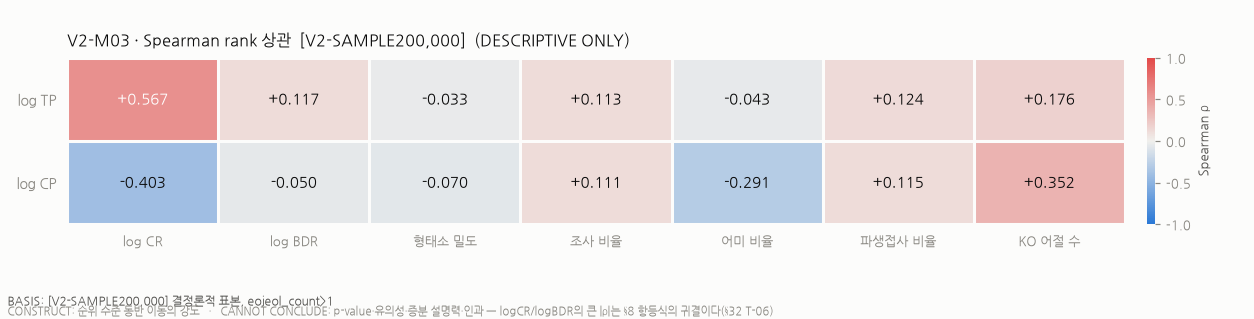

,log CR,log BDR,형태소 밀도,조사 비율,어미 비율,파생접사 비율,KO 어절 수
log TP,0.567,0.117,-0.033,0.113,-0.043,0.124,0.176
log CP,-0.403,-0.050,-0.070,0.111,-0.291,0.115,0.352


1.2s   RSS 2.493 GiB


In [16]:
# /**
#  * @cell 결정론적 표본에서 Spearman rank 상관을 계산한다(전수 상관은 자원 대비 이득이 없다).
#  * @question 순위 수준의 동반 이동 강도는 얼마인가?
#  * @ssot §32 T-06; §17.3 (p-value 단독 보고 금지 → 여기서는 계산조차 하지 않는다)
#  * @input MORPH ⋈ TOK ⋈ REP 결정론적 표본
#  * @population_or_sample [V2-SAMPLE200000] — 명시적 표본이며 전수가 아니다
#  * @method md5(pair_id||frozen seed) 순서 상위 n행 → scipy.stats.spearmanr (rho만 사용)
#  * @output SPEARMAN(DataFrame)
#  * @claim_boundary rho만 보고한다. p-value·유의성·인과 없음. 표본이므로 모집단 상관이 아니다.
#  * @v1_link V1 n=40에서 |rho|<=0.192였다. 표본을 5000배 키우면 어떻게 되는지 본다.
#  */

_t0 = time.time()
from scipy import stats  # noqa: E402
V2_SAMPLE_N = 200_000
_S = det_sample(_con, f"""(SELECT t.pair_id, t.log_token_premium, t.log_compression_penalty,
        t.log_code_point_ratio, t.log_byte_density_ratio,
        m.morpheme_density, m.particle_ratio, m.ending_ratio, m.deriv_affix_ratio,
        r.ko_eojeol_count
     FROM {TOK} t JOIN {MOR} m ON t.pair_id=m.pair_id JOIN {REP} r ON t.pair_id=r.pair_id
     WHERE m.eojeol_count > 1)""",
    ["pair_id", "log_token_premium", "log_compression_penalty", "log_code_point_ratio",
     "log_byte_density_ratio", "morpheme_density", "particle_ratio", "ending_ratio",
     "deriv_affix_ratio", "ko_eojeol_count"], V2_SAMPLE_N)
print(f"[V2-SAMPLE{len(_S)}] 결정론적 표본 (seed 2995913794, md5 순서) — 모집단 아님")

_OUT = [("log_token_premium", "log TP"), ("log_compression_penalty", "log CP")]
_EXP = [("log_code_point_ratio", "log CR"), ("log_byte_density_ratio", "log BDR"),
        ("morpheme_density", "형태소 밀도"), ("particle_ratio", "조사 비율"),
        ("ending_ratio", "어미 비율"), ("deriv_affix_ratio", "파생접사 비율"),
        ("ko_eojeol_count", "KO 어절 수")]
# @line rho만 저장한다 — p-value를 저장하지 않는 것 자체가 §17.3 준수를 코드로 강제하는 방법이다.
SPEARMAN = pd.DataFrame(
    [[stats.spearmanr(_S[o], _S[e]).statistic for e, _ in _EXP] for o, _ in _OUT],
    index=[l for _, l in _OUT], columns=[l for _, l in _EXP])

fig, ax = plt.subplots(figsize=(11.4, 2.9))
_norm = TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0)
_im = ax.imshow(SPEARMAN.to_numpy(), cmap=DIVERGING, norm=_norm, aspect="auto")
ax.set_xticks(range(len(_EXP))); ax.set_xticklabels(SPEARMAN.columns, fontsize=8.5)
ax.set_yticks(range(len(_OUT))); ax.set_yticklabels(SPEARMAN.index, fontsize=9)
for _i in range(SPEARMAN.shape[0]):
    for _j in range(SPEARMAN.shape[1]):
        _v = SPEARMAN.iat[_i, _j]
        # @line 모든 cell에 수치를 병기해 색이 값을 게이트하지 않게 한다(= table view 겸용).
        ax.text(_j, _i, f"{_v:+.3f}", ha="center", va="center", fontsize=9.5,
                color="#ffffff" if abs(_v) > 0.55 else INK["primary"])
ax.set_xticks(np.arange(-0.5, len(_EXP), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(_OUT), 1), minor=True)
ax.grid(which="minor", color=INK["surface"], linewidth=2.0); ax.grid(which="major", visible=False)
ax.tick_params(which="minor", length=0)
for _s in ax.spines.values(): _s.set_visible(False)
_cb = fig.colorbar(_im, ax=ax, fraction=0.02, pad=0.02)
_cb.set_label("Spearman ρ", fontsize=8.5, color=INK["secondary"]); _cb.outline.set_visible(False)
ax.set_title(f"V2-M03 · Spearman rank 상관  [V2-SAMPLE{len(_S):,}]  (DESCRIPTIVE ONLY)",
             loc="left", color=INK["primary"], pad=8)
caption(fig, f"[V2-SAMPLE{len(_S):,}] 결정론적 표본, eojeol_count>1",
        "순위 수준 동반 이동의 강도",
        "p-value·유의성·증분 설명력·인과 — logCR/logBDR의 큰 |ρ|는 §8 항등식의 귀결이다(§32 T-06)")
fig.tight_layout(rect=(0, 0.17, 0.99, 0.95))
plt.show()
display(SPEARMAN.round(3))
print(f"{time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")

---

# 10 — G5 Identifiability Diagnostics (V2의 핵심 PRE-G5 역할)

## @question
`domain` · `source_id` · `logical_corpus` · `translation_direction`의 support 구조는
회귀에서 이 축들을 **분리 추정 가능하게** 하는가?

## @ssot
§20.1 Random vs Fixed; §20.2 Identifiability Gate (**Gate G-ID**); §32 T-04 domain-source confounding;
§9.2 층화 변수.

## @method
full cohort에서 5개 교차표를 만들고, 각 조합의 **support N · 배타적 support 여부 · 중첩(nested) 여부**를 판정한다.

## @v1_link — V1이 남긴 미검증 지점
V1 caveat **C3**은 명시적으로 이렇게 적었다:

> `logical_corpus`는 `source_id`가 아니다. V1은 `domain × source_id`를 교차표로 만들지 **않았다**.
> 따라서 V1은 source confounding을 식별했다고 인용될 수 없다.

**V2는 그 지점을 정확히 메운다.**

## @claim_boundary
provisional classification은 **G-ID candidate evidence**이며 **formal G5 verdict가 아니다.**
G5 판정 권한은 이 lane에 없다.

In [17]:
# /**
#  * @cell 5개 설계 축 교차표를 full cohort에서 만들고 support 구조를 provisional 분류한다.
#  * @question 각 축 쌍이 서로를 결정하는가(=분리 추정 불가), 아니면 독립적 support를 갖는가?
#  * @ssot §20.1/§20.2 Gate G-ID; §32 T-04
#  * @input PAIR_REGISTRY_v002 ⋈ (cohort = REP_FEATURES_v002 pair_id)
#  * @population_or_sample [DESIGN-FULL] 전수 N=3,835,988
#  * @method 교차표 + zero-cell 구조 + 함수적 종속성(한 값이 다른 값을 결정하는가) 검사
#  * @output XTABS(dict[str,DataFrame]), IDENT(DataFrame)
#  * @claim_boundary G-ID candidate evidence. formal G5 verdict 아님.
#  * @v1_link V1 caveat C3이 미검증으로 남긴 domain x source_id를 여기서 처음 만든다.
#  */

_t0 = time.time()
# @line cohort로 제한해야 registry의 5.65M superset이 아니라 final cohort 구조를 본다.
_COH = f"(SELECT g.* FROM {REG} g SEMI JOIN {REP} f ON g.pair_id = f.pair_id)"
_AXES = ["domain", "source_id", "logical_corpus", "translation_direction"]
_PAIRS = [("domain", "source_id"), ("domain", "logical_corpus"),
          ("domain", "translation_direction"), ("source_id", "translation_direction"),
          ("source_id", "logical_corpus")]

XTABS = {}
for _a, _b in _PAIRS:
    _d = _con.execute(f"SELECT {_a}, {_b}, count(*) n FROM {_COH} GROUP BY 1,2 ORDER BY 1,2").df()
    XTABS[f"{_a} × {_b}"] = _d.pivot_table(index=_a, columns=_b, values="n",
                                           aggfunc="sum").fillna(0).astype(int)

for _k, _t in XTABS.items():
    print(f"\n── {_k} ──")
    display(_t)


def _classify(tab: pd.DataFrame) -> tuple[str, str]:
    """
    /**
     * @purpose 교차표의 support 구조를 provisional 4단계로 분류한다.
     * @spec_ref §20.2 Gate G-ID (분리 추정 가능성)
     * @return (분류, 근거) — 판정이 아니라 candidate evidence다.
     */
    """
    # @line 한 축이 단일 수준이면 그 축은 어떤 대비도 만들 수 없다.
    if tab.shape[0] == 1 or tab.shape[1] == 1:
        return "ZERO_VARIANCE", "한 축이 단일 수준이라 대비 자체가 존재하지 않는다"
    rows_single = (tab > 0).sum(axis=1)
    cols_single = (tab > 0).sum(axis=0)
    # @line 모든 행이 정확히 한 열에만 support를 가지면 행이 열을 완전히 결정한다 = 완전 교락.
    if (rows_single == 1).all() or (cols_single == 1).all():
        return "STRUCTURALLY_CONFOUNDED", "한 축의 모든 수준이 다른 축의 단일 수준에만 support를 갖는다"
    if (rows_single == 1).any() or (cols_single == 1).any():
        n_exc = int((rows_single == 1).sum() + (cols_single == 1).sum())
        return "PARTIALLY_IDENTIFIABLE", f"일부 수준({n_exc}개)만 배타적 support를 갖는다"
    return "IDENTIFIABLE", "모든 수준이 상대 축의 복수 수준에 걸쳐 support를 갖는다"


_rows = []
for _k, _t in XTABS.items():
    _cls, _why = _classify(_t)
    _zero = int((_t == 0).sum().sum())
    _rows.append({"교차": _k, "shape": f"{_t.shape[0]}×{_t.shape[1]}",
                  "zero cells": _zero, "min support": int(_t.values[_t.values > 0].min()),
                  "provisional": _cls, "근거": _why})
IDENT = pd.DataFrame(_rows)
print("\n══ G-ID CANDIDATE EVIDENCE (provisional — formal G5 verdict 아님) ══")
display(IDENT)

# @line source_id와 logical_corpus가 1:1이면 V1이 본 'corpus 교락'과 'source 교락'은 같은 사실이다.
_sl = XTABS["source_id × logical_corpus"]
_is_bijection = bool(((_sl > 0).sum(axis=1) == 1).all() and ((_sl > 0).sum(axis=0) == 1).all())
print(f"\n[V1 caveat C3 해소] source_id ↔ logical_corpus 가 1:1 대응인가 = {_is_bijection}")
if _is_bijection:
    print("  → V1이 'logical_corpus로만 봤다'고 유보한 지점은, 두 축이 같은 분할이므로")
    print("    V1의 corpus 교락 관측이 source 교락 관측과 동일한 사실이었음을 뜻한다.")
    print("    (V1은 이를 알 수 없었고, 알 수 없다고 정직하게 기록했다.)")
print(f"\n{time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")


── domain × source_id ──


source_id,025-family@raw-manifest:9a546bc91225e5331d0e8e48a1e06685cb5304ed7098aff5cbf40c74022c1f0c,026-family@raw-manifest:9a546bc91225e5331d0e8e48a1e06685cb5304ed7098aff5cbf40c74022c1f0c
domain,,
dialogue,516162,0
general,804291,0
other,1165510,990120
technology,0,359905



── domain × logical_corpus ──


logical_corpus,025,026
domain,,
dialogue,516162,0
general,804291,0
other,1165510,990120
technology,0,359905



── domain × translation_direction ──


...


── source_id × logical_corpus ──


logical_corpus,025,026
source_id,,
025-family@raw-manifest:9a546bc91225e5331d0e8e48a1e06685cb5304ed7098aff5cbf40c74022c1f0c,2485963,0
026-family@raw-manifest:9a546bc91225e5331d0e8e48a1e06685cb5304ed7098aff5cbf40c74022c1f0c,0,1350025



══ G-ID CANDIDATE EVIDENCE (provisional — formal G5 verdict 아님) ══


,교차,shape,zero cells,min support,provisional,근거
0,domain × source_id,4×2,3,359905,PARTIALLY_IDENTIFIABLE,일부 수준(3개)만 배타적 support를 갖는다
1,domain × logical_corpus,4×2,3,359905,PARTIALLY_IDENTIFIABLE,일부 수준(3개)만 배타적 support를 갖는다
2,domain × translation_direction,4×3,2,31,PARTIALLY_IDENTIFIABLE,일부 수준(1개)만 배타적 support를 갖는다
3,source_id × translation_direction,2×3,1,1,PARTIALLY_IDENTIFIABLE,일부 수준(1개)만 배타적 support를 갖는다
4,source_id × logical_corpus,2×2,2,1350025,STRUCTURALLY_CONFOUNDED,한 축의 모든 수준이 다른 축의 단일 수준에만 support를 갖는다



[V1 caveat C3 해소] source_id ↔ logical_corpus 가 1:1 대응인가 = True
  → V1이 'logical_corpus로만 봤다'고 유보한 지점은, 두 축이 같은 분할이므로
    V1의 corpus 교락 관측이 source 교락 관측과 동일한 사실이었음을 뜻한다.
    (V1은 이를 알 수 없었고, 알 수 없다고 정직하게 기록했다.)

1.2s   RSS 1.703 GiB


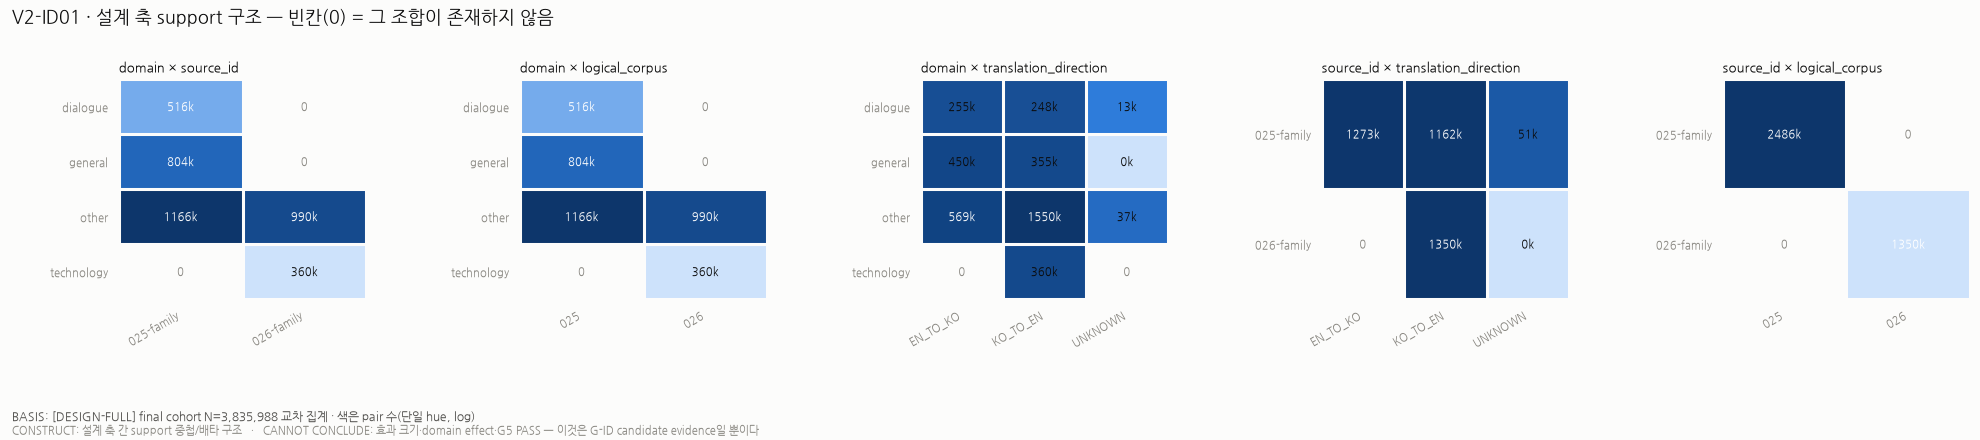

── 축약 라벨 ↔ 원본 source_id 대응 ──


,short,full source_id
0,025-family,025-family@raw-manifest:9a546bc91225e5331d0e8e...
1,026-family,026-family@raw-manifest:9a546bc91225e5331d0e8e...


0.1s   RSS 1.705 GiB


In [18]:
# /**
#  * @cell V2-ID01 — 설계 축 support 구조를 zero-cell이 보이는 형태로 시각화한다.
#  * @question 어떤 조합이 아예 관측되지 않는가(= 대비를 만들 수 없는가)?
#  * @ssot §20.2
#  * @input XTABS
#  * @population_or_sample [DESIGN-FULL] 전수
#  * @method 정규화하지 않은 count를 sequential 단일 hue로, 0 cell은 표면색으로 비워 표시
#  * @output F: V2-ID01
#  * @claim_boundary support 구조는 설계 사실이며 효과 추정치가 아니다.
#  * @v1_link V1은 domain x logical_corpus만 보았다. 여기서는 source_id/direction까지 포함한다.
#  */

_t0 = time.time()


def _short(v) -> str:
    """
    /**
     * @purpose 축 라벨을 읽을 수 있는 길이로 줄인다. source_id는 70자 provenance 문자열이라
     *          그대로 두면 panel을 가로질러 다른 그림을 덮는다.
     * @return '025-family' 처럼 앞쪽 식별 부분만 남긴 문자열
     */
    """
    t = str(v)
    # @line '@' 앞이 논리적 식별자다. 뒤는 raw-manifest 해시라 축에서 정보를 주지 않는다.
    return t.split("@")[0] if "@" in t else (t if len(t) <= 14 else t[:12] + "…")


_keys = list(XTABS)
fig, axes = plt.subplots(1, len(_keys), figsize=(3.6 * len(_keys), 4.0))
axes = np.atleast_1d(axes)
for _ax, _k in zip(axes, _keys):
    _t = XTABS[_k]
    _v = _t.to_numpy().astype(float)
    # @line 0은 마스킹해 표면색으로 남긴다 — '관측 없음'은 '작은 값'과 다른 범주이기 때문이다.
    _mask = np.ma.masked_where(_v == 0, _v)
    _im = _ax.imshow(_mask, cmap=SEQ_BLUE, aspect="auto",
                     norm=matplotlib.colors.LogNorm(vmin=max(_v[_v > 0].min(), 1), vmax=_v.max()))
    _ax.set_xticks(range(_t.shape[1]))
    _ax.set_xticklabels([_short(c) for c in _t.columns], fontsize=7.5, rotation=30, ha="right")
    _ax.set_yticks(range(_t.shape[0]))
    _ax.set_yticklabels([_short(i) for i in _t.index], fontsize=7.5)
    for _i in range(_t.shape[0]):
        for _j in range(_t.shape[1]):
            _n = int(_v[_i, _j])
            # @line 0 cell에 명시적으로 0을 적어야 '빈칸'이 데이터 누락처럼 보이지 않는다.
            _ax.text(_j, _i, "0" if _n == 0 else f"{_n/1000:.0f}k", ha="center", va="center",
                     fontsize=7.5, color=INK["muted"] if _n == 0
                     else ("#ffffff" if _n > _v.max() * 0.35 else INK["primary"]))
    _ax.set_title(_k, loc="left", fontsize=8.5, color=INK["primary"], pad=5)
    _ax.set_xticks(np.arange(-0.5, _t.shape[1], 1), minor=True)
    _ax.set_yticks(np.arange(-0.5, _t.shape[0], 1), minor=True)
    _ax.grid(which="minor", color=INK["surface"], linewidth=2.0); _ax.grid(which="major", visible=False)
    _ax.tick_params(which="minor", length=0)
    for _s in _ax.spines.values(): _s.set_visible(False)
fig.suptitle("V2-ID01 · 설계 축 support 구조 — 빈칸(0) = 그 조합이 존재하지 않음",
             x=0.006, ha="left", fontsize=11.5, color=INK["primary"])
# @line 축약한 라벨의 원본을 잃지 않도록 대응표를 출력으로 남긴다(그림에는 넣지 않는다).
_SRC_KEY = pd.DataFrame({"short": [_short(v) for v in XTABS["domain × source_id"].columns],
                         "full source_id": list(XTABS["domain × source_id"].columns)})
caption(fig, "[DESIGN-FULL] final cohort N=3,835,988 교차 집계 · 색은 pair 수(단일 hue, log)",
        "설계 축 간 support 중첩/배타 구조",
        "효과 크기·domain effect·G5 PASS — 이것은 G-ID candidate evidence일 뿐이다")
# @line 5개 panel + 회전 라벨은 tight_layout이 해결하지 못한다. 여백을 직접 지정한다.
fig.subplots_adjust(left=0.06, right=0.995, top=0.82, bottom=0.32, wspace=0.62)
plt.show()
print("── 축약 라벨 ↔ 원본 source_id 대응 ──")
display(_SRC_KEY)
print(f"{time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")

---

# 11 — `sentence_type` 재확인

## @question
`sentence_type`은 realized cohort에서 실제로 몇 개 수준을 갖는가?

## @ssot
§9.2 층화 변수 (설계상 7개 수준); §18 모형 명세(설계상 $\delta^\top \text{SentenceType}_i$ 포함).

## @claim_boundary
SSOT model specification을 **임의로 수정하지 않는다.** 관측 사실만 기록하고,
표현은 `REALIZED_DESIGN_LIMITATION`을 쓴다. 필요하면 `CHANGE_REQUEST_CANDIDATE`로만 **제안**한다.

In [19]:
# /**
#  * @cell sentence_type의 실현 수준·빈도·엔트로피를 full cohort에서 직접 확인한다.
#  * @question 설계가 가정한 층화 변수가 실제 데이터에서 대비를 만들 수 있는가?
#  * @ssot §9.2; §18
#  * @input PAIR_REGISTRY_v002 ⋈ cohort
#  * @population_or_sample [DESIGN-FULL] 전수
#  * @method GROUP BY + Shannon entropy (log2). 단일 수준이면 엔트로피는 정확히 0이다.
#  * @output SENTENCE_TYPE(DataFrame), SENTENCE_TYPE_STATUS(str)
#  * @claim_boundary SSOT 모형 명세를 수정하지 않는다. 관측 기록 + CHANGE_REQUEST_CANDIDATE 제안까지.
#  * @v1_link V1도 단일 수준을 관측했다. V2는 같은 사실을 canonical cohort에서 재확인한다.
#  */

_t0 = time.time()
SENTENCE_TYPE = _con.execute(f"""
    SELECT sentence_type, count(*) n FROM {_COH} GROUP BY 1 ORDER BY 2 DESC""").df()
SENTENCE_TYPE["share"] = SENTENCE_TYPE.n / SENTENCE_TYPE.n.sum()
display(SENTENCE_TYPE)

_p = SENTENCE_TYPE.share.to_numpy()
# @line 엔트로피 0은 '정보가 없다'의 정량적 표현이다 — 단일 수준이라는 말의 수치적 등가물이다.
_entropy = float(-(_p * np.log2(_p, where=_p > 0)).sum()) if len(_p) > 1 else 0.0
SENTENCE_TYPE_STATUS = "ZERO_VARIANCE" if len(SENTENCE_TYPE) == 1 else "HAS_VARIANCE"
print(f"\nunique levels : {len(SENTENCE_TYPE)}")
print(f"Shannon entropy (log2) : {_entropy:.6f} bits")
print(f"status : {SENTENCE_TYPE_STATUS}")
if SENTENCE_TYPE_STATUS == "ZERO_VARIANCE":
    print("\n  REALIZED_DESIGN_LIMITATION")
    print("  SSOT §9.2는 sentence_type을 7개 수준의 층화 변수로 설계했으나, realized cohort는")
    print(f"  전량({int(SENTENCE_TYPE.n.iloc[0]):,}건)이 '{SENTENCE_TYPE.sentence_type.iloc[0]}' 단일 수준이다.")
    print("  이는 D-01 필드 계약(source 값이 없으면 'other')의 귀결이며 데이터 결함이 아니다.")
    print("  → §18 모형에서 이 항은 어떤 대비도 만들 수 없다.")
    print("\n  CHANGE_REQUEST_CANDIDATE (제안일 뿐, 이 lane에 승인 권한 없음):")
    print("    '§18 모형 명세에서 sentence_type 항의 처리를 Director가 명시적으로 결정할 것'")
    print("    (제거 / 유보 / 원천 재수집 중 무엇인지는 연구 설계 결정이다.)")
print(f"\n{time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")

,sentence_type,n,share
0,other,3835988,1.0



unique levels : 1
Shannon entropy (log2) : 0.000000 bits
status : ZERO_VARIANCE

  REALIZED_DESIGN_LIMITATION
  SSOT §9.2는 sentence_type을 7개 수준의 층화 변수로 설계했으나, realized cohort는
  전량(3,835,988건)이 'other' 단일 수준이다.
  이는 D-01 필드 계약(source 값이 없으면 'other')의 귀결이며 데이터 결함이 아니다.
  → §18 모형에서 이 항은 어떤 대비도 만들 수 없다.

  CHANGE_REQUEST_CANDIDATE (제안일 뿐, 이 lane에 승인 권한 없음):
    '§18 모형 명세에서 sentence_type 항의 처리를 Director가 명시적으로 결정할 것'
    (제거 / 유보 / 원천 재수집 중 무엇인지는 연구 설계 결정이다.)

0.2s   RSS 1.715 GiB


---

# 12 — Collinearity / Deterministic Overlap

## @question
어떤 변수쌍이 **수학적으로 결정론적으로** 묶여 있고, 어떤 쌍이 **경험적으로만** 높은 상관인가?

## @ssot
§21 공선성 및 compositional feature 처리; §32 **T-06 Deterministic feature overlap**;
§20.2 (condition number / VIF).

## @method — 두 종류를 반드시 분리
1. **결정론적 종속성**: §8 항등식 등 정의상 성립하는 관계 → 상관계수로 "발견"할 수 있는 것이 아니다.
2. **경험적 상관**: 정의상 독립이지만 데이터에서 함께 움직이는 관계.

## @claim_boundary
동일 항등식의 구성요소를 모형에 무비판적으로 동시 투입하지 않는다.
VIF/condition number는 **candidate**로만 산출한다 (모형을 적합하지 않는다).

── 결정론적 종속성 (정의에서 도출 — 상관으로 '발견'되는 것이 아니다) ──


,관계,종류,SSOT,모형 함의
0,logTP = logCR + logBDR + logCP,EXACT_IDENTITY,§8,네 변수 중 셋만 자유롭다. 넷을 동시에 넣으면 완전 공선.
1,TP = CR × BDR × CP,EXACT_IDENTITY,§8,위 항등식의 지수 형태.
2,bytes_per_codepoint = utf8_bytes / codepoint_c...,EXACT_DEFINITION,§13.3,세 변수 중 둘만 자유롭다.
3,BDR = (B_KO/C_KO)/(B_EN/C_EN),EXACT_DEFINITION,§8.3,양측 bytes_per_codepoint에서 완전 결정.
4,CR = C_KO / C_EN,EXACT_DEFINITION,§8.2,양측 codepoint_count에서 완전 결정.
5,CP = (T_KO/B_KO)/(T_EN/B_EN),EXACT_DEFINITION,§8.4,token count와 byte에서 완전 결정.
6,morpheme_density = morpheme_count / eojeol_count,EXACT_DEFINITION,§13.6,세 변수 중 둘만 자유롭다.
7,particle/ending/deriv_affix_ratio,COMPOSITIONAL,"§13.7, §21",분모 공유. function_morpheme_ratio = particle + en...
8,hangul/latin/digit/punct/symbol/space share,COMPOSITIONAL,"§12.2, §21",합이 1. 참조 범주를 하나 빼거나 compositional transform 필요.


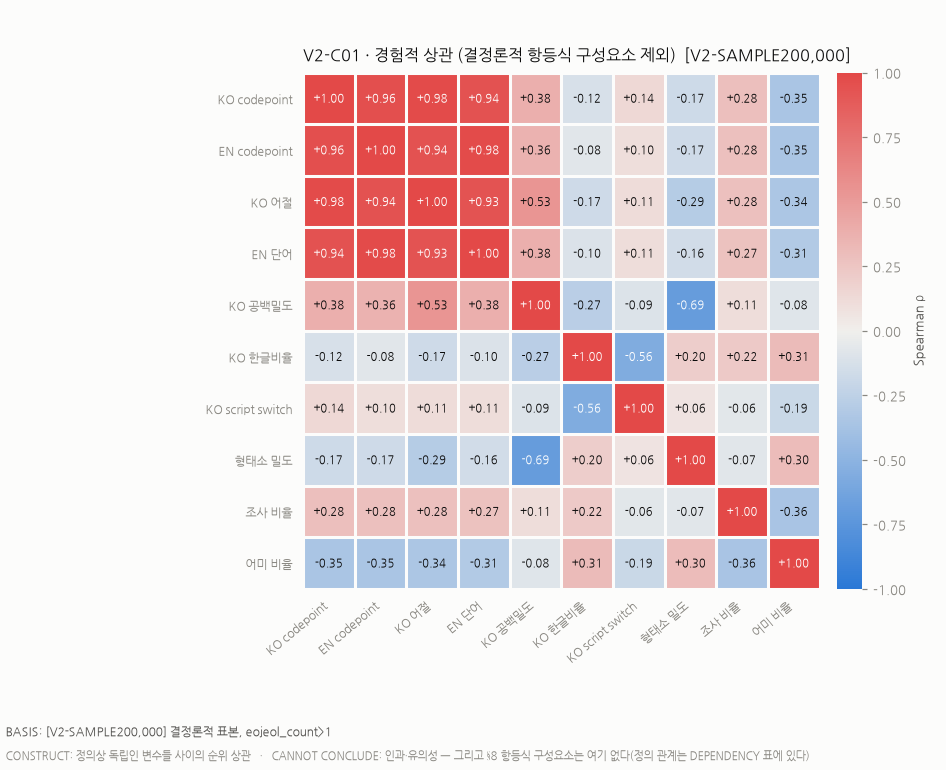


── zero / near-zero variance candidate (IQR 기준) ──


,min,p25,median,p75,max,IQR,zero_IQR
feature,,,,,,,
ko_script_type_count,0.0,1.0,1.0,1.0,3.0000,0.0,True
en_script_type_count,0.0,1.0,1.0,1.0,3.0000,0.0,True
ko_script_switch_count,0.0,0.0,0.0,0.0,34.0000,0.0,True
en_script_switch_count,0.0,0.0,0.0,0.0,42.0000,0.0,True
ko_digit_share,0.0,0.0,0.0,0.0,1.0000,0.0,True
en_digit_share,0.0,0.0,0.0,0.0,1.0000,0.0,True
ko_symbol_other_share,0.0,0.0,0.0,0.0,0.7500,0.0,True
en_symbol_other_share,0.0,0.0,0.0,0.0,0.9091,0.0,True
en_bytes_per_codepoint,1.0,1.0,1.0,1.0,2.5088,0.0,True



  IQR = 0 인 변수: ['ko_script_type_count', 'en_script_type_count', 'ko_script_switch_count', 'en_script_switch_count', 'ko_digit_share', 'en_digit_share', 'ko_symbol_other_share', 'en_symbol_other_share', 'en_bytes_per_codepoint']
  → 이 변수들은 중앙 50%가 상수다. 모형 투입 전 Director/통계 lane의 판단이 필요하다.

3.7s   RSS 1.194 GiB


In [20]:
# /**
#  * @cell 결정론적 종속성 그래프와 경험적 상관 군집을 분리해 산출한다.
#  * @question 무엇이 정의상 묶여 있고 무엇이 데이터에서만 묶여 있는가?
#  * @ssot §21; §32 T-06; §20.2
#  * @input 결정론적 표본 (상관행렬용) + 정의 지식(항등식)
#  * @population_or_sample [V2-SAMPLE200000] 상관 / 정의 관계는 population-invariant
#  * @method 정의 기반 dependency 목록 + Spearman 상관 군집 + zero/near-zero variance 검사
#  * @output DEPENDENCY(DataFrame), EMP_CORR(DataFrame), NZV(DataFrame)
#  * @claim_boundary VIF/condition number는 candidate 산출이며 모형 적합이 아니다.
#  * @v1_link V1도 T-06을 지적했으나 40건이었다. 여기서는 목록을 명시적으로 고정한다.
#  */

_t0 = time.time()
# @line 이 표는 데이터가 아니라 '정의'에서 나온다. 상관계수로 확인할 대상이 아니라 선언할 대상이다.
DEPENDENCY = pd.DataFrame([
    ("logTP = logCR + logBDR + logCP", "EXACT_IDENTITY", "§8",
     "네 변수 중 셋만 자유롭다. 넷을 동시에 넣으면 완전 공선."),
    ("TP = CR × BDR × CP", "EXACT_IDENTITY", "§8", "위 항등식의 지수 형태."),
    ("bytes_per_codepoint = utf8_bytes / codepoint_count", "EXACT_DEFINITION", "§13.3",
     "세 변수 중 둘만 자유롭다."),
    ("BDR = (B_KO/C_KO)/(B_EN/C_EN)", "EXACT_DEFINITION", "§8.3",
     "양측 bytes_per_codepoint에서 완전 결정."),
    ("CR = C_KO / C_EN", "EXACT_DEFINITION", "§8.2", "양측 codepoint_count에서 완전 결정."),
    ("CP = (T_KO/B_KO)/(T_EN/B_EN)", "EXACT_DEFINITION", "§8.4",
     "token count와 byte에서 완전 결정."),
    ("morpheme_density = morpheme_count / eojeol_count", "EXACT_DEFINITION", "§13.6",
     "세 변수 중 둘만 자유롭다."),
    ("particle/ending/deriv_affix_ratio", "COMPOSITIONAL", "§13.7, §21",
     "분모 공유. function_morpheme_ratio = particle + ending 이므로 동시 투입 금지."),
    ("hangul/latin/digit/punct/symbol/space share", "COMPOSITIONAL", "§12.2, §21",
     "합이 1. 참조 범주를 하나 빼거나 compositional transform 필요."),
], columns=["관계", "종류", "SSOT", "모형 함의"])
print("── 결정론적 종속성 (정의에서 도출 — 상관으로 '발견'되는 것이 아니다) ──")
display(DEPENDENCY)

# @line 경험적 상관은 정의 관계를 뺀 나머지에서만 의미가 있다.
_EMPV = [("ko_codepoint_count", "KO codepoint"), ("en_codepoint_count", "EN codepoint"),
         ("ko_eojeol_count", "KO 어절"), ("en_word_count", "EN 단어"),
         ("ko_whitespace_density", "KO 공백밀도"), ("ko_hangul_share", "KO 한글비율"),
         ("ko_script_switch_count", "KO script switch"), ("morpheme_density", "형태소 밀도"),
         ("particle_ratio", "조사 비율"), ("ending_ratio", "어미 비율")]
_E = det_sample(_con, f"""(SELECT r.pair_id, r.ko_codepoint_count, r.en_codepoint_count,
        r.ko_eojeol_count, r.en_word_count, r.ko_whitespace_density, r.ko_hangul_share,
        r.ko_script_switch_count, m.morpheme_density, m.particle_ratio, m.ending_ratio
     FROM {REP} r JOIN {MOR} m ON r.pair_id=m.pair_id WHERE m.eojeol_count > 1)""",
    ["pair_id"] + [c for c, _ in _EMPV], V2_SAMPLE_N)
_M = np.array([[stats.spearmanr(_E[a], _E[b]).statistic for b, _ in _EMPV] for a, _ in _EMPV])
EMP_CORR = pd.DataFrame(_M, index=[l for _, l in _EMPV], columns=[l for _, l in _EMPV])

fig, ax = plt.subplots(figsize=(8.6, 7.0))
_im = ax.imshow(EMP_CORR.to_numpy(), cmap=DIVERGING, norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1))
ax.set_xticks(range(len(_EMPV))); ax.set_xticklabels(EMP_CORR.columns, fontsize=8, rotation=40, ha="right")
ax.set_yticks(range(len(_EMPV))); ax.set_yticklabels(EMP_CORR.index, fontsize=8)
for _i in range(len(_EMPV)):
    for _j in range(len(_EMPV)):
        _v = EMP_CORR.iat[_i, _j]
        ax.text(_j, _i, f"{_v:+.2f}", ha="center", va="center", fontsize=7.5,
                color="#ffffff" if abs(_v) > 0.55 else INK["primary"])
ax.set_xticks(np.arange(-0.5, len(_EMPV), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(_EMPV), 1), minor=True)
ax.grid(which="minor", color=INK["surface"], linewidth=2.0); ax.grid(which="major", visible=False)
ax.tick_params(which="minor", length=0)
for _s in ax.spines.values(): _s.set_visible(False)
_cb = fig.colorbar(_im, ax=ax, fraction=0.035, pad=0.02)
_cb.set_label("Spearman ρ", fontsize=8.5, color=INK["secondary"]); _cb.outline.set_visible(False)
ax.set_title(f"V2-C01 · 경험적 상관 (결정론적 항등식 구성요소 제외)  [V2-SAMPLE{len(_E):,}]",
             loc="left", color=INK["primary"], pad=8)
caption(fig, f"[V2-SAMPLE{len(_E):,}] 결정론적 표본, eojeol_count>1",
        "정의상 독립인 변수들 사이의 순위 상관",
        "인과·유의성 — 그리고 §8 항등식 구성요소는 여기 없다(정의 관계는 DEPENDENCY 표에 있다)")
fig.tight_layout(rect=(0, 0.115, 1, 0.96))
plt.show()

# @line 분산이 0/near-0인 변수는 모형에 넣어도 정보를 주지 못하므로 미리 걸러 목록화한다.
_NZVC = ["ko_script_type_count", "en_script_type_count", "ko_script_switch_count",
         "en_script_switch_count", "ko_digit_share", "en_digit_share",
         "ko_symbol_other_share", "en_symbol_other_share", "en_bytes_per_codepoint"]
_nzv = quantiles(_con, REP, _NZVC)
NZV = _nzv[["min", "p25", "median", "p75", "max", "IQR"]].copy()
NZV["zero_IQR"] = NZV.IQR == 0
print("\n── zero / near-zero variance candidate (IQR 기준) ──")
display(NZV.round(4))
print(f"\n  IQR = 0 인 변수: {NZV.index[NZV.zero_IQR].tolist()}")
print("  → 이 변수들은 중앙 50%가 상수다. 모형 투입 전 Director/통계 lane의 판단이 필요하다.")
print(f"\n{time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")

---

# 13 — Stratified Descriptive Distribution (NOT "domain effect")

## @question
`domain` / `source_id` / `translation_direction` / 길이 층별 $\log TP$ 분포는 어떻게 다른가?

## @ssot
§6.6 RQ6 heterogeneity; §20.2; §32 T-04.

## @claim_boundary — 용어 통제
Gate G-ID 이전에는 **"domain effect"라는 용어를 쓰지 않는다.** 다음만 쓴다:

- **domain-stratified descriptive distribution**
- **observed ordering**
- **support-confounded contrast** — cell 10에서 support가 배타적이라고 판정된 축의 대비

,axis,level,n,p25,median,p75,share_tp_gt1,contrast status
0,domain,dialogue,516162,0.0953,0.2513,0.4055,0.8216,"support-confounded (× source_id, × direction —..."
1,domain,general,804291,0.0800,0.2513,0.4055,0.7737,"support-confounded (× source_id, × direction —..."
2,domain,other,2155630,0.1671,0.2973,0.4308,0.9147,"support-confounded (× source_id, × direction —..."
3,domain,technology,359905,0.2538,0.3463,0.4447,0.9921,"support-confounded (× source_id, × direction —..."
4,source_id,025-family@raw-manifest:9a546bc91225e5331d0e8e...,2485963,0.1178,0.2744,0.4308,0.8336,support-confounded (× domain — cell 10 참조)
5,source_id,026-family@raw-manifest:9a546bc91225e5331d0e8e...,1350025,0.2007,0.3087,0.4199,0.9650,support-confounded (× domain — cell 10 참조)
6,translation_direction,EN_TO_KO,1273289,0.1054,0.2624,0.4055,0.8247,partially confounded (technology는 단일 방향)
7,translation_direction,KO_TO_EN,2512152,0.1719,0.3001,0.4296,0.9078,partially confounded (technology는 단일 방향)
8,translation_direction,UNKNOWN,50547,0.1671,0.3254,0.4855,0.8815,partially confounded (technology는 단일 방향)
9,length_stratum,Q1,840667,0.1054,0.2877,0.4520,0.7878,설계상 직교 (EN codepoint 분위)


/tmp/ipykernel_165542/946826080.py:56: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout(rect=(0, 0.135, 1, 0.92))


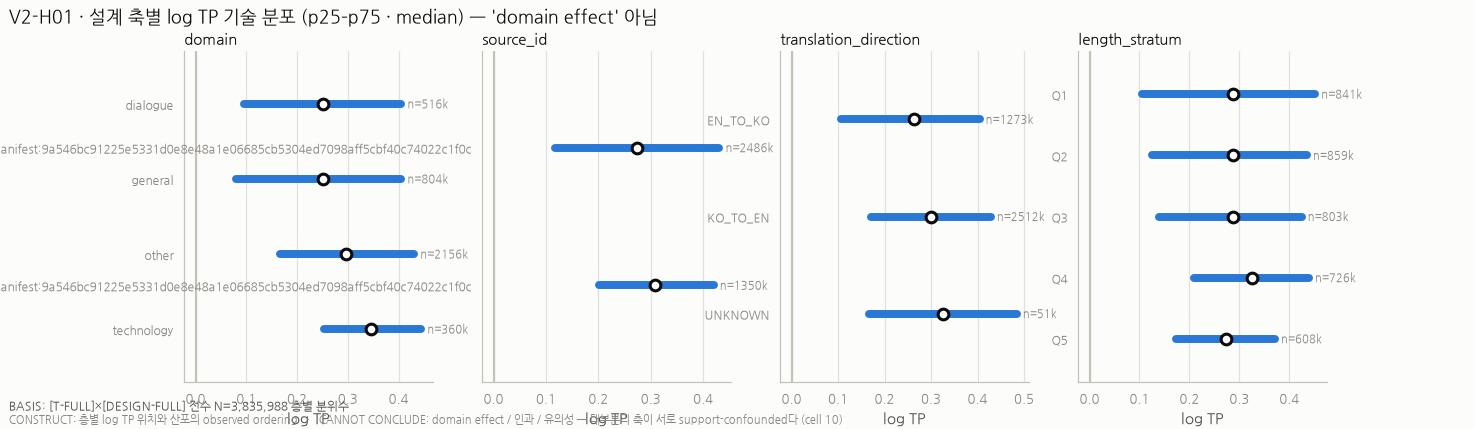

2.6s   RSS 2.227 GiB


In [21]:
# /**
#  * @cell 설계 축별 logTP 분포를 기술하고, support 교락 여부를 각 대비에 명시적으로 붙인다.
#  * @question 층별 분포 차이는 얼마이며, 그 대비는 해석 가능한가?
#  * @ssot §6.6; §20.2; §32 T-04
#  * @input TOK ⋈ cohort metadata
#  * @population_or_sample [T-FULL]×[DESIGN-FULL] 전수
#  * @method 층별 분위수 + cell 10의 provisional 분류를 대비마다 라벨로 부착
#  * @output STRATA(DataFrame)
#  * @claim_boundary 'domain effect' 용어 금지. support-confounded contrast로만 기술한다.
#  * @v1_link V1은 n=10/domain으로 순서만 보았고 유의성을 주장하지 않았다. V2는 전수 분포다.
#  */

_t0 = time.time()
_frames = []
for _ax in ["domain", "source_id", "translation_direction", "length_stratum"]:
    _d = _con.execute(f"""
        SELECT g.{_ax} AS level, count(*) n,
               quantile_cont(t.log_token_premium, 0.25) p25,
               median(t.log_token_premium) median,
               quantile_cont(t.log_token_premium, 0.75) p75,
               avg(CASE WHEN t.token_premium > 1 THEN 1.0 ELSE 0 END) share_tp_gt1
        FROM {TOK} t JOIN {_COH} g ON t.pair_id = g.pair_id
        GROUP BY 1 ORDER BY 1""").df()
    _d.insert(0, "axis", _ax)
    _frames.append(_d)
STRATA = pd.concat(_frames, ignore_index=True)
# @line 각 축이 다른 축과 교락되어 있는지를 표에 직접 붙여야, 표만 잘라 봐도 오독이 안 생긴다.
_conf = {"domain": "support-confounded (× source_id, × direction — cell 10 참조)",
         "source_id": "support-confounded (× domain — cell 10 참조)",
         "translation_direction": "partially confounded (technology는 단일 방향)",
         "length_stratum": "설계상 직교 (EN codepoint 분위)"}
STRATA["contrast status"] = STRATA.axis.map(_conf)
display(STRATA.round(4))

fig, axes = plt.subplots(1, 4, figsize=(13.4, 3.9))
for _ax_i, (_axname, _ax) in enumerate(zip(["domain", "source_id", "translation_direction", "length_stratum"], axes)):
    _d = STRATA[STRATA.axis == _axname].reset_index(drop=True)
    _y = np.arange(len(_d))
    # @line p25–p75를 굵은 선, median을 점으로 — 층별 위치와 산포를 최소 잉크로 보여준다.
    for _yi, _r in _d.iterrows():
        _ax.plot([_r.p25, _r.p75], [_yi, _yi], color=PALETTE["ko"], linewidth=MARK["line_w"] * 2.6, zorder=3)
        _ax.plot([_r["median"]], [_yi], marker="o", markersize=MARK["marker"] + 1,
                 color=INK["surface"], markeredgecolor=INK["primary"], markeredgewidth=2.0, zorder=5)
        _ax.text(_r.p75 + 0.012, _yi, f"n={int(_r.n)/1000:.0f}k", va="center", fontsize=7, color=INK["muted"])
    _ax.axvline(0, color=INK["baseline"], linewidth=MARK["hairline"] * 1.8, zorder=1)
    _ax.set_yticks(_y); _ax.set_yticklabels(_d.level, fontsize=8)
    _ax.set_ylim(-0.7, len(_d) - 0.3); _ax.invert_yaxis()
    _ax.set_xlabel("log TP")
    _ax.set_title(_axname, loc="left", fontsize=9.5, color=INK["primary"], pad=5)
    tidy(_ax, xgrid=True, ygrid=False)
fig.suptitle("V2-H01 · 설계 축별 log TP 기술 분포 (p25–p75 · median) — 'domain effect' 아님",
             x=0.006, ha="left", fontsize=11.5, color=INK["primary"])
caption(fig, "[T-FULL]×[DESIGN-FULL] 전수 N=3,835,988 층별 분위수",
        "층별 log TP 위치와 산포의 observed ordering",
        "domain effect / 인과 / 유의성 — 대부분의 축이 서로 support-confounded다 (cell 10)")
fig.tight_layout(rect=(0, 0.135, 1, 0.92))
plt.show()
print(f"{time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")

---

# 14 — Short-Text / Boundary Region Analysis

## @question
V1에서 보였던 **short-text instability**가 full morphology/token 층에서 어떤 형태로 나타나는가?

## @ssot
§16.3 Extreme-case audit (**극단값 선삭제 금지**); §10.2 soft flags.

## @claim_boundary
**QC exclusion을 생성하지 않는다.** 구역을 라벨링하고 그 구역의 분포를 보고할 뿐이다.

In [22]:
# /**
#  * @cell 경계 구역을 정의하고 각 구역의 크기·premium 분포를 full population에서 산출한다.
#  * @question 짧은 텍스트/혼합 스크립트/극단 비율 구역에서 측정량이 어떻게 달라지는가?
#  * @ssot §16.3; §10.2
#  * @input REP ⋈ MOR ⋈ TOK
#  * @population_or_sample 전수. 각 구역은 조건식으로 정의한 subpopulation이다.
#  * @method 구역별 count / share / logTP·logCP 분위수
#  * @output BOUNDARY(DataFrame)
#  * @claim_boundary QC exclusion 아님. 구역은 관측 라벨이지 배제 규칙이 아니다.
#  * @v1_link V1 AXIS5가 [R-FULL]만으로 제안한 구역에, 이제 morphology/token 층을 붙인다.
#  */

_t0 = time.time()
# @line 각 구역을 SQL 조건으로 명시해 두면 NB06/NB07이 같은 정의를 그대로 재사용할 수 있다.
_REGIONS = [
    ("Q1 최단 (KO codepoint <= p05)", "r.ko_codepoint_count <= 11"),
    ("eojeol_count = 1 (측정 경계)", "m.eojeol_count = 1"),
    ("혼합 스크립트 (KO 한글비율 < 0.5)", "r.ko_hangul_share < 0.5"),
    ("script switch 상위 (KO >= p99)", "r.ko_script_switch_count >= 6"),
    ("grapheme != codepoint (KO)", "r.ko_grapheme_count <> r.ko_codepoint_count"),
    ("EN 비ASCII 포함", "r.en_bytes_per_codepoint > 1.0"),
    ("TP 상위 극단 (>= p99)", "t.token_premium >= 2.25"),
    ("TP 하위 극단 (<= p01)", "t.token_premium <= 0.75"),
    ("CP 상위 극단 (>= p99)", "t.log_compression_penalty >= 0.5549"),
    ("CP 하위 극단 (<= p01)", "t.log_compression_penalty <= -0.3254"),
    ("KO codepoint > EN (역방향)", "r.pair_codepoint_diff > 0"),
]
_J = f"{REP} r JOIN {MOR} m ON r.pair_id=m.pair_id JOIN {TOK} t ON r.pair_id=t.pair_id"
_rows = []
for _lab, _cond in _REGIONS:
    _d = _con.execute(f"""
        SELECT count(*) n, median(t.log_token_premium) logTP_med,
               median(t.log_compression_penalty) logCP_med,
               median(m.morpheme_density) mdens_med,
               avg(CASE WHEN t.token_premium > 1 THEN 1.0 ELSE 0 END) share_gt1
        FROM {_J} WHERE {_cond}""").df().iloc[0]
    _rows.append({"region": _lab, "condition": _cond, "n": int(_d.n),
                  "share": _d.n / CANONICAL_COHORT_N, "logTP_med": _d.logTP_med,
                  "logCP_med": _d.logCP_med, "morph_density_med": _d.mdens_med,
                  "share_TP>1": _d.share_gt1})
BOUNDARY = pd.DataFrame(_rows)
# @line 모집단 기준선을 같은 표에 넣어야 각 구역이 '얼마나 다른지'를 바로 읽을 수 있다.
BOUNDARY["Δ logTP vs cohort"] = BOUNDARY.logTP_med - float(DEC_Q.loc["log_token_premium", "median"])
display(BOUNDARY.drop(columns="condition").round(4))
print("\n[§16.3] 위 구역 중 어느 것도 제외 대상이 아니다. 이 표는 라벨링이지 QC 규칙이 아니다.")
print(f"{time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")

,region,n,share,logTP_med,logCP_med,morph_density_med,share_TP>1,Δ logTP vs cohort
0,Q1 최단 (KO codepoint <= p05),198398,0.0517,0.1335,0.1699,2.6667,0.5504,-0.1542
1,eojeol_count = 1 (측정 경계),42096,0.0110,0.0000,0.1823,4.0000,0.4940,-0.2877
2,혼합 스크립트 (KO 한글비율 < 0.5),59173,0.0154,0.1542,0.1292,2.4286,0.6476,-0.1335
3,script switch 상위 (KO >= p99),43009,0.0112,0.2719,0.2332,2.3158,0.9530,-0.0157
4,grapheme != codepoint (KO),29,0.0000,0.3075,0.2881,2.2000,0.9655,0.0198
5,EN 비ASCII 포함,21885,0.0057,0.2877,0.2412,2.1905,0.9330,0.0000
6,TP 상위 극단 (>= p99),40849,0.0106,0.8755,0.3307,2.2857,1.0000,0.5878
7,TP 하위 극단 (<= p01),43579,0.0114,-0.3567,-0.0682,2.5000,0.0000,-0.6444
8,CP 상위 극단 (>= p99),38369,0.0100,0.5108,0.6059,2.3333,0.9128,0.2231
9,CP 하위 극단 (<= p01),38655,0.0101,0.0000,-0.3892,2.4000,0.4206,-0.2877



[§16.3] 위 구역 중 어느 것도 제외 대상이 아니다. 이 표는 라벨링이지 QC 규칙이 아니다.
2.0s   RSS 1.406 GiB


,bucket,n,ec_min,tp_p05,tp_p25,tp_med,tp_p75,tp_p95,cp_med,md_med,md_p05,md_p95
0,1,42096,1,-0.4520,0.0000,0.0000,0.2877,0.6931,0.1823,4.0000,2.0000,6.0000
1,2,108371,2,-0.3567,0.0000,0.1542,0.3365,0.6931,0.1542,3.0000,2.0000,4.5000
2,3,182918,3,-0.2877,0.0000,0.1335,0.3365,0.6061,0.1178,2.6667,2.0000,3.6667
3,4,267660,4,-0.2007,0.0000,0.2007,0.3677,0.6190,0.0953,2.5000,1.7500,3.2500
4,5,333525,5,-0.1335,0.0953,0.2513,0.4055,0.6419,0.0892,2.4000,1.8000,3.0000
5,6-8,892336,6,-0.0741,0.1431,0.2877,0.4418,0.6931,0.0951,2.1667,1.7500,2.8333
6,9-12,677851,9,0.0000,0.1823,0.3137,0.4520,0.6539,0.1484,2.1667,1.7500,2.6667
7,13-20,879021,13,0.0445,0.2059,0.3185,0.4308,0.6061,0.2489,2.1579,1.7692,2.7000
8,21+,452210,21,0.0710,0.2136,0.3145,0.4220,0.6035,0.2654,2.1304,1.7692,2.5652


findfont: Failed to find font weight bold, now using 600.


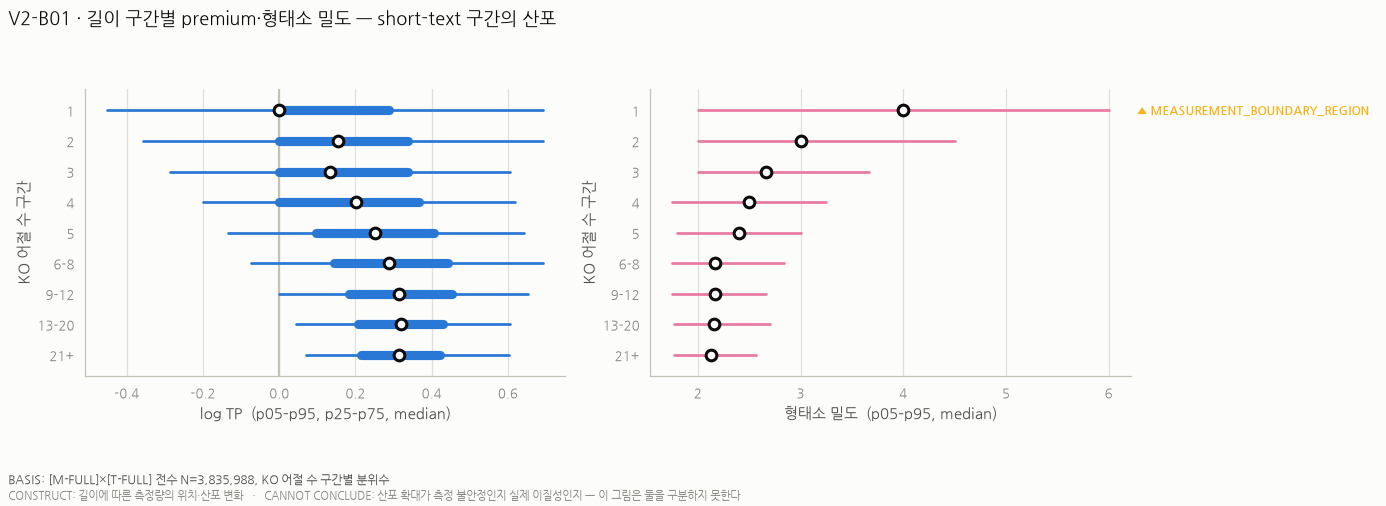

0.5s   RSS 1.825 GiB


In [23]:
# /**
#  * @cell V2-B01 — 길이 층 안에서 premium과 형태소 밀도가 어떻게 움직이는지 본다(short-text instability).
#  * @question 짧은 구간에서 분포가 넓어지는가, 위치가 이동하는가, 둘 다인가?
#  * @ssot §16.3; §13.6
#  * @input REP ⋈ MOR ⋈ TOK
#  * @population_or_sample 전수. KO 어절 수 구간별 집계.
#  * @method eojeol_count 구간(1,2,3,4,5,6-8,9-12,13-20,21+)별 분위수
#  * @output LENGTH_BINS(DataFrame), F: V2-B01
#  * @claim_boundary 산포 확대는 측정 불안정과 실제 이질성을 구분하지 못한다. 둘 다 가능하다.
#  * @v1_link V1 caveat C5(짧은 조각에서 형태소 값 불안정)를 full population에서 처음 확인한다.
#  */

_t0 = time.time()
LENGTH_BINS = _con.execute(f"""
    WITH j AS (
      SELECT m.eojeol_count ec,
             CASE WHEN m.eojeol_count >= 21 THEN '21+'
                  WHEN m.eojeol_count >= 13 THEN '13-20'
                  WHEN m.eojeol_count >= 9  THEN '9-12'
                  WHEN m.eojeol_count >= 6  THEN '6-8'
                  ELSE m.eojeol_count::VARCHAR END AS bucket,
             t.log_token_premium ltp, t.log_compression_penalty lcp, m.morpheme_density md
      FROM {MOR} m JOIN {TOK} t ON m.pair_id=t.pair_id)
    SELECT bucket, count(*) n, min(ec) ec_min,
           quantile_cont(ltp,0.05) tp_p05, quantile_cont(ltp,0.25) tp_p25,
           median(ltp) tp_med, quantile_cont(ltp,0.75) tp_p75, quantile_cont(ltp,0.95) tp_p95,
           median(lcp) cp_med, median(md) md_med,
           quantile_cont(md,0.05) md_p05, quantile_cont(md,0.95) md_p95
    FROM j GROUP BY 1 ORDER BY ec_min""").df()
display(LENGTH_BINS.round(4))

fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.6, 4.6))
_y = np.arange(len(LENGTH_BINS))
for _yi, _r in LENGTH_BINS.iterrows():
    # @line p05-p95(가는 선)와 p25-p75(굵은 선)를 겹쳐 그리면 '산포가 넓어지는' 구간이 바로 보인다.
    axA.plot([_r.tp_p05, _r.tp_p95], [_yi, _yi], color=PALETTE["ko"], linewidth=MARK["line_w"] * 0.9, zorder=3)
    axA.plot([_r.tp_p25, _r.tp_p75], [_yi, _yi], color=PALETTE["ko"], linewidth=MARK["line_w"] * 3.0, zorder=4)
    axA.plot([_r.tp_med], [_yi], marker="o", markersize=MARK["marker"] + 1, color=INK["surface"],
             markeredgecolor=INK["primary"], markeredgewidth=2.0, zorder=5)
    axB.plot([_r.md_p05, _r.md_p95], [_yi, _yi], color=PALETTE["morph_particle"],
             linewidth=MARK["line_w"] * 0.9, zorder=3)
    axB.plot([_r.md_med], [_yi], marker="o", markersize=MARK["marker"] + 1, color=INK["surface"],
             markeredgecolor=INK["primary"], markeredgewidth=2.0, zorder=5)
for _ax, _lab in ((axA, "log TP  (p05–p95, p25–p75, median)"), (axB, "형태소 밀도  (p05–p95, median)")):
    _ax.set_yticks(_y); _ax.set_yticklabels(LENGTH_BINS.bucket, fontsize=8.5)
    _ax.set_ylim(-0.7, len(LENGTH_BINS) - 0.3); _ax.invert_yaxis()
    _ax.set_xlabel(_lab); _ax.set_ylabel("KO 어절 수 구간")
    tidy(_ax, xgrid=True, ygrid=False)
axA.axvline(0, color=INK["baseline"], linewidth=MARK["hairline"] * 1.8, zorder=1)
# @line 경계 구역(어절 1개) 행을 status 색으로 표시하되 반드시 라벨과 함께 쓴다.
axB.text(axB.get_xlim()[1], 0, "  ▲ MEASUREMENT_BOUNDARY_REGION", va="center",
         fontsize=8, color=STATUS["warning"], fontweight="bold")
fig.suptitle("V2-B01 · 길이 구간별 premium·형태소 밀도 — short-text 구간의 산포",
             x=0.006, ha="left", fontsize=11.5, color=INK["primary"])
caption(fig, "[M-FULL]×[T-FULL] 전수 N=3,835,988, KO 어절 수 구간별 분위수",
        "길이에 따른 측정량의 위치·산포 변화",
        "산포 확대가 측정 불안정인지 실제 이질성인지 — 이 그림은 둘을 구분하지 못한다")
fig.tight_layout(rect=(0, 0.135, 1, 0.925))
plt.show()
print(f"{time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")

---

# 15 — NB06 Target Strata Candidates

## @question
NB06(regex chunk audit)이 **어느 구역을 표본으로 삼아야** 가장 정보량이 높은가?

## @ssot
§12.5 D-05 Regex Chunk Measurement; §5.1 (형태소 ≠ regex chunk ≠ 최종 token); §6.5 RQ5.

## @claim_boundary
**regex chunking 자체를 실행하지 않는다.** 이 표는 **sample-selection aid**이며
**D-05 evidence가 아니다.** NB06이 실행되기 전까지 morpheme–chunk–token 경계 비교는 불가능하다.

In [24]:
# /**
#  * @cell NB06이 소비할 target strata 후보를 data-driven하게 정의하고 크기를 산출한다.
#  * @question 어떤 구역이 regex chunk 층에서 가장 많은 정보를 줄 것인가?
#  * @ssot §12.5 D-05; §6.5 RQ5; §5.1
#  * @input BOUNDARY 구역 정의 + 전수 집계
#  * @population_or_sample 전수에서 구역 크기 산출
#  * @method 각 후보 구역의 N, cohort 대비 share, 대표 metric 중앙값
#  * @output NB06_TARGET_STRATA_CANDIDATE(DataFrame)
#  * @claim_boundary sample-selection aid. D-05 evidence 아님. regex chunk를 실행하지 않았다.
#  * @v1_link V1이 [R-FULL]만으로 제안한 구역을, morphology/token 층 관측으로 우선순위화한다.
#  */

_t0 = time.time()
# @line 우선순위는 '얼마나 다른가'(Δ) 와 '얼마나 있는가'(N) 둘 다로 정한다 — 희귀하고 평범하면 표본 가치가 낮다.
NB06_TARGET_STRATA_CANDIDATE = BOUNDARY.copy()
NB06_TARGET_STRATA_CANDIDATE["abs_Δ_logTP"] = NB06_TARGET_STRATA_CANDIDATE["Δ logTP vs cohort"].abs()
NB06_TARGET_STRATA_CANDIDATE["rationale"] = [
    "regex chunk가 짧은 문자열에서 어떻게 분할되는지 — chunk/token 비가 가장 불안정할 구간",
    "어절 1개 = 공백 기반 chunk 경계가 존재하지 않는 구간. chunk 정의 자체가 시험된다",
    "Hangul/Latin 혼합에서 Unicode category 기반 chunk 경계가 어디서 끊기는지",
    "script 전환이 많을수록 regex chunk 수가 늘어날 것으로 예상되는 구간 (RQ5 직접 대상)",
    "grapheme != codepoint = 결합문자 존재. chunk와 token이 결합문자를 어떻게 다루는지",
    "EN side 비ASCII. Latin 전제가 깨지는 구간",
    "TP 상위 극단 — chunk fragmentation이 최대일 것으로 예상",
    "TP 하위 극단 — KO가 오히려 적은 token을 쓰는 구조가 무엇인지",
    "CP 상위 극단 — byte 정규화 후에도 남는 tokenizer 비대칭이 최대인 구간",
    "CP 하위 극단 — tokenizer가 KO를 더 잘 압축하는 구조",
    "KO가 EN보다 code point가 긴 희귀 방향 — 표현층 가정이 뒤집히는 구간",
]
_out = NB06_TARGET_STRATA_CANDIDATE.sort_values("abs_Δ_logTP", ascending=False)[
    ["region", "n", "share", "logTP_med", "logCP_med", "abs_Δ_logTP", "condition", "rationale"]]
display(_out.round(4).reset_index(drop=True))
print("\n[claim boundary] NB06_TARGET_STRATA_CANDIDATE")
print("  · regex chunking을 실행하지 않았다. 이 표는 sample-selection aid다.")
print("  · D-05 evidence가 아니며, morpheme–chunk–token 경계 비교는 NB06 이후에만 가능하다 (§5.1).")
print(f"{time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")

,region,n,share,logTP_med,logCP_med,abs_Δ_logTP,condition,rationale
0,TP 하위 극단 (<= p01),43579,0.0114,-0.3567,-0.0682,0.6444,t.token_premium <= 0.75,TP 하위 극단 — KO가 오히려 적은 token을 쓰는 구조가 무엇인지
1,TP 상위 극단 (>= p99),40849,0.0106,0.8755,0.3307,0.5878,t.token_premium >= 2.25,TP 상위 극단 — chunk fragmentation이 최대일 것으로 예상
2,KO codepoint > EN (역방향),7414,0.0019,0.8267,-0.1823,0.5390,r.pair_codepoint_diff > 0,KO가 EN보다 code point가 긴 희귀 방향 — 표현층 가정이 뒤집히는 구간
3,eojeol_count = 1 (측정 경계),42096,0.0110,0.0000,0.1823,0.2877,m.eojeol_count = 1,어절 1개 = 공백 기반 chunk 경계가 존재하지 않는 구간. chunk 정의 자...
4,CP 하위 극단 (<= p01),38655,0.0101,0.0000,-0.3892,0.2877,t.log_compression_penalty <= -0.3254,CP 하위 극단 — tokenizer가 KO를 더 잘 압축하는 구조
5,CP 상위 극단 (>= p99),38369,0.0100,0.5108,0.6059,0.2231,t.log_compression_penalty >= 0.5549,CP 상위 극단 — byte 정규화 후에도 남는 tokenizer 비대칭이 최대인 구간
6,Q1 최단 (KO codepoint <= p05),198398,0.0517,0.1335,0.1699,0.1542,r.ko_codepoint_count <= 11,regex chunk가 짧은 문자열에서 어떻게 분할되는지 — chunk/token ...
7,혼합 스크립트 (KO 한글비율 < 0.5),59173,0.0154,0.1542,0.1292,0.1335,r.ko_hangul_share < 0.5,Hangul/Latin 혼합에서 Unicode category 기반 chunk 경계...
8,grapheme != codepoint (KO),29,0.0000,0.3075,0.2881,0.0198,r.ko_grapheme_count <> r.ko_codepoint_count,grapheme != codepoint = 결합문자 존재. chunk와 token이...
9,script switch 상위 (KO >= p99),43009,0.0112,0.2719,0.2332,0.0157,r.ko_script_switch_count >= 6,script 전환이 많을수록 regex chunk 수가 늘어날 것으로 예상되는 구간...



[claim boundary] NB06_TARGET_STRATA_CANDIDATE
  · regex chunking을 실행하지 않았다. 이 표는 sample-selection aid다.
  · D-05 evidence가 아니며, morpheme–chunk–token 경계 비교는 NB06 이후에만 가능하다 (§5.1).
0.0s   RSS 1.826 GiB


---

# 16 — Analysis Cohort Diagnostic

## @question
현재 canonical N = 3,835,988이 **primary analysis cohort candidate**로서 건전한가?

## @ssot
§23 데이터 분할; §31 G5 Analysis Readiness (analysis cohort freeze); D-RD-08 (fixed cap = null).

## @claim_boundary
- **극단값만으로 row를 제외하지 않는다** (§16.3).
- **primary cohort를 변경하지 않는다.** sensitivity subset은 **제안**만 한다.

In [25]:
# /**
#  * @cell 결과변수·핵심 공변량의 결측/비유한 여부와 support를 점검한다.
#  * @question cohort 안에 모형이 소비할 수 없는 행이 있는가?
#  * @ssot §23; §31 G5; D-RD-08
#  * @input REP ⋈ MOR ⋈ TOK
#  * @population_or_sample 전수
#  * @method NULL / NaN / Inf / 정의역 위반 카운트 + sensitivity subset 크기 산출
#  * @output COHORT_DIAG(DataFrame), SENSITIVITY(DataFrame)
#  * @claim_boundary primary cohort 변경 금지. subset은 제안일 뿐이다.
#  * @v1_link V1은 40건 rubric이었다. 여기서는 전수 무결성 점검이다.
#  */

_t0 = time.time()
_CHECKS = [
    ("logTP NULL", "t.log_token_premium IS NULL"),
    ("logTP 비유한", "NOT isfinite(t.log_token_premium)"),
    ("logCP 비유한", "NOT isfinite(t.log_compression_penalty)"),
    ("token count <= 0", "t.ko_token_count <= 0 OR t.en_token_count <= 0"),
    ("roundtrip 실패", "NOT t.roundtrip_ok"),
    ("identity 오차 >= 1e-10", "t.identity_abs_error >= 1e-10"),
    ("morpheme_density NULL", "m.morpheme_density IS NULL"),
    ("eojeol_count <= 0", "m.eojeol_count <= 0"),
    ("analyzer warning", "m.analysis_warning_flag"),
    ("codepoint <= 0", "r.ko_codepoint_count <= 0 OR r.en_codepoint_count <= 0"),
    ("domain NULL", "g.domain IS NULL"),
    ("source_id NULL", "g.source_id IS NULL"),
    ("direction UNKNOWN", "g.translation_direction = 'UNKNOWN'"),
    ("length_stratum NULL", "g.length_stratum IS NULL"),
]
_JJ = f"{REP} r JOIN {MOR} m ON r.pair_id=m.pair_id JOIN {TOK} t ON r.pair_id=t.pair_id JOIN {_COH} g ON r.pair_id=g.pair_id"
_sel = ", ".join(f"sum(CASE WHEN {c} THEN 1 ELSE 0 END) AS c{i}" for i, (_, c) in enumerate(_CHECKS))
_res = _con.execute(f"SELECT count(*) total, {_sel} FROM {_JJ}").df().iloc[0]
COHORT_DIAG = pd.DataFrame([{"check": lab, "n": int(_res[f"c{i}"]),
                             "share": int(_res[f"c{i}"]) / int(_res.total)}
                            for i, (lab, _) in enumerate(_CHECKS)])
print(f"4-way join 총 행수: {int(_res.total):,}  (= canonical cohort N 이어야 한다)")
assert int(_res.total) == CANONICAL_COHORT_N, "STOP: join 결과가 canonical N과 다르다"
display(COHORT_DIAG.assign(share=lambda d: (d.share * 100).round(4)).rename(columns={"share": "share_%"}))

_blocking = COHORT_DIAG[(COHORT_DIAG.n > 0) & (COHORT_DIAG.check.isin(
    ["logTP NULL", "logTP 비유한", "logCP 비유한", "token count <= 0", "roundtrip 실패",
     "identity 오차 >= 1e-10", "morpheme_density NULL", "eojeol_count <= 0", "codepoint <= 0"]))]
print(f"\n모형 소비 차단 요인: {'없음' if _blocking.empty else _blocking.check.tolist()}")

# @line sensitivity subset은 '제안'이므로 크기만 계산하고 어떤 것도 적용하지 않는다.
_SENS = [("known-direction only", "g.translation_direction <> 'UNKNOWN'"),
         ("eojeol_count > 1", "m.eojeol_count > 1"),
         ("short-text 제외 (KO codepoint > p05)", "r.ko_codepoint_count > 11"),
         ("두 corpus 모두 있는 domain만 (other)", "g.domain = 'other'"),
         ("length Q2–Q4", "g.length_stratum IN ('Q2','Q3','Q4')")]
_rows = []
for _lab, _c in _SENS:
    _n = _con.execute(f"SELECT count(*) FROM {_JJ} WHERE {_c}").fetchone()[0]
    _rows.append({"sensitivity subset": _lab, "condition": _c, "n": _n,
                  "share of cohort": _n / CANONICAL_COHORT_N})
SENSITIVITY = pd.DataFrame(_rows)
print("\n── sensitivity subset 후보 (제안일 뿐, 적용하지 않았다) ──")
display(SENSITIVITY.round(4))
print("\n[§16.3 / D-RD-08] primary cohort는 변경하지 않는다. 극단값만으로 어떤 행도 제외하지 않았다.")
print(f"{time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")

4-way join 총 행수: 3,835,988  (= canonical cohort N 이어야 한다)


,check,n,share_%
0,logTP NULL,0,0.0000
1,logTP 비유한,0,0.0000
2,logCP 비유한,0,0.0000
3,token count <= 0,0,0.0000
4,roundtrip 실패,0,0.0000
5,identity 오차 >= 1e-10,0,0.0000
6,morpheme_density NULL,0,0.0000
7,eojeol_count <= 0,0,0.0000
8,analyzer warning,0,0.0000
9,codepoint <= 0,0,0.0000



모형 소비 차단 요인: 없음



── sensitivity subset 후보 (제안일 뿐, 적용하지 않았다) ──


,sensitivity subset,condition,n,share of cohort
0,known-direction only,g.translation_direction <> 'UNKNOWN',3785441,0.9868
1,eojeol_count > 1,m.eojeol_count > 1,3793892,0.9890
2,short-text 제외 (KO codepoint > p05),r.ko_codepoint_count > 11,3637590,0.9483
3,두 corpus 모두 있는 domain만 (other),g.domain = 'other',2155630,0.5619
4,length Q2–Q4,"g.length_stratum IN ('Q2','Q3','Q4')",2387120,0.6223



[§16.3 / D-RD-08] primary cohort는 변경하지 않는다. 극단값만으로 어떤 행도 제외하지 않았다.
4.5s   RSS 3.25 GiB


---

# 17 — Split Manifest Preview (freeze 하지 않음)

## @question
G5의 split freeze를 위해 **어떤 group key**가 필요한가?

## @ssot
§23.2 예측모형 분할; **LR-01 Leakage Rule** (같은 원문에서 파생된 duplicate/paraphrase cluster가
train/test 양쪽에 들어가면 안 된다); §30.3 Seed policy.

## @claim_boundary
**이번 EDA에서 split을 freeze하지 않는다.** 현재 frozen seed(`D-RD-01 split_seed = 1456095166`)만
참조하고, group key 후보의 구조만 기술한다.

주의해서 읽어야 하는 결과가 하나 있다: `duplicate_group_id`의 group 수가 cohort 행수와 같다면
그것은 "중복이 없어 안전하다"가 **아니라** "이 열로는 group을 만들 수 없다"는 뜻이다.
아래 cell이 그 경우를 명시적으로 구분해 보고한다.

In [26]:
# /**
#  * @cell LR-01을 만족하는 group key 후보의 구조를 기술한다(분할을 만들지 않는다).
#  * @question duplicate cluster를 group으로 묶으면 몇 개의 group이 생기고 크기 분포는 어떤가?
#  * @ssot §23.2 LR-01; §30.3
#  * @input PAIR_REGISTRY_v002 ⋈ cohort (duplicate_group_id)
#  * @population_or_sample 전수
#  * @method group 수 / 최대 크기 / 단일 원소 group 비율
#  * @output SPLIT_PREVIEW(dict)
#  * @claim_boundary split을 freeze하지 않는다. seed도 새로 만들지 않는다.
#  * @v1_link V1에는 이 진단이 없었다.
#  */

_t0 = time.time()
SPLIT_PREVIEW = _con.execute(f"""
    WITH g AS (SELECT duplicate_group_id, count(*) n FROM {_COH} GROUP BY 1)
    SELECT count(*) n_groups, sum(n) n_rows, max(n) max_group,
           sum(CASE WHEN n = 1 THEN 1 ELSE 0 END) singleton_groups,
           quantile_cont(n, 0.99) p99_group_size
    FROM g""").df().iloc[0].to_dict()
_ng, _nr = int(SPLIT_PREVIEW["n_groups"]), int(SPLIT_PREVIEW["n_rows"])
print("── LR-01 group key 후보: duplicate_group_id ──")
print(f"  group 수            : {_ng:,}")
print(f"  cohort 행수         : {_nr:,}")
print(f"  최대 group 크기     : {int(SPLIT_PREVIEW['max_group']):,}")
print(f"  단일 원소 group     : {int(SPLIT_PREVIEW['singleton_groups']):,}  "
      f"({SPLIT_PREVIEW['singleton_groups']/_ng:.2%})")
print(f"  group 크기 p99      : {SPLIT_PREVIEW['p99_group_size']:.0f}")
_all_singleton = int(SPLIT_PREVIEW["singleton_groups"]) == _ng and int(SPLIT_PREVIEW["max_group"]) == 1
SPLIT_PREVIEW["duplicate_group_id_provides_grouping"] = not _all_singleton
if _all_singleton:
    # @line 이 결과는 '문제 없음'이 아니라 '이 열로는 group을 만들 수 없음'을 뜻한다. 반대로 읽기 쉬워 명시한다.
    print("\n  ** duplicate_group_id 는 이 cohort에서 grouping을 제공하지 않는다. **")
    print(f"     group 수({_ng:,}) = cohort 행수({_nr:,}) 이고 최대 group 크기가 1이다.")
    print("     이유: final cohort가 이미 analysis_eligible_exact_dedup(정확 중복 대표 1건)으로")
    print("           구성되어 있어, 중복 그룹당 한 행만 남았다. 즉 GroupKFold(duplicate_group_id)는")
    print("           pair-level 무작위 분할과 완전히 동일하며 LR-01을 실질적으로 만족시키지 못한다.")
    print("\n  LR-01이 요구하는 것은 exact duplicate가 아니라 **near-duplicate / paraphrase cluster**다")
    print("  (§23.2: '같은 원문에서 파생된 paraphrase/duplicate cluster가 train/test 양쪽에 들어가지")
    print("   않도록 text hash 및 near-duplicate cluster를 group key로 활용한다').")
    print("  현재 canonical artifact에는 near-duplicate cluster 열이 존재하지 않는다.")
    print("\n  BLOCKER_FOR_G5_SPLIT_FREEZE:")
    print("    near-duplicate cluster key가 없으면 LR-01을 만족하는 split을 freeze할 수 없다.")
    print("    후보 경로(제안일 뿐): (a) ko/en analysis text의 near-duplicate clustering을 D-01/D-02")
    print("    lineage에 추가, (b) 025의 cross-direction 재사용(50,511 groups)과 TRAIN↔VALID 중복")
    print("    (25,247 pairs)을 group key로 승격, (c) source-held-out을 secondary OOD test로 분리.")
    print("    어느 것을 택할지는 연구 설계 결정이며 이 lane의 권한이 아니다.")
else:
    print(f"\n  → group 수 {_ng:,}, 최대 group 크기 {int(SPLIT_PREVIEW['max_group']):,}")
    print("     GroupKFold/holdout의 group key로 사용 가능하다.")
print("\n[claim boundary] split을 freeze하지 않았다. seed는 D-RD-01 split_seed=1456095166이 이미 동결되어")
print("  있으며 이 notebook은 새 seed를 만들지 않는다. 실제 freeze는 G5 이후 NB08/NB10의 권한이다.")
print(f"{time.time() - _t0:.1f}s   RSS {rss_gib()} GiB")

── LR-01 group key 후보: duplicate_group_id ──
  group 수            : 3,835,988
  cohort 행수         : 3,835,988
  최대 group 크기     : 1
  단일 원소 group     : 3,835,988  (100.00%)
  group 크기 p99      : 1

  ** duplicate_group_id 는 이 cohort에서 grouping을 제공하지 않는다. **
     group 수(3,835,988) = cohort 행수(3,835,988) 이고 최대 group 크기가 1이다.
     이유: final cohort가 이미 analysis_eligible_exact_dedup(정확 중복 대표 1건)으로
           구성되어 있어, 중복 그룹당 한 행만 남았다. 즉 GroupKFold(duplicate_group_id)는
           pair-level 무작위 분할과 완전히 동일하며 LR-01을 실질적으로 만족시키지 못한다.

  LR-01이 요구하는 것은 exact duplicate가 아니라 **near-duplicate / paraphrase cluster**다
  (§23.2: '같은 원문에서 파생된 paraphrase/duplicate cluster가 train/test 양쪽에 들어가지
   않도록 text hash 및 near-duplicate cluster를 group key로 활용한다').
  현재 canonical artifact에는 near-duplicate cluster 열이 존재하지 않는다.

  BLOCKER_FOR_G5_SPLIT_FREEZE:
    near-duplicate cluster key가 없으면 LR-01을 만족하는 split을 freeze할 수 없다.
    후보 경로(제안일 뿐): (a) ko/en analysis text의 near-duplicate clustering을 D-01/D-02
    lineage

---

# 18 — V1 → V2 Comparison Matrix

## @question
V1의 각 axis는 full population에서 어떻게 되었는가?

## @method
§6의 판정 어휘만 쓴다. **"confirmed"를 쓰지 않는다.**

In [27]:
# /**
#  * @cell V1 5개 axis에 대해 §6 어휘로 판정하고 최종 비교표를 만든다.
#  * @question 각 axis가 preserved/amplified/attenuated/reversed/not-identifiable 중 무엇인가?
#  * @ssot Directive §6/§27
#  * @input 앞선 모든 cell의 결과 + V1 frozen 값
#  * @population_or_sample V1(n=40) vs same-40 vs full cohort
#  * @method 성분별 부호·크기 비교 규칙을 코드로 고정해 서술이 수치와 어긋나지 않게 한다
#  * @output COMPARISON(DataFrame)
#  * @claim_boundary 판정은 기술적 비교이며 통계적 검정이 아니다.
#  * @v1_link 이 표가 V1↔V2 브리지의 최종 산출물이다.
#  */

def _verdict(v1: float, full: float, *, tol: float = 1e-9) -> str:
    """
    /**
     * @purpose V1 값과 full population 값을 §6 어휘 하나로 매핑한다.
     * @spec_ref Directive §6 (confirmed 남발 금지)
     * @return UNCHANGED_BY_CONSTRUCTION은 여기서 반환하지 않는다 — 그것은 artifact 동일성 사실이다.
     */
    """
    # @line 부호가 뒤집혔는지를 가장 먼저 본다. 크기 비교는 부호가 같을 때만 의미가 있다.
    if abs(v1) < tol and abs(full) < tol:
        return "PRESERVED_DIRECTION"
    if v1 * full < 0:
        return "REVERSED"
    return "AMPLIFIED" if abs(full) > abs(v1) else "ATTENUATED"


_rows = []
# AXIS 1 — 같은 artifact를 썼으므로 동어반복이다.
_rows.append({
    "V1 axis": "AXIS1 Representation reversal",
    "V1 evidence class": "[R-FULL]",
    "V1 value / signal": f"code point 비 median {REP_Q.loc['pair_codepoint_ratio','median']:.4f} < 1, "
                         f"byte 비 median {REP_Q.loc['pair_byte_ratio','median']:.4f} > 1",
    "same-40 full artifact": "n/a (표현층은 V1이 이미 전수)",
    "full-pop result": f"REVERSAL share = {REP_CROSS['reversal']:.2%}",
    "V2 verdict": "UNCHANGED_BY_CONSTRUCTION",
    "interpretation": "V1이 이미 동일 REP_FEATURES_v002(sha 일치)를 썼다. 같은 값은 재확인이 아니라 동어반복이다. "
                      "V2가 새로 더한 것은 '역전이 보편이 아니라 다수 현상'이라는 share 수치다.",
    "remaining dependency": "없음 — 표현층은 G2 PASS로 닫혀 있다",
})
# AXIS 2 — 성분별 판정.
# @line 표시명 -> BRIDGE 인덱스 키 매핑을 남겨 두어야, 아래 해석 생성 루프가 값을 되찾을 수 있다.
_AXIS2_KEY = {}
for _k, _name in (("logCP", "log CompressionPenalty"), ("logTP", "log TP"),
                  ("logCR", "log CodePointRatio"), ("logBDR", "log ByteDensityRatio")):
    _AXIS2_KEY[_name] = _k
    _v1, _s40, _fl = (BRIDGE.loc[_k, "V1 frozen 40"], BRIDGE.loc[_k, "same-40 full artifact"],
                      BRIDGE.loc[_k, "full cohort N=3,835,988"])
    _rows.append({
        "V1 axis": f"AXIS2 · {_name}",
        "V1 evidence class": "[T-SAMPLE40]",
        "V1 value / signal": f"median {_v1:+.4f}",
        "same-40 full artifact": f"median {_s40:+.4f}  (실행편차 {_s40-_v1:+.4f})",
        "full-pop result": f"median {_fl:+.4f}  (표본확장 {_fl-_s40:+.4f})",
        "V2 verdict": _verdict(_v1, _fl),
        "interpretation": "",
        "remaining dependency": "NB08 §17.1 primary inference (본 notebook은 descriptive만)",
    })
# AXIS 3 — morphology.
_maxrho = float(SPEARMAN.abs().to_numpy().max())
_morph_rho = float(SPEARMAN.loc["log TP", ["형태소 밀도", "조사 비율", "어미 비율", "파생접사 비율"]].abs().max())
_rows.append({
    "V1 axis": "AXIS3 Morphology 관계",
    "V1 evidence class": "[M-SAMPLE40]",
    "V1 value / signal": "raw |ρ| ≤ 0.192 (n=40, 통제 없음)",
    "same-40 full artifact": "n/a (row-level 미복원)",
    "full-pop result": f"[V2-SAMPLE{V2_SAMPLE_N:,}] logTP 대비 형태소 |ρ|max = {_morph_rho:.3f}; "
                       f"모집단 조건부 중앙값은 V2-M02 참조",
    "V2 verdict": "NOT_TESTABLE_YET",
    "interpretation": "V1도 V2도 통제변수 없는 raw 관계만 계산했다. RQ4는 M1 대비 M2의 증분 설명력이며 "
                      "그것은 회귀 비교(NB09)에서만 답할 수 있다. 표본을 5000배 키워도 질문이 바뀌지 않는다.",
    "remaining dependency": "NB09 §19.1–19.2 M1 vs M2",
})
# AXIS 4 — identifiability.
_axis4 = IDENT.set_index("교차")
_rows.append({
    "V1 axis": "AXIS4 Heterogeneity / Identifiability",
    "V1 evidence class": "[DESIGN-FULL]",
    "V1 value / signal": "domain × logical_corpus 교락 관측. source_id는 미검증(caveat C3)",
    "same-40 full artifact": "n/a",
    "full-pop result": "; ".join(f"{k}={v}" for k, v in _axis4["provisional"].items()),
    "V2 verdict": "STRUCTURALLY_NOT_IDENTIFIABLE"
                  if (_axis4["provisional"] == "STRUCTURALLY_CONFOUNDED").any() else "PARTIALLY_IDENTIFIABLE",
    "interpretation": f"source_id ↔ logical_corpus 1:1 여부 = {_is_bijection}. "
                      "V1이 유보했던 지점이 이 표로 해소된다. sentence_type은 "
                      f"{SENTENCE_TYPE_STATUS} (levels={len(SENTENCE_TYPE)}).",
    "remaining dependency": "Gate G-ID formal verdict (§20.2) — 이 lane 권한 밖",
})
# AXIS 5 — boundary.
_rows.append({
    "V1 axis": "AXIS5 Boundary regions",
    "V1 evidence class": "[R-FULL]",
    "V1 value / signal": "표현층만으로 제안된 구역 (짧은 pair, 혼합 스크립트, script switch 등)",
    "same-40 full artifact": "n/a",
    "full-pop result": f"{len(BOUNDARY)}개 구역에 morphology/token 층 부착; "
                       f"eojeol_count=1 = {int(MORPH_BOUNDARY['n_eojeol1']):,}건",
    "V2 verdict": "PRESERVED_DIRECTION",
    "interpretation": "V1이 표현층만으로 지목한 구역이 morphology/token 층에서도 측정량이 다른 구역으로 "
                      "재확인된다. 새로 추가된 것은 어절 1개 측정 경계 구역이다.",
    "remaining dependency": "NB06 D-05 regex chunk 층",
})
COMPARISON = pd.DataFrame(_rows)
# @line AXIS2 해석 문구는 판정 결과에서 자동 생성해 서술이 수치와 어긋나지 않게 한다.
for _i, _r in COMPARISON.iterrows():
    if _r["V1 axis"].startswith("AXIS2") and not _r["interpretation"]:
        _key = _AXIS2_KEY[_r["V1 axis"].split("· ")[1]]
        _d = float(BRIDGE.loc[_key, "Δ 실행편차 (same40 − V1)"])
        _e = float(BRIDGE.loc[_key, "Δ 표본확장 (full − same40)"])
        # @line 조건문이 아니라 실제 측정된 편차를 쓴다 — 서술이 수치와 어긋나지 않게 하기 위해서다.
        _drift_txt = ("실행 편차 0 (V1의 40건 재계산이 canonical 전수 측정과 정확히 일치)"
                      if abs(_d) < 5e-5 else f"실행 편차 {_d:+.4f}")
        COMPARISON.at[_i, "interpretation"] = (
            f"{_drift_txt}. 따라서 V1↔V2 차이 {_e:+.4f}는 전부 표본→모집단 확장 효과다. "
            f"판정 {_r['V2 verdict']}는 크기 비교이지 유의성이 아니다.")

pd.set_option("display.max_colwidth", 90)
display(COMPARISON)
print("\n[어휘 통제] 'confirmed'를 사용하지 않았다. 사용된 판정:", sorted(COMPARISON["V2 verdict"].unique()))

,V1 axis,V1 evidence class,V1 value / signal,same-40 full artifact,full-pop result,V2 verdict,interpretation,remaining dependency
0,AXIS1 Representation reversal,[R-FULL],"code point 비 median 0.4675 < 1, byte 비 median 1.1268 > 1",n/a (표현층은 V1이 이미 전수),REVERSAL share = 71.05%,UNCHANGED_BY_CONSTRUCTION,V1이 이미 동일 REP_FEATURES_v002(sha 일치)를 썼다. 같은 값은 재확인이 아니라 동어반복이다. V2가 새로 더한 것은 '역전이 보편이 ...,없음 — 표현층은 G2 PASS로 닫혀 있다
1,AXIS2 · log CompressionPenalty,[T-SAMPLE40],median +0.1360,median +0.1360 (실행편차 -0.0000),median +0.1752 (표본확장 +0.0392),AMPLIFIED,실행 편차 0 (V1의 40건 재계산이 canonical 전수 측정과 정확히 일치). 따라서 V1↔V2 차이 +0.0392는 전부 표본→모집단 확장 효과다...,NB08 §17.1 primary inference (본 notebook은 descriptive만)
2,AXIS2 · log TP,[T-SAMPLE40],median +0.2007,median +0.2007 (실행편차 -0.0000),median +0.2877 (표본확장 +0.0870),AMPLIFIED,실행 편차 0 (V1의 40건 재계산이 canonical 전수 측정과 정확히 일치). 따라서 V1↔V2 차이 +0.0870는 전부 표본→모집단 확장 효과다...,NB08 §17.1 primary inference (본 notebook은 descriptive만)
3,AXIS2 · log CodePointRatio,[T-SAMPLE40],median -0.8113,median -0.8113 (실행편차 -0.0000),median -0.7605 (표본확장 +0.0509),ATTENUATED,실행 편차 0 (V1의 40건 재계산이 canonical 전수 측정과 정확히 일치). 따라서 V1↔V2 차이 +0.0509는 전부 표본→모집단 확장 효과다...,NB08 §17.1 primary inference (본 notebook은 descriptive만)
4,AXIS2 · log ByteDensityRatio,[T-SAMPLE40],median +0.9004,median +0.9004 (실행편차 +0.0000),median +0.8961 (표본확장 -0.0043),ATTENUATED,실행 편차 0 (V1의 40건 재계산이 canonical 전수 측정과 정확히 일치). 따라서 V1↔V2 차이 -0.0043는 전부 표본→모집단 확장 효과다...,NB08 §17.1 primary inference (본 notebook은 descriptive만)
5,AXIS3 Morphology 관계,[M-SAMPLE40],"raw |ρ| ≤ 0.192 (n=40, 통제 없음)",n/a (row-level 미복원),"[V2-SAMPLE200,000] logTP 대비 형태소 |ρ|max = 0.124; 모집단 조건부 중앙값은 V2-M02 참조",NOT_TESTABLE_YET,V1도 V2도 통제변수 없는 raw 관계만 계산했다. RQ4는 M1 대비 M2의 증분 설명력이며 그것은 회귀 비교(NB09)에서만 답할 수 있다. 표본을 ...,NB09 §19.1–19.2 M1 vs M2
6,AXIS4 Heterogeneity / Identifiability,[DESIGN-FULL],domain × logical_corpus 교락 관측. source_id는 미검증(caveat C3),n/a,domain × source_id=PARTIALLY_IDENTIFIABLE; domain × logical_corpus=PARTIALLY_IDENTIFIA...,STRUCTURALLY_NOT_IDENTIFIABLE,source_id ↔ logical_corpus 1:1 여부 = True. V1이 유보했던 지점이 이 표로 해소된다. sentence_type은 ZERO_...,Gate G-ID formal verdict (§20.2) — 이 lane 권한 밖
7,AXIS5 Boundary regions,[R-FULL],"표현층만으로 제안된 구역 (짧은 pair, 혼합 스크립트, script switch 등)",n/a,"11개 구역에 morphology/token 층 부착; eojeol_count=1 = 42,096건",PRESERVED_DIRECTION,V1이 표현층만으로 지목한 구역이 morphology/token 층에서도 측정량이 다른 구역으로 재확인된다. 새로 추가된 것은 어절 1개 측정 경계 구역이다.,NB06 D-05 regex chunk 층



[어휘 통제] 'confirmed'를 사용하지 않았다. 사용된 판정: ['AMPLIFIED', 'ATTENUATED', 'NOT_TESTABLE_YET', 'PRESERVED_DIRECTION', 'STRUCTURALLY_NOT_IDENTIFIABLE', 'UNCHANGED_BY_CONSTRUCTION']


---

# 19 — Reproducibility Record

## @ssot
§30.1 환경; §30.2 lineage; §30.3 seed policy.

In [28]:
# /**
#  * @cell 이 실행 전체의 재현성 기록을 하나의 dict로 조립한다.
#  * @question 이 결과를 그대로 재현하려면 무엇이 필요한가?
#  * @ssot §30.1/§30.2/§30.3
#  * @input 앞선 모든 cell의 상태
#  * @population_or_sample n/a
#  * @method 확인된 신원·설정·판정을 JSON 직렬화
#  * @output REPRO_V2(dict)
#  * @claim_boundary 기록이며 어떤 추론도 하지 않는다.
#  * @v1_link V1 freeze SHA와 pair-set을 함께 기록해 두 snapshot을 잇는다.
#  */

def _git(*a):
    """/** @purpose git 값을 읽되 실패해도 notebook을 중단시키지 않는다. */"""
    try:
        return subprocess.run(["git", *a], cwd=PROJECT_ROOT, capture_output=True,
                              text=True, timeout=20, check=True).stdout.strip()
    except Exception:
        return None


RESOURCE_PEAK["rss_gib_end"] = rss_gib()
REPRO_V2 = {
    "artifact_class": "FULL_POPULATION_RECONNAISSANCE_V2 / PRE-G5 EXPLORATORY",
    "status": "PRE_G5_EDA_V2_COMPLETE",
    "gate_status": {"G5_ADJUDICATED": False, "NB06_EXECUTED": False, "NB07_EXECUTED": False},
    "run_id": RUN_ID,
    "started_kst": RUN_STARTED_KST.isoformat(),
    "finished_kst": datetime.now(KST).isoformat(),
    "branch": _git("rev-parse", "--abbrev-ref", "HEAD"),
    "base_sha": _git("rev-parse", "HEAD"),
    "adjudication_commit": ADJUDICATION_COMMIT,
    "adjudication_doc": ADJUDICATION_DOC,
    "canonical_pair_set_md5": CANONICAL_PAIR_SET_MD5,
    "canonical_cohort_n": CANONICAL_COHORT_N,
    "artifact_identity": ARTIFACT_IDENTITY,
    "v1": {
        "branch": V1_BRANCH, "freeze_sha": V1_FREEZE_SHA,
        "execution_sha": V1_MANIFEST["notebook_execution_sha"],
        "notebook_sha256": V1_MANIFEST["notebook_sha256"],
        "run_id": V1_MANIFEST["run_id"],
        "pair_set_hash": V1_MANIFEST["pair_set_hash"],
        "used_same_representation_artifact": V1_USED_SAME_REP,
        "rowlevel_status": V1_ROWLEVEL_STATUS,
        "frozen_aggregate": V1_FROZEN_AGG,
    },
    "bridge": BRIDGE.round(6).to_dict("index"),
    "population_summary": {
        "tp_sign_share": {k: float(TP_SIGN[k]) for k in ("gt1", "eq1", "lt1")},
        "logTP_median": float(DEC_Q.loc["log_token_premium", "median"]),
        "logCR_median": float(DEC_Q.loc["log_code_point_ratio", "median"]),
        "logBDR_median": float(DEC_Q.loc["log_byte_density_ratio", "median"]),
        "logCP_median": float(DEC_Q.loc["log_compression_penalty", "median"]),
        "representation_reversal_share": float(REP_CROSS["reversal"]),
        "identity_abs_error_max": float(TP_SIGN["max_id_err"]),
        "roundtrip_failures": int(TP_SIGN["rt_fail"]),
    },
    "morphology": {
        "eojeol_count_1_n": int(MORPH_BOUNDARY["n_eojeol1"]),
        "analysis_warning_n": int(MORPH_BOUNDARY["n_warn"]),
        "morpheme_density_median": float(MORPH_Q.loc["morpheme_density", "median"]),
    },
    "identifiability": IDENT.to_dict("records"),
    "sentence_type": {"levels": int(len(SENTENCE_TYPE)), "status": SENTENCE_TYPE_STATUS},
    "split_preview": {k: (int(v) if isinstance(v, (int, float)) and float(v).is_integer() else float(v))
                      for k, v in SPLIT_PREVIEW.items()},
    "comparison_verdicts": COMPARISON.set_index("V1 axis")["V2 verdict"].to_dict(),
    "sampling": {
        "deterministic_sample_n": V2_SAMPLE_N,
        "seed": "2995913794 (D-RD-01 auxiliary_seed; 새 seed 생성 없음)",
        "rule": "ORDER BY md5(pair_id || seed) LIMIT n",
        "split_seed_referenced_not_frozen": "1456095166 (D-RD-01 split_seed)",
    },
    "resources": {
        "duckdb_memory_limit": "4GB", "duckdb_threads": 6,
        "preserve_insertion_order": False,
        "spill_dir": str(SPILL.relative_to(PROJECT_ROOT)),
        "rss_gib_start": RESOURCE_PEAK["rss_gib"], "rss_gib_end": RESOURCE_PEAK["rss_gib_end"],
        "full_pandas_load": False,
        "nested_columns_read": "none (morpheme_sequence / *_token_ids 미독출)",
    },
    "environment": {
        "python": sys.version.split()[0], "platform": platform.platform(),
        "packages": {m.__name__: getattr(m, "__version__", "n/a")
                     for m in (np, pd, matplotlib, sns, duckdb, psutil)},
        "korean_font": _FONT,
    },
    "claim_boundaries": {
        "inference_performed": False,
        "p_values_computed": False,
        "bootstrap_or_signed_rank": False,
        "gate_verdicts_issued": [],
        "qc_exclusions_created": [],
        "primary_cohort_modified": False,
        "split_frozen": False,
        "regex_chunking_executed": False,
        "raw_text_rendered": False,
        "v1_modified": False,
    },
}
print(json.dumps(REPRO_V2, ensure_ascii=False, indent=1, default=str))
_con.close()

{
 "artifact_class": "FULL_POPULATION_RECONNAISSANCE_V2 / PRE-G5 EXPLORATORY",
 "status": "PRE_G5_EDA_V2_COMPLETE",
 "gate_status": {
  "G5_ADJUDICATED": false,
  "NB06_EXECUTED": false,
  "NB07_EXECUTED": false
 },
 "run_id": "EDA_V2_PRE_G5_20260817T181311",
 "started_kst": "2026-08-17T18:13:11.839857+09:00",
 "finished_kst": "2026-08-17T18:13:50.763235+09:00",
 "branch": "results/pre-g5-eda-v2-20260817",
 "base_sha": "28d88ad40d85fa6067c6388fb8fbf8b2b6c5e329",
 "adjudication_commit": "441d5802bfebe178fd220d08b653c60dfad17faf",
 "adjudication_doc": "ssot/2026-08-17_1730_KOEN_TP_G2_G3_G4_FINAL_ADJUDICATION.md",
 "canonical_pair_set_md5": "d9660d654ee449e4d0c23a0070225274",
 "canonical_cohort_n": 3835988,
 "artifact_identity": {
  "REP_FEATURES_v002": {
   "name": "REP_FEATURES_v002",
   "path": "data/registry/REP_FEATURES_v002.parquet",
   "sha256": "dfae8e01cd3fe2ca949d8754678e508203ad1a7aa6abea418008a33ac650d309",
   "row_count": 3835988,
   "distinct_id": 3835988,
   "column_count":

---

## 종료 상태

```text
PRE_G5_EDA_V2_COMPLETE
G5_NOT_ADJUDICATED
NB06_NOT_EXECUTED
```

- 산출물: `notebooks/exploratory/EDA_preG5_fullstack_v2.ipynb` + `docs/results/pre_g5_v2/**`
- branch: `results/pre-g5-eda-v2-20260817` — **main merge 금지, PR 없음**
- V1 branch(`results/preliminary-eda-v1-20260817`): **수정 없음**
- Gate 판정 · QC exclusion · split freeze · regex chunking: **모두 없음**